# Introducción

## Importar librerías

In [17]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Valores nominales

In [2]:
# Datos del POI
VnPOI = 115 #kV

# Datos del inversor
Sn = 120 # MW
Vterm = 0.6 #kV
IBaseIBR = Sn/(np.sqrt(3)*Vterm) # kA

## Definición de funciones

In [3]:
# Función para calcular las columnas adicionales en el DataFrame de PSS/E
def read_csv_pss_file(path, test_name):
    directory = path + test_name
    if directory is None or not os.path.isfile(directory):
        app.PrintWarn(f"Prueba '{test_name}' de PSS/E no disponible.")
        return 'Error'
    else:
        pssframe = pd.read_csv(directory, skiprows=1)
        Vt_angle = pssframe[' IBRT_ANGLE']
        
        pssframe['IBR_P (MW)']    = pssframe[' IBR_P']*100
        pssframe['IBR_Q (MVAR)']  = pssframe[' IBR_Q']*100
        pssframe['IBR_S (MVA)']   = np.sqrt(pssframe['IBR_P (MW)']**2 + pssframe['IBR_Q (MVAR)']**2)

        pssframe['IBR_V (kV)']    = pssframe[' IBRT_V']*Vterm
        pssframe['IBR_VINT (kV)'] = pssframe[' IBR_VT']*Vterm
        
        pssframe['IBR_ID (kA)']   = pssframe['IBR_P (MW)']/np.sqrt(3)/pssframe['IBR_VINT (kV)']
        pssframe['IBR_IQ (kA)']   = pssframe['IBR_Q (MVAR)']/np.sqrt(3)/pssframe['IBR_VINT (kV)']
        pssframe['IBR_pf (pu)']   = abs(pssframe['IBR_P (MW)']/pssframe['IBR_S (MVA)'])

        pssframe['PLL_DELTA (Degree)'] = pssframe[' IBR_DELTA_PLL']*180/np.pi
        pssframe['VQ_PLL (kV)']   = pssframe['IBR_V (kV)']*np.sin((Vt_angle-pssframe['PLL_DELTA (Degree)'])*np.pi/180)

        pssframe['POI_V (kV)']    = pssframe[' POI_V']*VnPOI
        pssframe['POI_S (MVA)']   = np.sqrt(pssframe[' POI_P']**2 + pssframe[' POI_Q']**2)
        pssframe['POI_pf (pu)']   = abs(pssframe[' POI_P']/pssframe['POI_S (MVA)'])
        pssframe['POI_FRQ (Hz)']  = pssframe[' POI_FREQ']*60+60
        return pssframe

In [4]:
# Función para procesar los encabezados del archivo de resultados de DIgSILENT
def read_csv_dsl_file(path , test_dict, test_key):
    test_name = test_dict.get(test_key, 'Error')
    directory = path + "\\" + test_name
    if directory is None or not os.path.isfile(directory):
        app.PrintWarn(f"Prueba {test_key:02d} de DIgSILENT no disponible.")
        return 'Error'
    else:
        dslframe = pd.read_csv(directory, header=None, low_memory=False)
        tmprow = dslframe.iloc[0].astype(str) + ' ' + dslframe.iloc[1].astype(str)
        tmp_df = dslframe.drop([0,1], axis=0)
        dslframe = pd.concat([tmprow.to_frame().T, tmp_df], ignore_index=True)
        dslframe.iloc[0,0] = 'Time in S'
        dslframe.columns = dslframe.iloc[0]
        dslframe.drop([0], axis=0, inplace=True)
        dslframe = dslframe.apply(pd.to_numeric)

        dslframe['POI m:cosphi:bus1'] = dslframe['POI m:cosphi:bus1'].abs()

        return dslframe

In [5]:
# Half-up value round
# Esto se hace porque para python round(0.035) = round(0.045) = 0.4 y esto claramente es incorrecto según lo que se nos enseña en la escuela
def HUP_round(series, decimals):
    factor = 10**decimals
    return np.floor(series * factor +0.5)/factor

In [6]:
# Obtemer Root Mean Squared Error entre 2 señales
def RMSE(dslframe, pssframe, dslcolumn, psscolumn):
    dsl_columns = dslframe.columns
    pss_columns = pssframe.columns
    
    if dslcolumn in dsl_columns and psscolumn in pss_columns:
        dslindex = dslframe.columns.get_loc(dslcolumn)
        pssindex = pssframe.columns.get_loc(psscolumn)

        dslframe = dslframe.iloc[:,[0, dslindex]]
        pssframe = pssframe.iloc[:,[0, pssindex]]

        dslframe.iloc[:,0] = HUP_round(dslframe.iloc[:,0], 3)
        pssframe.iloc[:,0] = HUP_round(pssframe.iloc[:,0], 3)

        result = pd.merge(
            dslframe, pssframe,
            how='inner',
            left_on=dsl_columns[0],
            right_on=pss_columns[0]
        )
        result = result.drop(columns=pss_columns[0])
        result['sqr. error'] = (result[dslcolumn] - result[psscolumn])**2
        return np.sqrt(sum(result['sqr. error']/result.shape[0]))

    else:
        app.PrintError('Una de las columnas indicadas no se encuentra en su respectivo DataFrame')
        return 'Error'

In [7]:
# Encontrar la derivada de una señal mediante diferenciación 
def derivative(dframe, column, time_step):
    df_columns = dframe.columns
    
    if column in df_columns:
        col_index = dframe.columns.get_loc(column)
        dframe.iloc[:,0] = HUP_round(dframe.iloc[:,0], 3)

        dframe = dframe.drop_duplicates(subset=df_columns[0])
        dframe = dframe.reset_index(drop=True)
        
        title = 'd/dt ' + '(' + column + ')'

        dframe[title] = np.gradient(dframe[column], time_step)
        return dframe, title
        
    else:
        app.PrintError('Una de las columnas indicadas no se encuentra en su respectivo DataFrame')
        return 'Error'

## DIgSILENT

Toda esta sección se puede desactivar si no se cuenta con DIgSILENT o si ya se cuenta con los archivos de resultados

In [8]:
os.environ["PATH"] = r"C:\Program Files\DIgSILENT\PowerFactory 2025 SP1" + os.environ["PATH"]  # Importamos estas librerías y archivos para enlazar nuestro intérprete de python (En mi caso, Spyder) con DIgSILENT
sys.path.append("C:\\Program Files\\DIgSILENT\\PowerFactory 2025 SP1\\Python\\3.11")
import powerfactory
app = powerfactory.GetApplicationExt() # Importamos las librerías de DIgSILENT y otras librerías que se usan en el código
app.Show()                             # mostramos DIgSILENT en pantalla para ver qué está haciendo
user = app.GetCurrentUser()            # Obtenemos el usuario activo

Activar proyecto

In [9]:
oProject = user.GetContents('DYN DIgSILENT x PSSE.IntPrj')[0]  # Seleccionamos el primer proyecto dentro del folder
oProject.Activate()                                            # Activamos el proyecto

0

### REEC_D

In [10]:
# REEC_E_modes = [
# #    'REGC_C',
#     # 'REEC_E Modo 01',
#     # 'REEC_E Modo 02',
#     'REEC_E Modo 03',
#     # 'REEC_E Modo 04',
#     # 'REEC_E Modo 05',
#     # 'REEC_E Modo 06',
#     # 'REEC_E Modo 07',
#     # 'REEC_E Modo 08',
#     # 'REEC_E Modo 09',
#     # 'REEC_E Modo 10',
#     # 'REEC_E Modo 11',
#     # 'REEC_E Modo 12',
#     # 'REEC_E Modo 13',
#     # 'REEC_E Modo 14'
# ]

# dsl_names = {
#     # 0 : 'dsl_plano.csv',
#     # 1 : 'dsl_falla_parcial.csv',
#     # 2 : 'dsl_falla_total.csv',
#     # 3 : 'dsl_per_fase.csv',
#     # 4 : 'dsl_per_freq.csv',
#     # 5 : 'dsl_per_volt.csv',
#     # 6 : 'dsl_esc_Paux.csv',
#     # 7 : 'dsl_esc_Pref.csv',
#     8 : 'dsl_esc_Qref.csv',
#     # 9 : 'dsl_esc_PFref.csv'
# }

# dsl_folder_main = r"C:\Users\diego.montesanos\OneDrive - Funken Ingenieros S.A. de C.V\Documentos\FKTrabajo\2026 22 Dinámica PSSE Vs DIgSILENT\REEC_E"
# oFoldVarts = app.GetProjectFolder('scheme')     # Seleccionamos el folder de variaciones
# oFoldREECE = oFoldVarts.GetContents('REEC_E')[0]

# app.EchoOff()  # Congelamos la interfaz del usuario
# app.ClearOutputWindow()  # Borramos el "Output window"

# for REEC_E_mode in REEC_E_modes:
#     app.PrintPlain(f"Procesando el folder: {REEC_E_mode}...")
#     dsl_folder = dsl_folder_main + "\\" + REEC_E_mode
#     oFoldStudy = app.GetProjectFolder('study')
#     oFoldStudy = oFoldStudy.GetContents(REEC_E_mode)[0]  # Seleccionar el folder de estudio indicado en "folder"
#     oSelectVar = oFoldREECE.GetContents(REEC_E_mode)[0]  # Obtenemos la variacion que queremos activar para cada caso de estudio

#     # Todos los casos de estudio en el folder especificado
#     sStudyCase = oFoldStudy.GetContents('*.IntCase')
#     sStudyCase.sort(key=lambda x: x.loc_name)  # Ordenamos los casos de estudio por nombre para que se guarden en el mismo orden que los archivos de resultados

#     for oStudyCase in sStudyCase:
#         nCase = int(oStudyCase.loc_name[0:2])
#         if nCase in dsl_names.keys():
#             app.PrintPlain(f"   Procesando el caso de estudio: {oStudyCase}...")
#             oStudyCase.Activate()

#             sActiveVar = app.GetActiveNetworkVariations()   # Obtenemos las variaciones activas en el caso de estudio
#             [oActiveVar.Deactivate() for oActiveVar in sActiveVar]
#             oSelectVar.Activate()
            
#             oInit = oStudyCase.GetContents('*.ComInc')[0]
#             oRun  = oStudyCase.GetContents('*.ComSim')[0]
#             oInit.Execute()
#             oRun.Execute()

#             oElmRes = app.GetFromStudyCase('ElmRes')
#             oElmExp = app.GetFromStudyCase('ComRes')

#             oElmExp.iopt_exp = 6
#             oElmExp.f_name = dsl_folder + "\\" + dsl_names[nCase]
#             oElmExp.pResult = oElmRes
#             oElmExp.Execute()

#     try: dsl_flt = read_csv_dsl_file(dsl_folder + "\\" + dsl_names[0])
#     except: dsl_flt = None; print('Prueba 0 no disponible')
#     try: dsl_par = read_csv_dsl_file(dsl_folder + "\\" + dsl_names[1])
#     except: dsl_par = None; print('Prueba 1 no disponible')
#     try: dsl_tot = read_csv_dsl_file(dsl_folder + "\\" + dsl_names[2])
#     except: dsl_tot = None; print('Prueba 2 no disponible')
#     try: dsl_phi = read_csv_dsl_file(dsl_folder + "\\" + dsl_names[3])
#     except: dsl_phi = None; print('Prueba 3 no disponible')
#     try: dsl_frq = read_csv_dsl_file(dsl_folder + "\\" + dsl_names[4])
#     except: dsl_frq = None; print('Prueba 4 no disponible')
#     try: dsl_vol = read_csv_dsl_file(dsl_folder + "\\" + dsl_names[5])
#     except: dsl_vol = None; print('Prueba 5 no disponible')
#     try: dsl_pax = read_csv_dsl_file(dsl_folder + "\\" + dsl_names[6])
#     except: dsl_pax = None; print('Prueba 6 no disponible')
#     try: dsl_prf = read_csv_dsl_file(dsl_folder + "\\" + dsl_names[7])
#     except: dsl_prf = None; print('Prueba 7 no disponible')
#     try: dsl_qrf = read_csv_dsl_file(dsl_folder + "\\" + dsl_names[8])
#     except: dsl_qrf = None; print('Prueba 8 no disponible')
#     try: dsl_PFr = read_csv_dsl_file(dsl_folder + "\\" + dsl_names[9])
#     except: dsl_PFr = None; print('Prueba 9 no disponible')

# app.EchoOn()  # Descongelamos la interfaz del usuario

### REPC_D

In [11]:
REPC_D_modes = [
    # 'REPC_D Modo 01', # Reactiva
    # 'REPC_D Modo 02', # Reactiva con PI de P
    'REPC_D Modo 03', # Voltaje
    # 'REPC_D Modo 04', # Voltaje con PI de P
    # 'REPC_D Modo 05', # Factor de potencia
    # 'REPC_D Modo 06'  # Factor de potencia con PI de P
]

In [12]:
# Main switch para variación del modelo
REEC_E_modes = [
    # 'REEC_E Modo 01',
    'REEC_E Modo 03',
    # 'REEC_E Modo 05',
    # 'REEC_E Modo 06'
]


In [13]:
oFoldVarts = app.GetProjectFolder('scheme')     # Seleccionamos el folder de variaciones
oFoldStudyGral = app.GetProjectFolder('study')      # Seleccionamos el folder de casos de estudio
oFoldREECE = oFoldVarts.GetContents('REEC_E')[0]
oFoldREPCD = oFoldVarts.GetContents('REPC_D')[0]
dsl_folder_main = r"C:\Users\diego.montesanos\OneDrive - Funken Ingenieros S.A. de C.V\Documentos\FKTrabajo\2026 22 Dinámica PSSE Vs DIgSILENT\REPC_D"

app.EchoOff()  # Congelamos la interfaz del usuario
app.ClearOutputWindow()  # Borramos el "Output window"

dsl_names = {
    0 : '00 - Inicio Plano.csv',
    1 : '01 - Falla parcial.csv',
    2 : '02 - Falla total.csv',
    3 : '03 - Perturbación de fase.csv',
    4 : '04 - Perturbación de frecuencia.csv',
    5 : '05 - Perturbación de voltaje.csv',
    6 : '06 - Escalón Paux.csv',
    7 : '07 - Escalón Pref.csv',
    8 : '08 - Escalón Qref.csv',
    9 : '09 - REPCD Escalón Qref.csv',
    10: '10 - REPCD Escalón Vref.csv',
    11: '11 - REPCD Escalón PFref.csv',
    12: '12 - REPCD Escalón Paux.csv',
    13: '13 - REPCD Escalón Fref.csv'
}

for REPC_D_mode in REPC_D_modes:
    oVarsREPCD = oFoldREPCD.GetContents(REPC_D_mode)[0]  # Obtenemos la variacion del REPC_D que queremos activar para cada caso de estudio
    oStgeREPCD = oVarsREPCD.GetContents('*.IntSstage')[0]
    for REEC_E_mode in REEC_E_modes:
        sFold = REPC_D_mode + " - REEC_E " + REEC_E_mode[-2:]

        oFoldStudy = oFoldStudyGral.GetContents(sFold)[0]  # Seleccionar el folder de estudio indicado en "folder"
        app.PrintPlain(f"Procesando el folder: {oFoldStudy}")
        oVarsREECE = oFoldREECE.GetContents(REEC_E_mode)[0]  # Obtenemos la variacion que queremos activar para cada caso de estudio
        
        dsl_folder = dsl_folder_main + "\\" + sFold
        os.makedirs(dsl_folder, exist_ok=True)

        # Todos los casos de estudio en el folder especificado
        sStudyCase = oFoldStudy.GetContents('*.IntCase')
        sStudyCase.sort(key=lambda x: x.loc_name)  # Ordenamos los casos de estudio por nombre para que se guarden en el mismo orden que los archivos de resultados

        for oStudyCase in sStudyCase:
            nCase = int(oStudyCase.loc_name[0:2])
            if nCase in dsl_names.keys():
                app.PrintPlain(f"   Procesando el caso de estudio: {oStudyCase}...")
                
                # oStudyCase.Activate()

                # sActiveVar = app.GetActiveNetworkVariations()   # Obtenemos las variaciones activas en el caso de estudio
                # [oActiveVar.Deactivate() for oActiveVar in sActiveVar]
                # oVarsREECE.Activate()
                # oVarsREPCD.Activate()
                # oStgeREPCD.Activate(1)
                
                # oInit = oStudyCase.GetContents('*.ComInc')[0]
                # oRun  = oStudyCase.GetContents('*.ComSim')[0]
                # oInit.Execute()
                # oRun.Execute()

                # oElmRes = app.GetFromStudyCase('ElmRes')
                # oElmExp = app.GetFromStudyCase('ComRes')

                # oElmExp.iopt_exp = 6
                # oElmExp.f_name = dsl_folder + "\\" + dsl_names[nCase]
                # oElmExp.pResult = oElmRes
                # oElmExp.Execute()

        dsl_00 = read_csv_dsl_file(dsl_folder, dsl_names, 0)
        dsl_01 = read_csv_dsl_file(dsl_folder, dsl_names, 1)
        dsl_02 = read_csv_dsl_file(dsl_folder, dsl_names, 2)
        dsl_03 = read_csv_dsl_file(dsl_folder, dsl_names, 3)
        dsl_04 = read_csv_dsl_file(dsl_folder, dsl_names, 4)
        dsl_05 = read_csv_dsl_file(dsl_folder, dsl_names, 5)
        dsl_06 = read_csv_dsl_file(dsl_folder, dsl_names, 6)
        dsl_07 = read_csv_dsl_file(dsl_folder, dsl_names, 7)
        dsl_08 = read_csv_dsl_file(dsl_folder, dsl_names, 8)
        dsl_09 = read_csv_dsl_file(dsl_folder, dsl_names, 9)
        dsl_10 = read_csv_dsl_file(dsl_folder, dsl_names, 10)
        dsl_11 = read_csv_dsl_file(dsl_folder, dsl_names, 11)
        dsl_12 = read_csv_dsl_file(dsl_folder, dsl_names, 12)
        dsl_13 = read_csv_dsl_file(dsl_folder, dsl_names, 13)

app.EchoOn()  # Descongelamos la interfaz del usuario

## PSS/E

In [14]:
dir_temp = r'X:\2026 Modelos IBR PSSE - DIgSILENT\REGCC + REECE + PLNTB - PSSE'
dir_repc = "\\" + REPC_D_modes[0][7:].upper()
dir_reec = " - " + REEC_E_modes[0][:4] + REEC_E_modes[0][5:].upper() + "\\"
pss_path = dir_temp + dir_repc + dir_reec

pss_00 = read_csv_pss_file(pss_path, "ARRANQUE_PLANO\ibr_plano.csv")
pss_01 = read_csv_pss_file(pss_path, "FALLAS\FALLA_PARCIAL\ibr_falla_parcial.csv")
pss_02 = read_csv_pss_file(pss_path, "FALLAS\FALLA_TOTAL\ibr_falla_total.csv")
pss_03 = read_csv_pss_file(pss_path, "PERTURBACIONES\PERT_FASE\ibr_pert_fase.csv")
pss_04 = read_csv_pss_file(pss_path, "PERTURBACIONES\PERT_FRECUENCIA - PASO\ibr_pert_frq.csv")
pss_05 = read_csv_pss_file(pss_path, "PERTURBACIONES\PERT_VOLTAJE\ibr_pert_voltaje.csv")
pss_06 = read_csv_pss_file(pss_path, "ESCALONES\ESC_PAUX_REECE\ibr_escalones_paux.csv")
pss_07 = read_csv_pss_file(pss_path, "ESCALONES\ESC_PREF_REECE\ibr_escalones_pref.csv")
pss_08 = read_csv_pss_file(pss_path, "ESCALONES\ESC_QREF_REECE\ibr_escalones_qref.csv")
pss_09 = read_csv_pss_file(pss_path, "ESCALONES\ESC_QREF_PLNTB\ibr_escalones_qref.csv")
pss_10 = read_csv_pss_file(pss_path, "ESCALONES\ESC_VREF_PLNTB\ibr_escalones_vref.csv")
pss_11 = read_csv_pss_file(pss_path, "ESCALONES\ESC_PFREF_PLNTB\ibr_escalones_pfref.csv")
pss_12 = read_csv_pss_file(pss_path, "ESCALONES\ESC_PREF_PLNTB\ibr_escalones_pref.csv")
pss_13 = read_csv_pss_file(pss_path, "ESCALONES\ESC_FREF_PLNTB\ibr_escalones_fref.csv")

# Pruebas con REPC_D + REEC_E + REPC_D

## 00 - Inicio Plano

### POI

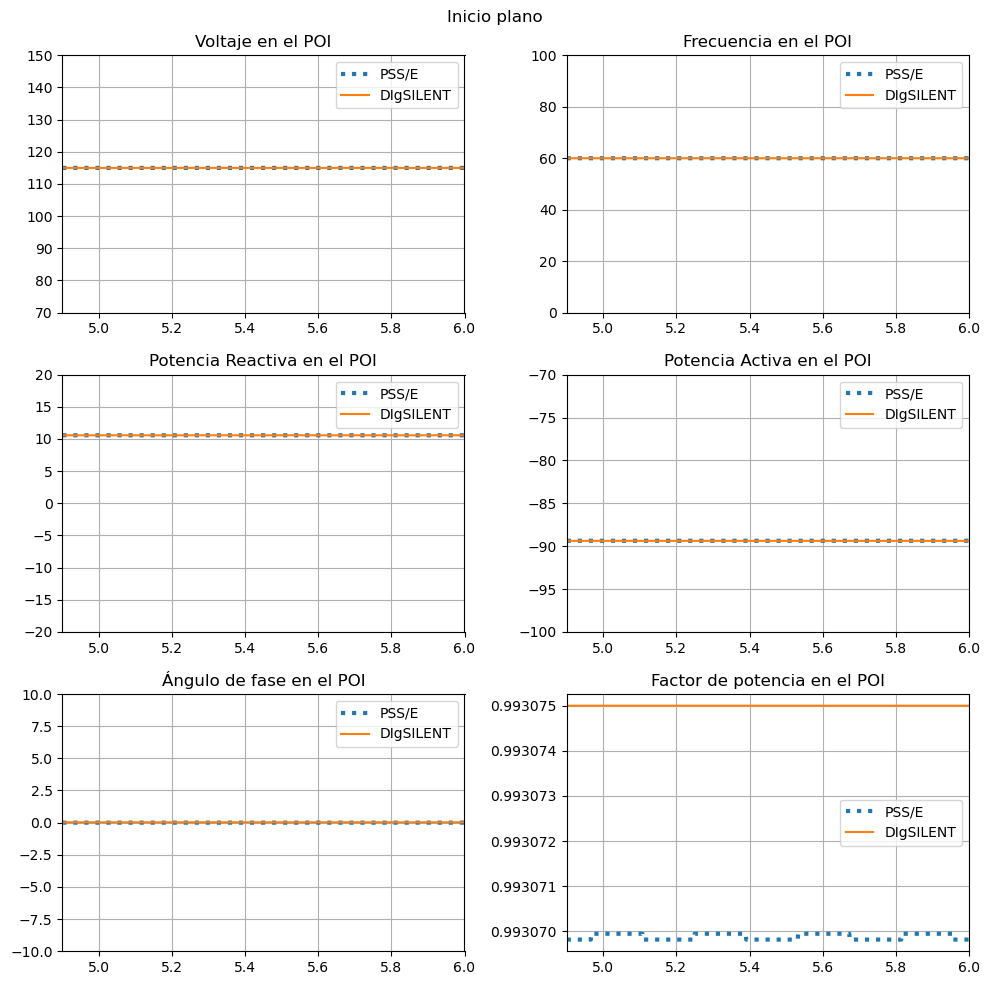

In [15]:
pss_data = pss_00
dsl_data = dsl_00
minx = 4.9
maxx = 6

if not isinstance(pss_data, pd.DataFrame) or not isinstance(dsl_data, pd.DataFrame):
    print("Advertencia: Uno de los DataFrames está vacío. Verifique los datos de entrada.")
else:
    fig, axs = plt.subplots(3, 2, figsize=(10,10))
    fig.suptitle('Inicio plano')

    # Voltaje en el POI
    axs[0,0].plot(pss_data['Time(s)'], pss_data['POI_V (kV)'], label='PSS/E', linestyle=':', linewidth=3)
    axs[0,0].plot(dsl_data['Time in S'], dsl_data['POI Bus m:Ul in kV'], label='DIgSILENT')
    axs[0,0].set_ylim(70,150)
    axs[0,0].set_xlim(minx, maxx)
    axs[0,0].set_title('Voltaje en el POI')
    axs[0,0].grid(True)
    axs[0,0].legend()

    # Frecuencia en el POI
    axs[0,1].plot(pss_data['Time(s)'], pss_data[' POI_FREQ']*60+60, label='PSS/E', linestyle=':', linewidth=3)
    axs[0,1].plot(dsl_data['Time in S'], dsl_data['POI n:fehz:bus1 in Hz'], label='DIgSILENT')
    axs[0,1].set_ylim(0,100)
    axs[0,1].set_xlim(minx, maxx)
    axs[0,1].set_title('Frecuencia en el POI')
    axs[0,1].grid(True)
    axs[0,1].legend()

    # Potencia Reactiva en el POI
    axs[1,0].plot(pss_data['Time(s)'], pss_data[' POI_Q'], label='PSS/E', linestyle=':', linewidth=3)
    axs[1,0].plot(dsl_data['Time in S'], dsl_data['POI m:Qsum:bus1 in Mvar'], label='DIgSILENT')
    axs[1,0].set_ylim(-20,20)
    axs[1,0].set_xlim(minx, maxx)
    axs[1,0].set_title('Potencia Reactiva en el POI')
    axs[1,0].grid(True)
    axs[1,0].legend()

    # Potencia Activa en el POI
    axs[1,1].plot(pss_data['Time(s)'], pss_data[' POI_P'], label='PSS/E', linestyle=':', linewidth=3)
    axs[1,1].plot(dsl_data['Time in S'], dsl_data['POI m:Psum:bus1 in MW'], label='DIgSILENT')
    axs[1,1].set_ylim(-100,-70)
    axs[1,1].ticklabel_format(style='plain', axis='y', useOffset=False)
    axs[1,1].set_xlim(minx, maxx)
    axs[1,1].set_title('Potencia Activa en el POI')
    axs[1,1].grid(True)
    axs[1,1].legend()
    
    # Ángulo de fase en el POI
    axs[2,0].plot(pss_data['Time(s)'], pss_data[' POI_ANGLE'], label='PSS/E', linestyle=':', linewidth=3)
    axs[2,0].plot(dsl_data['Time in S'], dsl_data['POI Bus m:phiu in deg'], label='DIgSILENT')
    axs[2,0].set_ylim(-10,10)
    axs[2,0].set_xlim(minx, maxx)
    axs[2,0].set_title('Ángulo de fase en el POI')
    axs[2,0].grid(True)
    axs[2,0].legend()

    # Factor de potencia en el POI
    axs[2,1].plot(pss_data['Time(s)'], pss_data['POI_pf (pu)'], label='PSS/E', linestyle=':', linewidth=3)
    axs[2,1].plot(dsl_data['Time in S'], dsl_data['POI m:cosphi:bus1'], label='DIgSILENT')
    # axs[2,1].set_ylim(0.95,1.05)
    axs[2,1].ticklabel_format(style='plain', axis='y', useOffset=False)
    axs[2,1].set_xlim(minx, maxx)
    axs[2,1].set_title('Factor de potencia en el POI')
    axs[2,1].grid(True)
    axs[2,1].legend()

    plt.tight_layout()
    plt.show()

### IBR

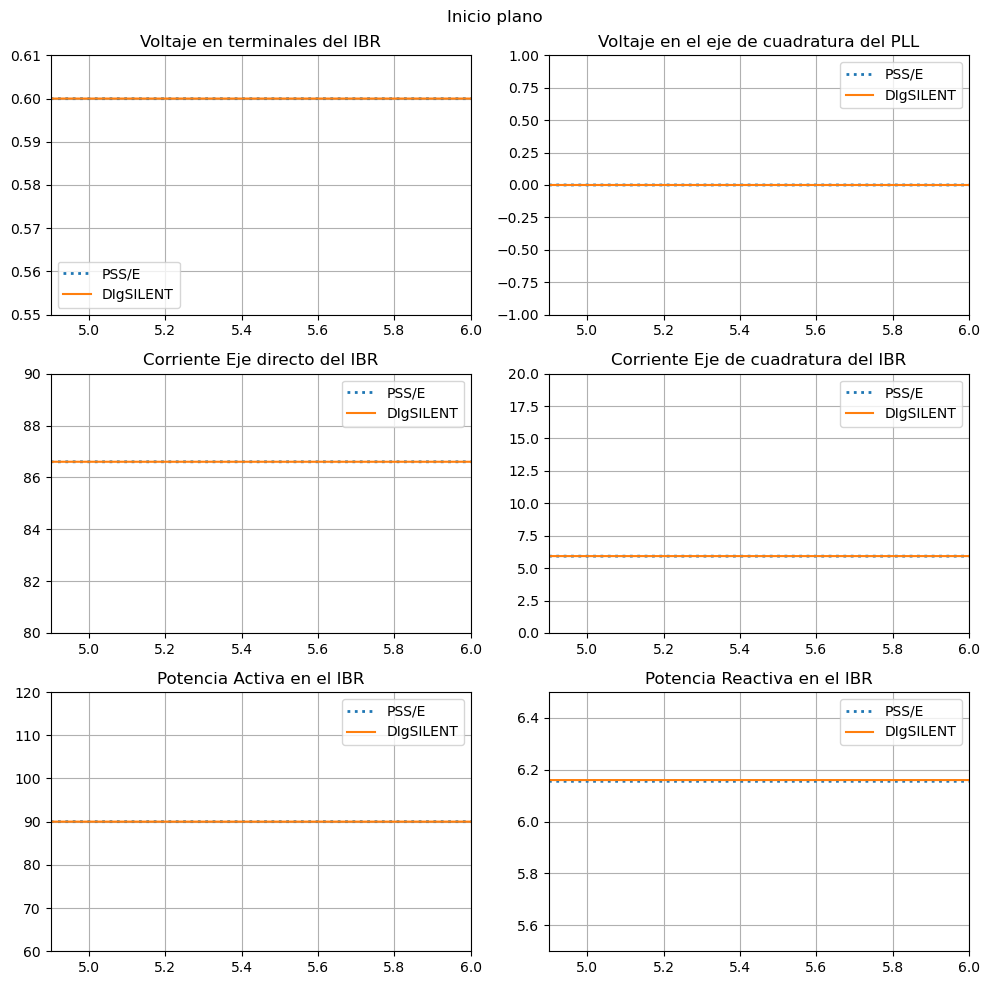

In [16]:
pss_data = pss_00
dsl_data = dsl_00
minx = 4.9
maxx = 6

if not isinstance(pss_data, pd.DataFrame) or not isinstance(dsl_data, pd.DataFrame):
    print("Advertencia: Uno de los DataFrames está vacío. Verifique los datos de entrada.")
else:
    fig, axs = plt.subplots(3, 2, figsize=(10,10))
    fig.suptitle('Inicio plano')

    # Voltaje en terminales del IBR
    axs[0,0].plot(pss_data['Time(s)'], pss_data['IBR_V (kV)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[0,0].plot(dsl_data['Time in S'], dsl_data['IBR n:Ul:bus1 in kV'], label='DIgSILENT')
    axs[0,0].set_ylim(0.55, 0.61)
    axs[0,0].set_xlim(minx, maxx)
    axs[0,0].set_title('Voltaje en terminales del IBR')
    axs[0,0].grid(True)
    axs[0,0].legend()

    # Voltaje en el eje de cuadratura del PLL
    axs[0,1].plot(pss_data['Time(s)'], pss_data['VQ_PLL (kV)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[0,1].plot(dsl_data['Time in S'], dsl_data['REGC_C c:uq'], label='DIgSILENT')
    axs[0,1].set_ylim(-1,1)
    axs[0,1].set_xlim(minx, maxx)
    axs[0,1].set_title('Voltaje en el eje de cuadratura del PLL')
    axs[0,1].grid(True)
    axs[0,1].legend()

    # Corriente Eje directo del IBR
    axs[1,0].plot(pss_data['Time(s)'], pss_data['IBR_ID (kA)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[1,0].plot(dsl_data['Time in S'], dsl_data['IBR m:I1P:bus1 in kA'], label='DIgSILENT') #!!!! Calcular a parte
    axs[1,0].set_ylim(80,90)
    axs[1,0].set_xlim(minx, maxx)
    axs[1,0].set_title('Corriente Eje directo del IBR')
    axs[1,0].grid(True)
    axs[1,0].legend()

    # Corriente Eje de cuadratura del IBR
    axs[1,1].plot(pss_data['Time(s)'], pss_data['IBR_IQ (kA)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[1,1].plot(dsl_data['Time in S'], dsl_data['IBR m:I1Q:bus1 in kA'], label='DIgSILENT')
    axs[1,1].set_ylim(0,20)
    axs[1,1].set_xlim(minx, maxx)
    axs[1,1].set_title('Corriente Eje de cuadratura del IBR')
    axs[1,1].grid(True)
    axs[1,1].legend()

    # Potencia Activa en el IBR
    axs[2,0].plot(pss_data['Time(s)'], pss_data['IBR_P (MW)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[2,0].plot(dsl_data['Time in S'], dsl_data['IBR m:Psum:bus1 in MW'], label='DIgSILENT')
    axs[2,0].set_ylim(60,120)
    axs[2,0].ticklabel_format(style='plain', axis='y', useOffset=False)
    axs[2,0].set_xlim(minx, maxx)
    axs[2,0].set_title('Potencia Activa en el IBR')
    axs[2,0].grid(True)
    axs[2,0].legend()

    # Potencia Reactiva en el IBR
    axs[2,1].plot(pss_data['Time(s)'], pss_data['IBR_Q (MVAR)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[2,1].plot(dsl_data['Time in S'], dsl_data['IBR m:Qsum:bus1 in Mvar'], label='DIgSILENT')
    axs[2,1].set_ylim(5.5,6.5)
    axs[2,1].ticklabel_format(style='plain', axis='y', useOffset=False)
    axs[2,1].set_xlim(minx, maxx)
    axs[2,1].set_title('Potencia Reactiva en el IBR')
    axs[2,1].grid(True)
    axs[2,1].legend()

    plt.tight_layout()
    plt.show()

## 01 - Falla Parcial

### POI

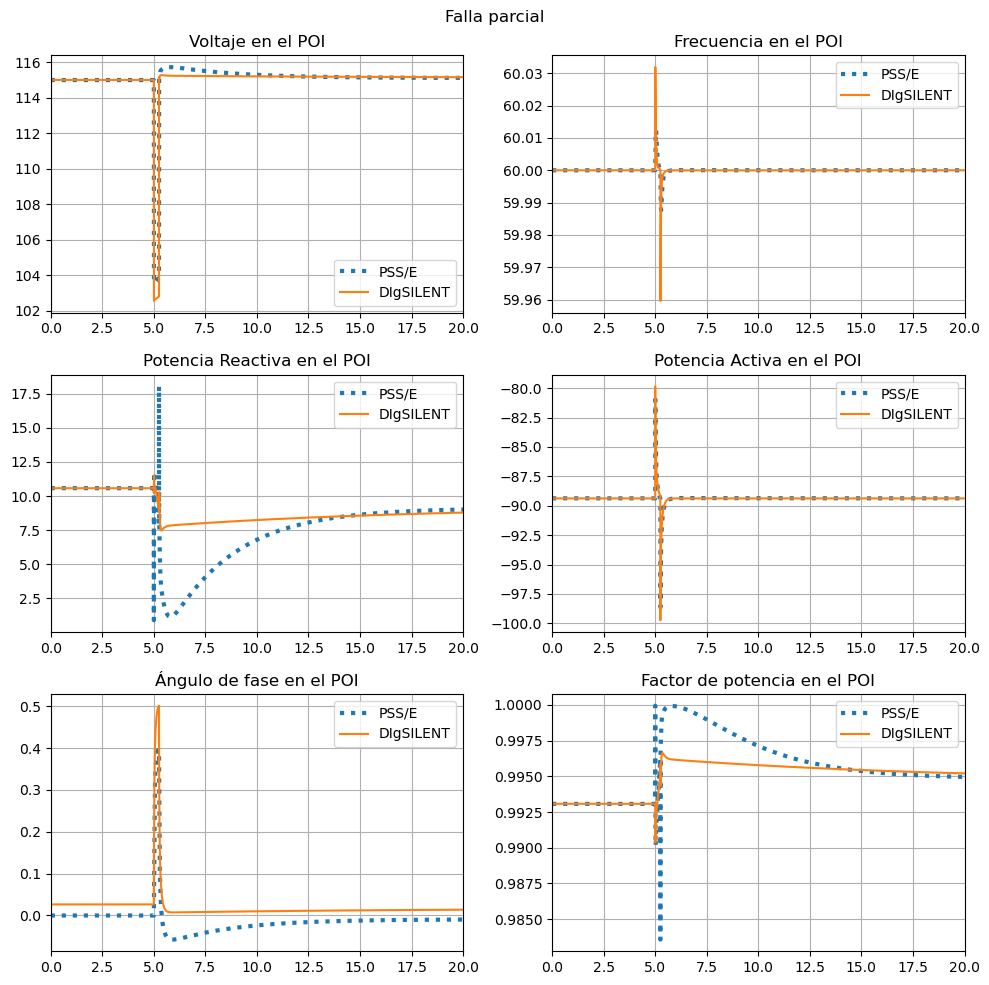

In [17]:
pss_data = pss_01
dsl_data = dsl_01
minx = 0
maxx = 20

if not isinstance(pss_data, pd.DataFrame) or not isinstance(dsl_data, pd.DataFrame):
    print("Advertencia: Uno de los DataFrames está vacío. Verifique los datos de entrada.")
else:
    fig, axs = plt.subplots(3, 2, figsize=(10,10))
    fig.suptitle('Falla parcial')

    # Voltaje en el POI
    axs[0,0].plot(pss_data['Time(s)'], pss_data['POI_V (kV)'], label='PSS/E', linestyle=':', linewidth=3)
    axs[0,0].plot(dsl_data['Time in S'], dsl_data['POI Bus m:Ul in kV'], label='DIgSILENT')
    #axs[0,0].set_ylim(70,150)
    axs[0,0].set_xlim(minx, maxx)
    axs[0,0].set_title('Voltaje en el POI')
    axs[0,0].grid(True)
    axs[0,0].legend()

    # Frecuencia en el POI
    axs[0,1].plot(pss_data['Time(s)'], pss_data[' POI_FREQ']*60+60, label='PSS/E', linestyle=':', linewidth=3)
    axs[0,1].plot(dsl_data['Time in S'], dsl_data['POI n:fehz:bus1 in Hz'], label='DIgSILENT')
    #axs[0,1].set_ylim(0,100)
    axs[0,1].set_xlim(minx, maxx)
    axs[0,1].set_title('Frecuencia en el POI')
    axs[0,1].grid(True)
    axs[0,1].legend()

    # Potencia Reactiva en el POI
    axs[1,0].plot(pss_data['Time(s)'], pss_data[' POI_Q'], label='PSS/E', linestyle=':', linewidth=3)
    axs[1,0].plot(dsl_data['Time in S'], dsl_data['POI m:Qsum:bus1 in Mvar'], label='DIgSILENT')
    #axs[1,0].set_ylim(0,150)
    axs[1,0].set_xlim(minx, maxx)
    axs[1,0].set_title('Potencia Reactiva en el POI')
    axs[1,0].grid(True)
    axs[1,0].legend()

    # Potencia Activa en el POI
    axs[1,1].plot(pss_data['Time(s)'], pss_data[' POI_P'], label='PSS/E', linestyle=':', linewidth=3)
    axs[1,1].plot(dsl_data['Time in S'], dsl_data['POI m:Psum:bus1 in MW'], label='DIgSILENT')
    #axs[1,1].set_ylim(-100,-70)
    axs[1,1].set_xlim(minx, maxx)
    axs[1,1].set_title('Potencia Activa en el POI')
    axs[1,1].grid(True)
    axs[1,1].legend()
    
    # Ángulo de fase en el POI
    axs[2,0].plot(pss_data['Time(s)'], pss_data[' POI_ANGLE'], label='PSS/E', linestyle=':', linewidth=3)
    axs[2,0].plot(dsl_data['Time in S'], dsl_data['POI Bus m:phiu in deg'], label='DIgSILENT')
    # axs[2,0].set_ylim(-10,10)
    axs[2,0].set_xlim(minx, maxx)
    axs[2,0].set_title('Ángulo de fase en el POI')
    axs[2,0].grid(True)
    axs[2,0].legend()

    # Factor de potencia en el POI
    axs[2,1].plot(pss_data['Time(s)'], abs(pss_data['POI_pf (pu)']), label='PSS/E', linestyle=':', linewidth=3)
    axs[2,1].plot(dsl_data['Time in S'], abs(dsl_data['POI m:cosphi:bus1']), label='DIgSILENT')
    # axs[2,1].set_ylim(0.95,1.05)
    axs[2,1].ticklabel_format(style='plain', axis='y', useOffset=False)
    axs[2,1].set_xlim(minx, maxx)
    axs[2,1].set_title('Factor de potencia en el POI')
    axs[2,1].grid(True)
    axs[2,1].legend()

    plt.tight_layout()
    plt.show()

### IBR

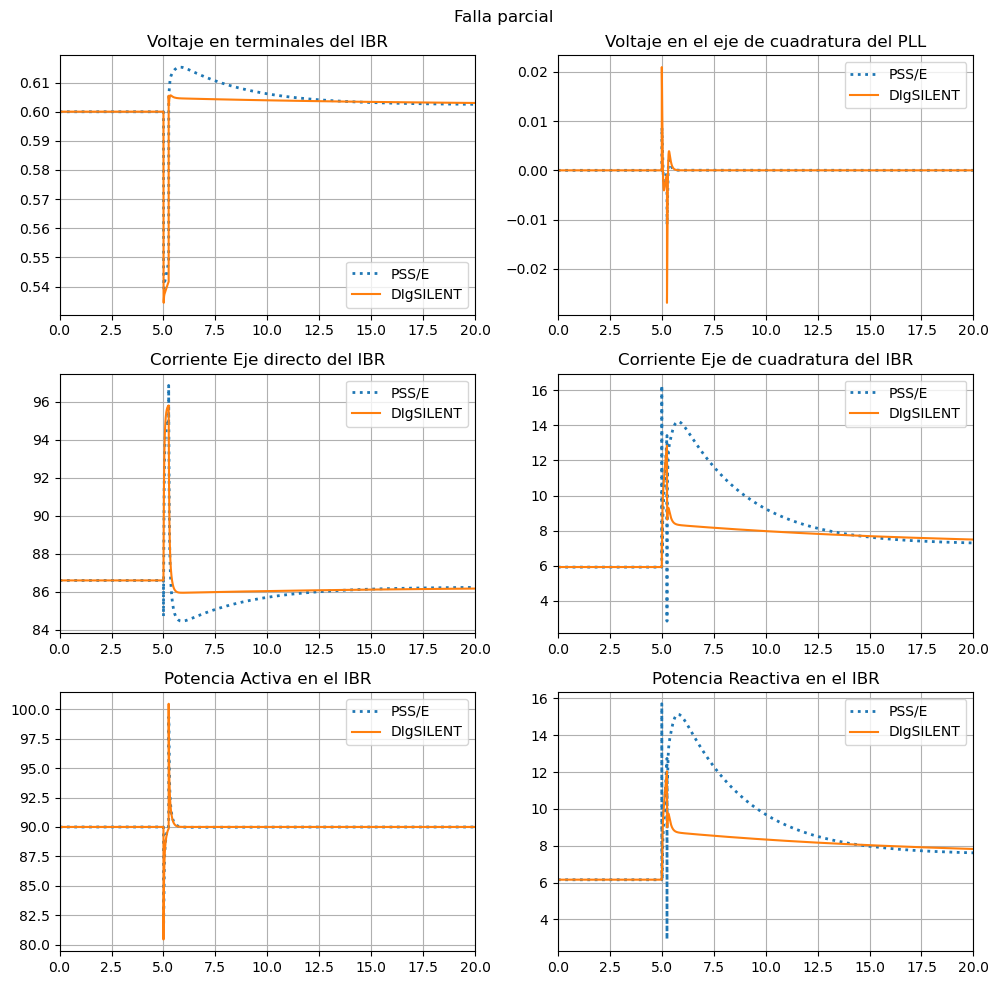

In [18]:
pss_data = pss_01
dsl_data = dsl_01
minx = 0
maxx = 20

if not isinstance(pss_data, pd.DataFrame) or not isinstance(dsl_data, pd.DataFrame):
    print("Advertencia: Uno de los DataFrames está vacío. Verifique los datos de entrada.")
else:
    fig, axs = plt.subplots(3, 2, figsize=(10,10))
    fig.suptitle('Falla parcial')

    # Voltaje en terminales del IBR
    axs[0,0].plot(pss_data['Time(s)'], pss_data[' IBRT_V']*Vterm, label='PSS/E', linestyle=':', linewidth=2)
    axs[0,0].plot(dsl_data['Time in S'], dsl_data['IBR n:Ul:bus1 in kV'], label='DIgSILENT')
    #axs[0,0].set_ylim(0.55, 0.61)
    axs[0,0].set_xlim(minx, maxx)
    axs[0,0].set_title('Voltaje en terminales del IBR')
    axs[0,0].grid(True)
    axs[0,0].legend()

    # Voltaje en el eje de cuadratura del PLL
    axs[0,1].plot(pss_data['Time(s)'], pss_data['VQ_PLL (kV)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[0,1].plot(dsl_data['Time in S'], dsl_data['REGC_C c:uq'], label='DIgSILENT')
    #axs[0,1].set_ylim(-1,1)
    axs[0,1].set_xlim(minx, maxx)
    axs[0,1].set_title('Voltaje en el eje de cuadratura del PLL')
    axs[0,1].grid(True)
    axs[0,1].legend()

    # Corriente Eje directo del IBR
    axs[1,0].plot(pss_data['Time(s)'], pss_data['IBR_ID (kA)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[1,0].plot(dsl_data['Time in S'], dsl_data['IBR m:I1P:bus1 in kA'], label='DIgSILENT') #!!!! Calcular a parte
    #axs[1,0].set_ylim(80,90)
    axs[1,0].set_xlim(minx, maxx)
    axs[1,0].set_title('Corriente Eje directo del IBR')
    axs[1,0].grid(True)
    axs[1,0].legend()

    # Corriente Eje de cuadratura del IBR
    axs[1,1].plot(pss_data['Time(s)'], pss_data['IBR_IQ (kA)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[1,1].plot(dsl_data['Time in S'], dsl_data['IBR m:I1Q:bus1 in kA'], label='DIgSILENT')
    # axs[1,1].set_ylim(0,20)
    axs[1,1].set_xlim(minx, maxx)
    axs[1,1].set_title('Corriente Eje de cuadratura del IBR')
    axs[1,1].grid(True)
    axs[1,1].legend()

    # Potencia Activa en el IBR
    axs[2,0].plot(pss_data['Time(s)'], pss_data['IBR_P (MW)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[2,0].plot(dsl_data['Time in S'], dsl_data['IBR m:Psum:bus1 in MW'], label='DIgSILENT')
    #axs[2,0].set_ylim(60,120)
    axs[2,0].ticklabel_format(style='plain', axis='y', useOffset=False)
    axs[2,0].set_xlim(minx, maxx)
    axs[2,0].set_title('Potencia Activa en el IBR')
    axs[2,0].grid(True)
    axs[2,0].legend()

    # Potencia Reactiva en el IBR
    axs[2,1].plot(pss_data['Time(s)'], pss_data['IBR_Q (MVAR)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[2,1].plot(dsl_data['Time in S'], dsl_data['IBR m:Qsum:bus1 in Mvar'], label='DIgSILENT')
    #axs[2,1].set_ylim(5.5,6.5)
    axs[2,1].ticklabel_format(style='plain', axis='y', useOffset=False)
    axs[2,1].set_xlim(minx, maxx)
    axs[2,1].set_title('Potencia Reactiva en el IBR')
    axs[2,1].grid(True)
    axs[2,1].legend()

    plt.tight_layout()
    plt.show()

## 02 - Falla total

### POI

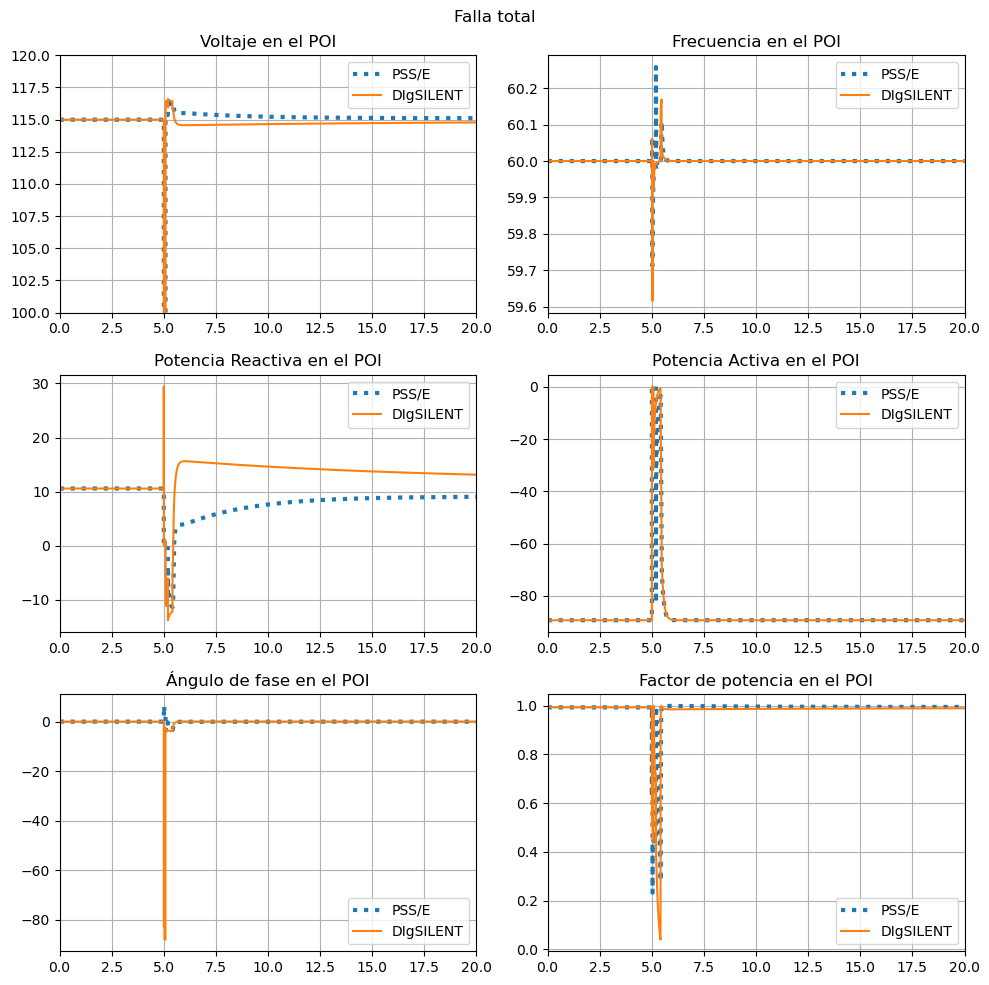

In [19]:
pss_data = pss_02
dsl_data = dsl_02
minx = 0
maxx = 20

if not isinstance(pss_data, pd.DataFrame) or not isinstance(dsl_data, pd.DataFrame):
    print("Advertencia: Uno de los DataFrames está vacío. Verifique los datos de entrada.")
else:    
    fig, axs = plt.subplots(3, 2, figsize=(10,10))
    fig.suptitle('Falla total')

    # Voltaje en el POI
    axs[0,0].plot(pss_data['Time(s)'], pss_data['POI_V (kV)'], label='PSS/E', linestyle=':', linewidth=3)
    axs[0,0].plot(dsl_data['Time in S'], dsl_data['POI Bus m:Ul in kV'], label='DIgSILENT')
    axs[0,0].set_ylim(100,120)
    axs[0,0].set_xlim(minx, maxx)
    axs[0,0].set_title('Voltaje en el POI')
    axs[0,0].grid(True)
    axs[0,0].legend()

    # Frecuencia en el POI
    axs[0,1].plot(pss_data['Time(s)'], pss_data[' POI_FREQ']*60+60, label='PSS/E', linestyle=':', linewidth=3)
    axs[0,1].plot(dsl_data['Time in S'], dsl_data['POI n:fehz:bus1 in Hz'], label='DIgSILENT')
    #axs[0,1].set_ylim(0,100)
    axs[0,1].set_xlim(minx, maxx)
    axs[0,1].set_title('Frecuencia en el POI')
    axs[0,1].grid(True)
    axs[0,1].legend()

    # Potencia Reactiva en el POI
    axs[1,0].plot(pss_data['Time(s)'], pss_data[' POI_Q'], label='PSS/E', linestyle=':', linewidth=3)
    axs[1,0].plot(dsl_data['Time in S'], dsl_data['POI m:Qsum:bus1 in Mvar'], label='DIgSILENT')
    #axs[1,0].set_ylim(0,150)
    axs[1,0].set_xlim(minx, maxx)
    axs[1,0].set_title('Potencia Reactiva en el POI')
    axs[1,0].grid(True)
    axs[1,0].legend()

    # Potencia Activa en el POI
    axs[1,1].plot(pss_data['Time(s)'], pss_data[' POI_P'], label='PSS/E', linestyle=':', linewidth=3)
    axs[1,1].plot(dsl_data['Time in S'], dsl_data['POI m:Psum:bus1 in MW'], label='DIgSILENT')
    #axs[1,1].set_ylim(-100,-70)
    axs[1,1].set_xlim(minx, maxx)
    axs[1,1].set_title('Potencia Activa en el POI')
    axs[1,1].grid(True)
    axs[1,1].legend()
    
    # Ángulo de fase en el POI
    axs[2,0].plot(pss_data['Time(s)'], pss_data[' POI_ANGLE'], label='PSS/E', linestyle=':', linewidth=3)
    axs[2,0].plot(dsl_data['Time in S'], dsl_data['POI Bus m:phiu in deg'], label='DIgSILENT')
    # axs[2,0].set_ylim(-10,10)
    axs[2,0].set_xlim(minx, maxx)
    axs[2,0].set_title('Ángulo de fase en el POI')
    axs[2,0].grid(True)
    axs[2,0].legend()

    # Factor de potencia en el POI
    axs[2,1].plot(pss_data['Time(s)'], abs(pss_data['POI_pf (pu)']), label='PSS/E', linestyle=':', linewidth=3)
    axs[2,1].plot(dsl_data['Time in S'], abs(dsl_data['POI m:cosphi:bus1']), label='DIgSILENT')
    # axs[2,1].set_ylim(0.95,1.05)
    axs[2,1].ticklabel_format(style='plain', axis='y', useOffset=False)
    axs[2,1].set_xlim(minx, maxx)
    axs[2,1].set_title('Factor de potencia en el POI')
    axs[2,1].grid(True)
    axs[2,1].legend()

    plt.tight_layout()
    plt.show()

### IBR

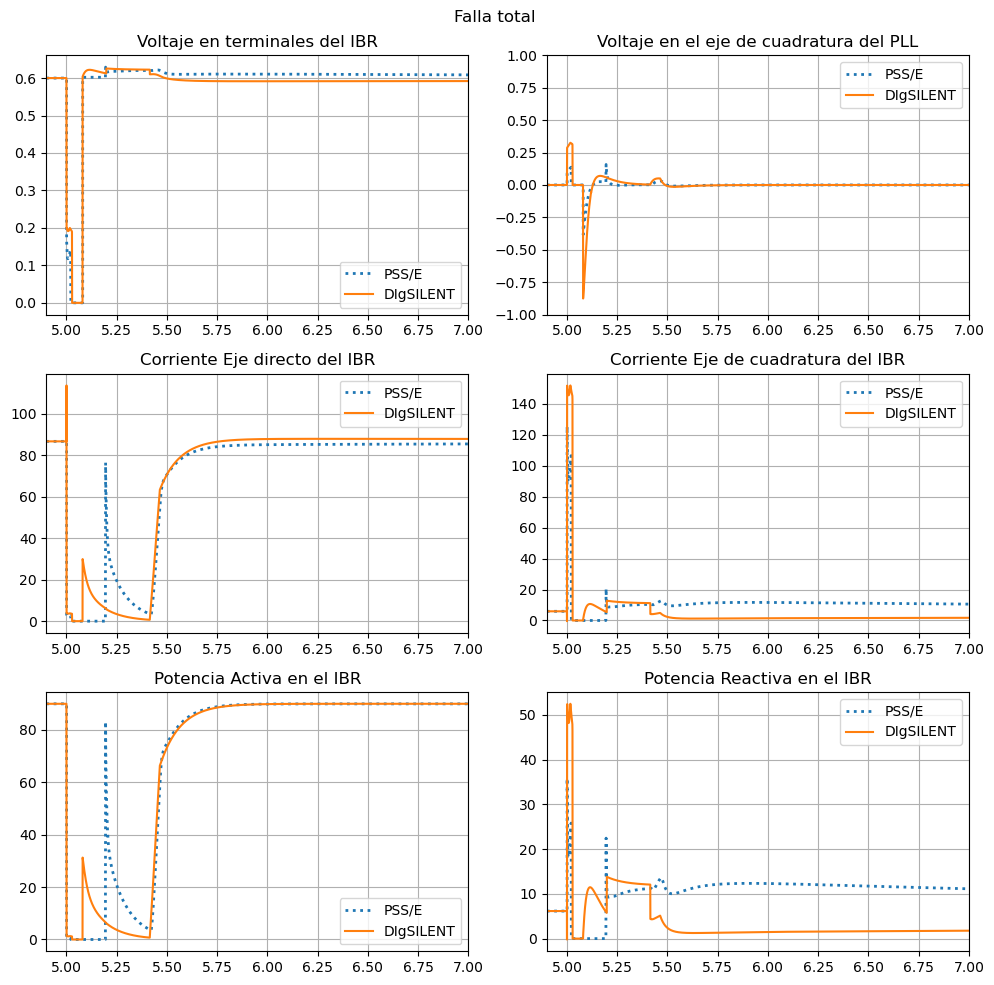

In [20]:
pss_data = pss_02
dsl_data = dsl_02
minx = 4.9
maxx = 7

if not isinstance(pss_data, pd.DataFrame) or not isinstance(dsl_data, pd.DataFrame):
    print("Advertencia: Uno de los DataFrames está vacío. Verifique los datos de entrada.")
else:    
    fig, axs = plt.subplots(3, 2, figsize=(10,10))
    fig.suptitle('Falla total')

    # Voltaje en terminales del IBR
    axs[0,0].plot(pss_data['Time(s)'], pss_data[' IBRT_V']*Vterm, label='PSS/E', linestyle=':', linewidth=2)
    axs[0,0].plot(dsl_data['Time in S'], dsl_data['IBR n:Ul:bus1 in kV'], label='DIgSILENT')
    #axs[0,0].set_ylim(0.55, 0.61)
    axs[0,0].set_xlim(minx, maxx)
    axs[0,0].set_title('Voltaje en terminales del IBR')
    axs[0,0].grid(True)
    axs[0,0].legend()

    # Voltaje en el eje de cuadratura del PLL
    axs[0,1].plot(pss_data['Time(s)'], pss_data['VQ_PLL (kV)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[0,1].plot(dsl_data['Time in S'], dsl_data['REGC_C c:uq'], label='DIgSILENT')
    axs[0,1].set_ylim(-1,1)
    axs[0,1].set_xlim(minx, maxx)
    axs[0,1].set_title('Voltaje en el eje de cuadratura del PLL')
    axs[0,1].grid(True)
    axs[0,1].legend()

    # Corriente Eje directo del IBR
    axs[1,0].plot(pss_data['Time(s)'], pss_data['IBR_ID (kA)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[1,0].plot(dsl_data['Time in S'], dsl_data['IBR m:I1P:bus1 in kA'], label='DIgSILENT')
    #axs[1,0].set_ylim(80,90)
    axs[1,0].set_xlim(minx, maxx)
    axs[1,0].set_title('Corriente Eje directo del IBR')
    axs[1,0].grid(True)
    axs[1,0].legend()

    # Corriente Eje de cuadratura del IBR
    axs[1,1].plot(pss_data['Time(s)'], pss_data['IBR_IQ (kA)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[1,1].plot(dsl_data['Time in S'], dsl_data['IBR m:I1Q:bus1 in kA'], label='DIgSILENT')
    # axs[1,1].set_ylim(0,20)
    axs[1,1].set_xlim(minx, maxx)
    axs[1,1].set_title('Corriente Eje de cuadratura del IBR')
    axs[1,1].grid(True)
    axs[1,1].legend()

    # Potencia Activa en el IBR
    axs[2,0].plot(pss_data['Time(s)'], pss_data['IBR_P (MW)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[2,0].plot(dsl_data['Time in S'], dsl_data['IBR m:Psum:bus1 in MW'], label='DIgSILENT')
    #axs[2,0].set_ylim(60,120)
    axs[2,0].ticklabel_format(style='plain', axis='y', useOffset=False)
    axs[2,0].set_xlim(minx, maxx)
    axs[2,0].set_title('Potencia Activa en el IBR')
    axs[2,0].grid(True)
    axs[2,0].legend()

    # Potencia Reactiva en el IBR
    axs[2,1].plot(pss_data['Time(s)'], pss_data['IBR_Q (MVAR)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[2,1].plot(dsl_data['Time in S'], dsl_data['IBR m:Qsum:bus1 in Mvar'], label='DIgSILENT')
    #axs[2,1].set_ylim(5.5,6.5)
    axs[2,1].ticklabel_format(style='plain', axis='y', useOffset=False)
    axs[2,1].set_xlim(minx, maxx)
    axs[2,1].set_title('Potencia Reactiva en el IBR')
    axs[2,1].grid(True)
    axs[2,1].legend()

    plt.tight_layout()
    plt.show()

## 03 - Perturbación de fase

### POI

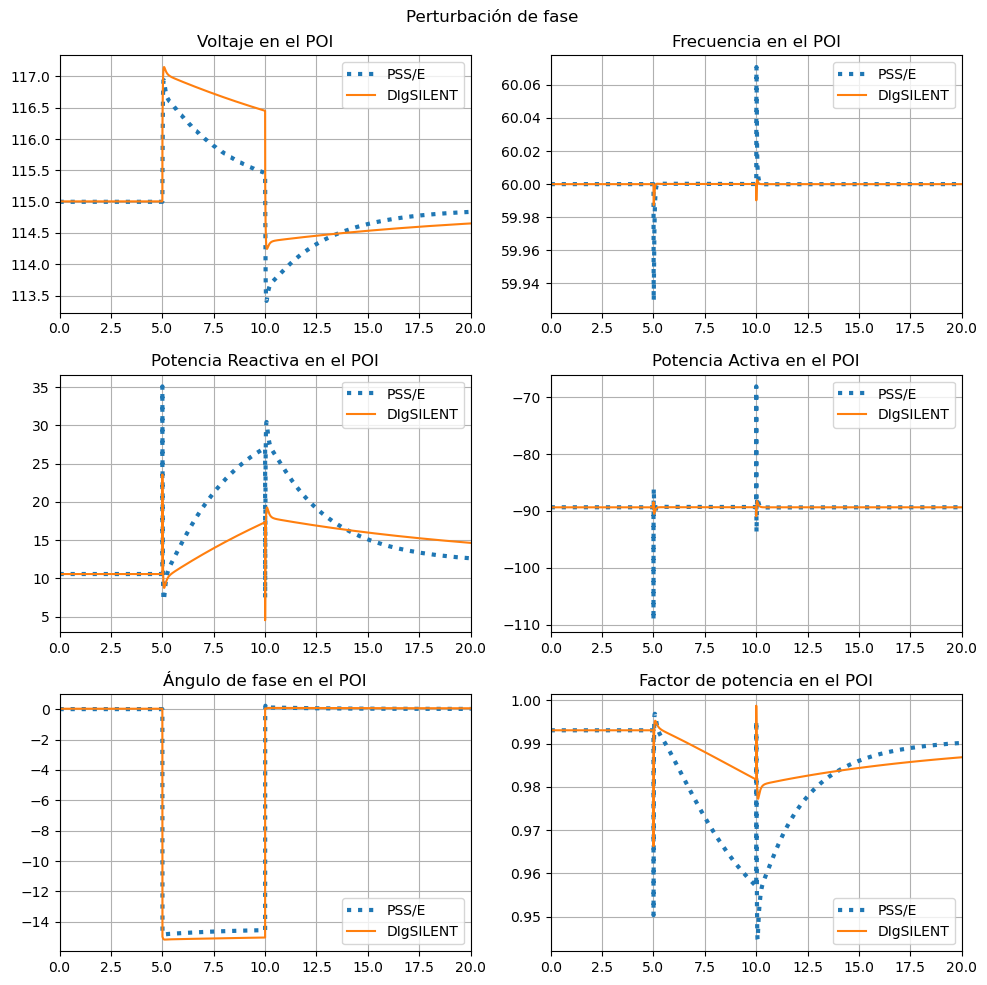

In [21]:
pss_data = pss_03
dsl_data = dsl_03
minx = 0
maxx = 20

if not isinstance(pss_data, pd.DataFrame) or not isinstance(dsl_data, pd.DataFrame):
    print("Advertencia: Uno de los DataFrames está vacío. Verifique los datos de entrada.")
else:    
    fig, axs = plt.subplots(3, 2, figsize=(10,10))
    fig.suptitle('Perturbación de fase')

    # Voltaje en el POI
    axs[0,0].plot(pss_data['Time(s)'], pss_data['POI_V (kV)'], label='PSS/E', linestyle=':', linewidth=3)
    axs[0,0].plot(dsl_data['Time in S'], dsl_data['POI Bus m:Ul in kV'], label='DIgSILENT')
    #axs[0,0].set_ylim(70,150)
    axs[0,0].set_xlim(minx, maxx)
    axs[0,0].set_title('Voltaje en el POI')
    axs[0,0].grid(True)
    axs[0,0].legend()

    # Frecuencia en el POI
    axs[0,1].plot(pss_data['Time(s)'], pss_data[' POI_FREQ']*60+60, label='PSS/E', linestyle=':', linewidth=3)
    axs[0,1].plot(dsl_data['Time in S'], dsl_data['POI n:fehz:bus1 in Hz'], label='DIgSILENT')
    #axs[0,1].set_ylim(59.995,60.005)
    axs[0,1].set_xlim(minx, maxx)
    axs[0,1].set_title('Frecuencia en el POI')
    axs[0,1].grid(True)
    axs[0,1].legend()

    # Potencia Reactiva en el POI
    axs[1,0].plot(pss_data['Time(s)'], pss_data[' POI_Q'], label='PSS/E', linestyle=':', linewidth=3)
    axs[1,0].plot(dsl_data['Time in S'], dsl_data['POI m:Qsum:bus1 in Mvar'], label='DIgSILENT')
    #axs[1,0].set_ylim(0,150)
    axs[1,0].set_xlim(minx, maxx)
    axs[1,0].set_title('Potencia Reactiva en el POI')
    axs[1,0].grid(True)
    axs[1,0].legend()

    # Potencia Activa en el POI
    axs[1,1].plot(pss_data['Time(s)'], pss_data[' POI_P'], label='PSS/E', linestyle=':', linewidth=3)
    axs[1,1].plot(dsl_data['Time in S'], dsl_data['POI m:Psum:bus1 in MW'], label='DIgSILENT')
    #axs[1,1].set_ylim(-100,-70)
    axs[1,1].set_xlim(minx, maxx)
    axs[1,1].set_title('Potencia Activa en el POI')
    axs[1,1].grid(True)
    axs[1,1].legend()

    # Ángulo de fase en el POI
    axs[2,0].plot(pss_data['Time(s)'], pss_data[' POI_ANGLE'], label='PSS/E', linestyle=':', linewidth=3)
    axs[2,0].plot(dsl_data['Time in S'], dsl_data['POI Bus m:phiu in deg'], label='DIgSILENT')
    #axs[2,0].set_ylim(-100,-70)
    axs[2,0].set_xlim(minx, maxx)
    axs[2,0].set_title('Ángulo de fase en el POI')
    axs[2,0].grid(True)
    axs[2,0].legend()


    # Factor de potencia en el POI
    axs[2,1].plot(pss_data['Time(s)'], pss_data['POI_pf (pu)'], label='PSS/E', linestyle=':', linewidth=3)
    axs[2,1].plot(dsl_data['Time in S'], abs(dsl_data['POI m:cosphi:bus1']), label='DIgSILENT')
    # axs[2,1].set_ylim(0.95,1.05)
    axs[2,1].set_xlim(minx, maxx)
    axs[2,1].set_title('Factor de potencia en el POI')
    axs[2,1].grid(True)
    axs[2,1].legend()

    plt.tight_layout()
    plt.show()

### IBR

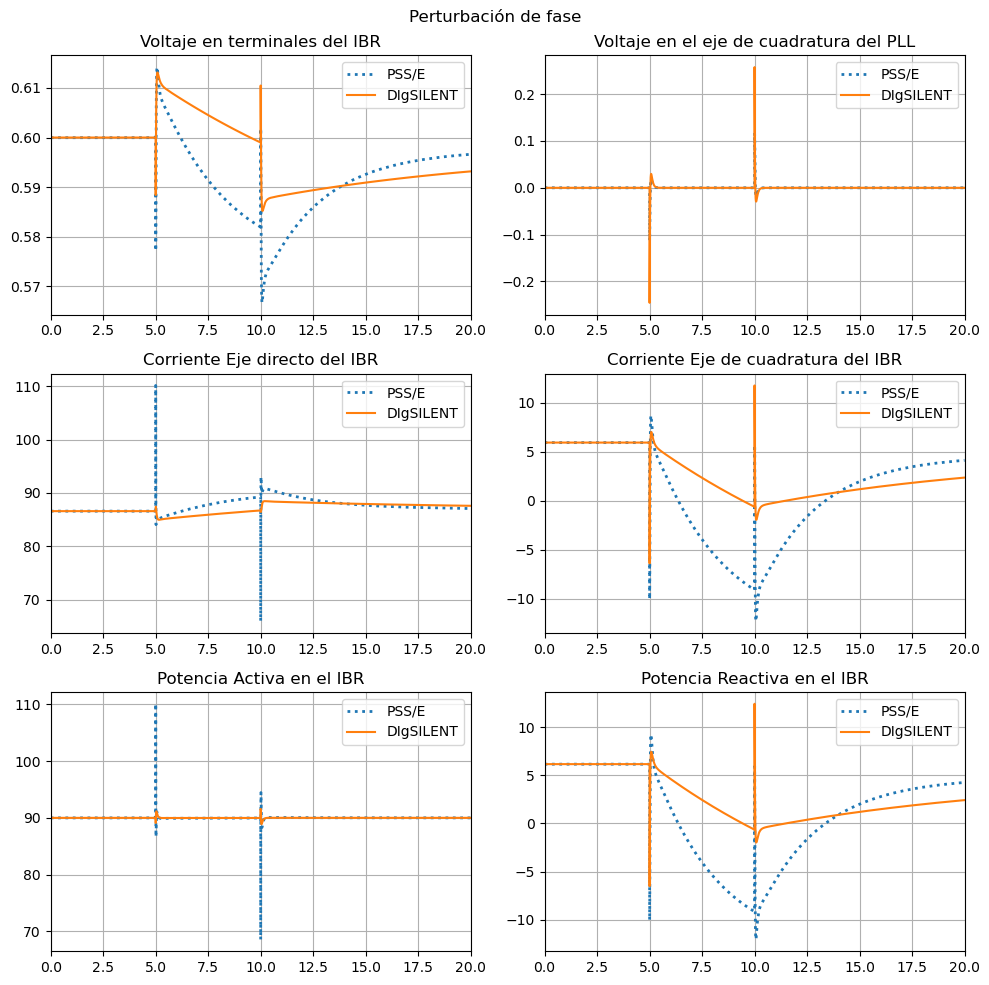

In [22]:
pss_data = pss_03
dsl_data = dsl_03
minx = 0
maxx = 20

if not isinstance(pss_data, pd.DataFrame) or not isinstance(dsl_data, pd.DataFrame):
    print("Advertencia: Uno de los DataFrames está vacío. Verifique los datos de entrada.")
else:      
    fig, axs = plt.subplots(3, 2, figsize=(10,10))
    fig.suptitle('Perturbación de fase')

    # Voltaje en terminales del IBR
    axs[0,0].plot(pss_data['Time(s)'], pss_data[' IBRT_V']*Vterm, label='PSS/E', linestyle=':', linewidth=2)
    axs[0,0].plot(dsl_data['Time in S'], dsl_data['IBR n:Ul:bus1 in kV'], label='DIgSILENT')
    #axs[0,0].set_ylim(0.55, 0.61)
    axs[0,0].set_xlim(minx, maxx)
    axs[0,0].set_title('Voltaje en terminales del IBR')
    axs[0,0].grid(True)
    axs[0,0].legend()

    # Voltaje en el eje de cuadratura del PLL
    axs[0,1].plot(pss_data['Time(s)'], pss_data['VQ_PLL (kV)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[0,1].plot(dsl_data['Time in S'], dsl_data['REGC_C c:uq'], label='DIgSILENT')
    #axs[0,1].set_ylim(-1,1)
    axs[0,1].set_xlim(minx, maxx)
    axs[0,1].set_title('Voltaje en el eje de cuadratura del PLL')
    axs[0,1].grid(True)
    axs[0,1].legend()

    # Corriente Eje directo del IBR
    axs[1,0].plot(pss_data['Time(s)'], pss_data['IBR_ID (kA)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[1,0].plot(dsl_data['Time in S'], dsl_data['IBR m:I1P:bus1 in kA'], label='DIgSILENT')
    #axs[1,0].set_ylim(80,90)
    axs[1,0].set_xlim(minx, maxx)
    axs[1,0].set_title('Corriente Eje directo del IBR')
    axs[1,0].grid(True)
    axs[1,0].legend()

    # Corriente Eje de cuadratura del IBR
    axs[1,1].plot(pss_data['Time(s)'], pss_data['IBR_IQ (kA)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[1,1].plot(dsl_data['Time in S'], dsl_data['IBR m:I1Q:bus1 in kA'], label='DIgSILENT')
    # axs[1,1].set_ylim(0,20)
    axs[1,1].set_xlim(minx, maxx)
    axs[1,1].set_title('Corriente Eje de cuadratura del IBR')
    axs[1,1].grid(True)
    axs[1,1].legend()

    # Potencia Activa en el IBR
    axs[2,0].plot(pss_data['Time(s)'], pss_data['IBR_P (MW)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[2,0].plot(dsl_data['Time in S'], dsl_data['IBR m:Psum:bus1 in MW'], label='DIgSILENT')
    #axs[2,0].set_ylim(60,120)
    axs[2,0].ticklabel_format(style='plain', axis='y', useOffset=False)
    axs[2,0].set_xlim(minx, maxx)
    axs[2,0].set_title('Potencia Activa en el IBR')
    axs[2,0].grid(True)
    axs[2,0].legend()

    # Potencia Reactiva en el IBR
    axs[2,1].plot(pss_data['Time(s)'], pss_data['IBR_Q (MVAR)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[2,1].plot(dsl_data['Time in S'], dsl_data['IBR m:Qsum:bus1 in Mvar'], label='DIgSILENT')
    #axs[2,1].set_ylim(5.5,6.5)
    axs[2,1].ticklabel_format(style='plain', axis='y', useOffset=False)
    axs[2,1].set_xlim(minx, maxx)
    axs[2,1].set_title('Potencia Reactiva en el IBR')
    axs[2,1].grid(True)
    axs[2,1].legend()

    plt.tight_layout()
    plt.show()

## 04 - Perturbación de frecuencia

### POI

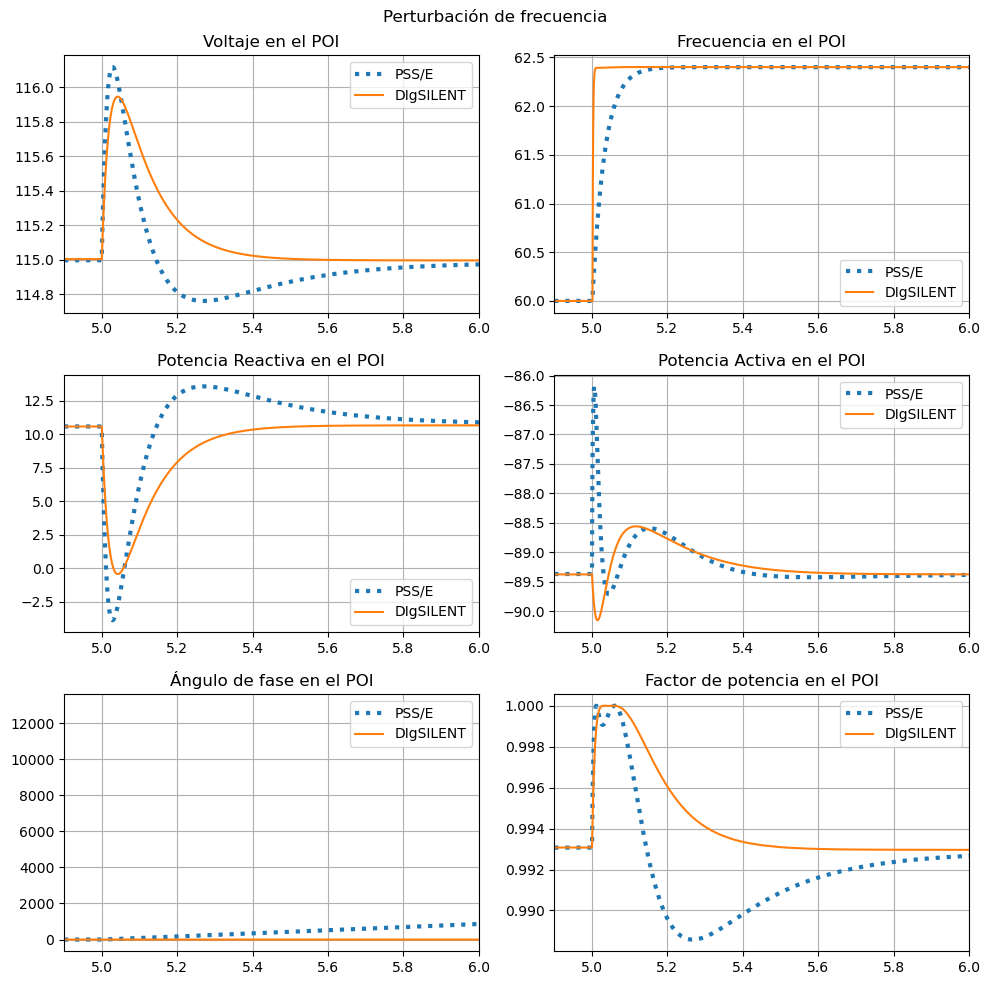

In [29]:
pss_data = pss_04
dsl_data = dsl_04
minx = 4.9
maxx = 6

if not isinstance(pss_data, pd.DataFrame) or not isinstance(dsl_data, pd.DataFrame):
    print("Advertencia: Uno de los DataFrames está vacío. Verifique los datos de entrada.")
else:
    fig, axs = plt.subplots(3, 2, figsize=(10,10))
    fig.suptitle('Perturbación de frecuencia')

    # Voltaje en el POI
    axs[0,0].plot(pss_data['Time(s)'], pss_data['POI_V (kV)'], label='PSS/E', linestyle=':', linewidth=3)
    axs[0,0].plot(dsl_data['Time in S'], dsl_data['POI Bus m:Ul in kV'], label='DIgSILENT')
    #axs[0,0].set_ylim(70,150)
    axs[0,0].set_xlim(minx, maxx)
    axs[0,0].set_title('Voltaje en el POI')
    axs[0,0].grid(True)
    axs[0,0].legend()

    # Frecuencia en el POI
    axs[0,1].plot(pss_data['Time(s)'], pss_data['POI_FRQ (Hz)'], label='PSS/E', linestyle=':', linewidth=3)
    axs[0,1].plot(dsl_data['Time in S'], dsl_data['POI n:fehz:bus1 in Hz'], label='DIgSILENT')
    # axs[0,1].set_ylim(62.38,62.41)
    axs[0,1].set_xlim(minx, maxx)
    axs[0,1].set_title('Frecuencia en el POI')
    axs[0,1].grid(True)
    axs[0,1].legend()

    # Potencia Reactiva en el POI
    axs[1,0].plot(pss_data['Time(s)'], pss_data[' POI_Q'], label='PSS/E', linestyle=':', linewidth=3)
    axs[1,0].plot(dsl_data['Time in S'], dsl_data['POI m:Qsum:bus1 in Mvar'], label='DIgSILENT')
    #axs[1,0].set_ylim(0,150)
    axs[1,0].set_xlim(minx, maxx)
    axs[1,0].set_title('Potencia Reactiva en el POI')
    axs[1,0].grid(True)
    axs[1,0].legend()

    # Potencia Activa en el POI
    axs[1,1].plot(pss_data['Time(s)'], pss_data[' POI_P'], label='PSS/E', linestyle=':', linewidth=3)
    axs[1,1].plot(dsl_data['Time in S'], dsl_data['POI m:Psum:bus1 in MW'], label='DIgSILENT')
    #axs[1,1].set_ylim(-100,-70)
    axs[1,1].set_xlim(minx, maxx)
    axs[1,1].set_title('Potencia Activa en el POI')
    axs[1,1].grid(True)
    axs[1,1].legend()

    # Ángulo de fase en el POI
    axs[2,0].plot(pss_data['Time(s)'], pss_data[' POI_ANGLE'], label='PSS/E', linestyle=':', linewidth=3)
    axs[2,0].plot(dsl_data['Time in S'], dsl_data['POI Bus m:phiu in deg'], label='DIgSILENT')
    # axs[2,0].set_ylim(-100,-70)
    axs[2,0].set_xlim(minx, maxx)
    axs[2,0].set_title('Ángulo de fase en el POI')
    axs[2,0].grid(True)
    axs[2,0].legend()

    # Factor de potencia en el POI
    axs[2,1].plot(pss_data['Time(s)'], pss_data['POI_pf (pu)'], label='PSS/E', linestyle=':', linewidth=3)
    axs[2,1].plot(dsl_data['Time in S'], abs(dsl_data['POI m:cosphi:bus1']), label='DIgSILENT')
    # axs[2,1].set_ylim(0.95,1.05)
    axs[2,1].set_xlim(minx, maxx)
    axs[2,1].set_title('Factor de potencia en el POI')
    axs[2,1].grid(True)
    axs[2,1].legend()

    plt.tight_layout()
    plt.show()

### IBR

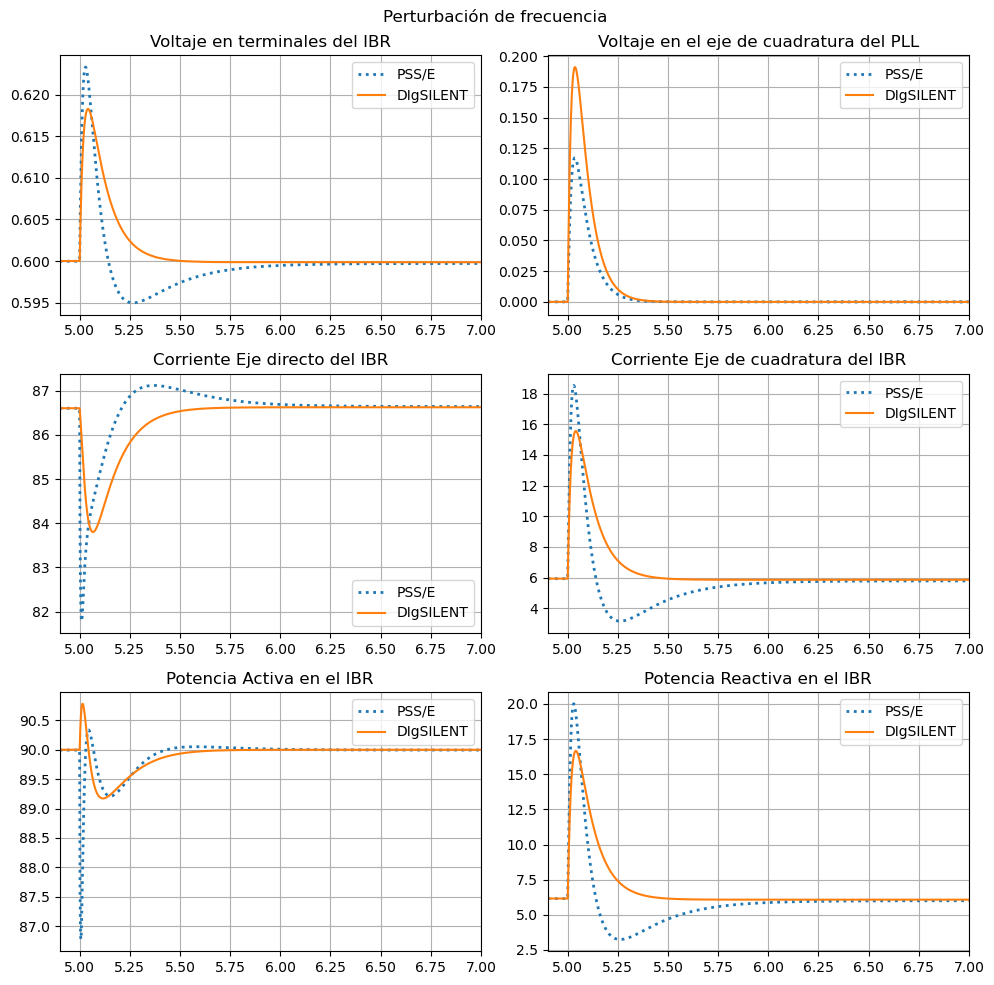

In [23]:
pss_data = pss_04
dsl_data = dsl_04
minx = 4.9
maxx = 7

if not isinstance(pss_data, pd.DataFrame) or not isinstance(dsl_data, pd.DataFrame):
    print("Advertencia: Uno de los DataFrames está vacío. Verifique los datos de entrada.")
else:
    fig, axs = plt.subplots(3, 2, figsize=(10,10))
    fig.suptitle('Perturbación de frecuencia')

    # Voltaje en terminales del IBR
    axs[0,0].plot(pss_data['Time(s)'], pss_data[' IBRT_V']*Vterm, label='PSS/E', linestyle=':', linewidth=2)
    axs[0,0].plot(dsl_data['Time in S'], dsl_data['IBR n:Ul:bus1 in kV'], label='DIgSILENT')
    #axs[0,0].set_ylim(0.55, 0.61)
    axs[0,0].set_xlim(minx, maxx)
    axs[0,0].set_title('Voltaje en terminales del IBR')
    axs[0,0].grid(True)
    axs[0,0].legend()

    # Voltaje en el eje de cuadratura del PLL
    axs[0,1].plot(pss_data['Time(s)'], pss_data['VQ_PLL (kV)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[0,1].plot(dsl_data['Time in S'], dsl_data['REGC_C c:uq'], label='DIgSILENT')
    #axs[0,1].set_ylim(-1,1)
    axs[0,1].set_xlim(minx, maxx)
    axs[0,1].set_title('Voltaje en el eje de cuadratura del PLL')
    axs[0,1].grid(True)
    axs[0,1].legend()

    # Corriente Eje directo del IBR
    axs[1,0].plot(pss_data['Time(s)'], pss_data['IBR_ID (kA)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[1,0].plot(dsl_data['Time in S'], dsl_data['IBR m:I1P:bus1 in kA'], label='DIgSILENT')
    #axs[1,0].set_ylim(80,90)
    axs[1,0].set_xlim(minx, maxx)
    axs[1,0].set_title('Corriente Eje directo del IBR')
    axs[1,0].grid(True)
    axs[1,0].legend()

    # Corriente Eje de cuadratura del IBR
    axs[1,1].plot(pss_data['Time(s)'], pss_data['IBR_IQ (kA)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[1,1].plot(dsl_data['Time in S'], dsl_data['IBR m:I1Q:bus1 in kA'], label='DIgSILENT')
    # axs[1,1].set_ylim(0,20)
    axs[1,1].set_xlim(minx, maxx)
    axs[1,1].set_title('Corriente Eje de cuadratura del IBR')
    axs[1,1].grid(True)
    axs[1,1].legend()

    # Potencia Activa en el IBR
    axs[2,0].plot(pss_data['Time(s)'], pss_data['IBR_P (MW)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[2,0].plot(dsl_data['Time in S'], dsl_data['IBR m:Psum:bus1 in MW'], label='DIgSILENT')
    #axs[2,0].set_ylim(60,120)
    axs[2,0].ticklabel_format(style='plain', axis='y', useOffset=False)
    axs[2,0].set_xlim(minx, maxx)
    axs[2,0].set_title('Potencia Activa en el IBR')
    axs[2,0].grid(True)
    axs[2,0].legend()

    # Potencia Reactiva en el IBR
    axs[2,1].plot(pss_data['Time(s)'], pss_data['IBR_Q (MVAR)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[2,1].plot(dsl_data['Time in S'], dsl_data['IBR m:Qsum:bus1 in Mvar'], label='DIgSILENT')
    #axs[2,1].set_ylim(5.5,6.5)
    axs[2,1].ticklabel_format(style='plain', axis='y', useOffset=False)
    axs[2,1].set_xlim(minx, maxx)
    axs[2,1].set_title('Potencia Reactiva en el IBR')
    axs[2,1].grid(True)
    axs[2,1].legend()

    plt.tight_layout()
    plt.show()

## 05 - Perturbación de voltaje

### POI

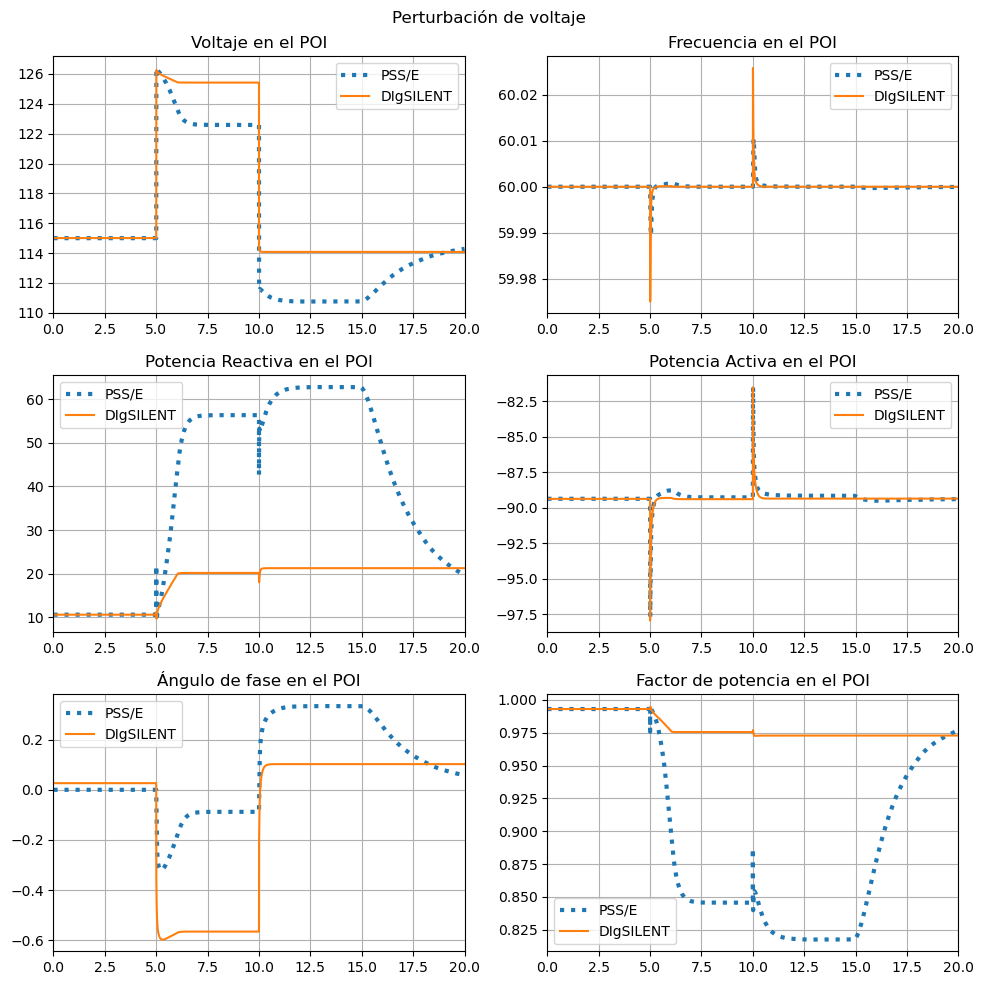

In [24]:
pss_data = pss_05
dsl_data = dsl_05
minx = 0
maxx = 20

if not isinstance(pss_data, pd.DataFrame) or not isinstance(dsl_data, pd.DataFrame):
    print("Advertencia: Uno de los DataFrames está vacío. Verifique los datos de entrada.")
else:
    fig, axs = plt.subplots(3, 2, figsize=(10,10))
    fig.suptitle('Perturbación de voltaje')

    # Voltaje en el POI
    axs[0,0].plot(pss_data['Time(s)'], pss_data['POI_V (kV)'], label='PSS/E', linestyle=':', linewidth=3)
    axs[0,0].plot(dsl_data['Time in S'], dsl_data['POI Bus m:Ul in kV'], label='DIgSILENT')
    #axs[0,0].set_ylim(70,150)
    axs[0,0].set_xlim(minx, maxx)
    axs[0,0].set_title('Voltaje en el POI')
    axs[0,0].grid(True)
    axs[0,0].legend()

    # Frecuencia en el POI
    axs[0,1].plot(pss_data['Time(s)'], pss_data[' POI_FREQ']*60+60, label='PSS/E', linestyle=':', linewidth=3)
    axs[0,1].plot(dsl_data['Time in S'], dsl_data['POI n:fehz:bus1 in Hz'], label='DIgSILENT')
    #axs[0,1].set_ylim(59.995,60.005)
    axs[0,1].ticklabel_format(style='plain', axis='y', useOffset=False)
    axs[0,1].set_xlim(minx, maxx)
    axs[0,1].set_title('Frecuencia en el POI')
    axs[0,1].grid(True)
    axs[0,1].legend()

    # Potencia Reactiva en el POI
    axs[1,0].plot(pss_data['Time(s)'], pss_data[' POI_Q'], label='PSS/E', linestyle=':', linewidth=3)
    axs[1,0].plot(dsl_data['Time in S'], dsl_data['POI m:Qsum:bus1 in Mvar'], label='DIgSILENT')
    #axs[1,0].set_ylim(0,150)
    axs[1,0].set_xlim(minx, maxx)
    axs[1,0].set_title('Potencia Reactiva en el POI')
    axs[1,0].grid(True)
    axs[1,0].legend()

    # Potencia Activa en el POI
    axs[1,1].plot(pss_data['Time(s)'], pss_data[' POI_P'], label='PSS/E', linestyle=':', linewidth=3)
    axs[1,1].plot(dsl_data['Time in S'], dsl_data['POI m:Psum:bus1 in MW'], label='DIgSILENT')
    #axs[1,1].set_ylim(-100,-70)
    axs[1,1].set_xlim(minx, maxx)
    axs[1,1].set_title('Potencia Activa en el POI')
    axs[1,1].grid(True)
    axs[1,1].legend()

    # Ángulo de fase en el POI
    axs[2,0].plot(pss_data['Time(s)'], pss_data[' POI_ANGLE'], label='PSS/E', linestyle=':', linewidth=3)
    axs[2,0].plot(dsl_data['Time in S'], dsl_data['POI Bus m:phiu in deg'], label='DIgSILENT')
    #axs[2,0].set_ylim(-100,-70)
    axs[2,0].set_xlim(minx, maxx)
    axs[2,0].set_title('Ángulo de fase en el POI')
    axs[2,0].grid(True)
    axs[2,0].legend()

    # Factor de potencia en el POI
    axs[2,1].plot(pss_data['Time(s)'], pss_data['POI_pf (pu)'], label='PSS/E', linestyle=':', linewidth=3)
    axs[2,1].plot(dsl_data['Time in S'], abs(dsl_data['POI m:cosphi:bus1']), label='DIgSILENT')
    # axs[2,1].set_ylim(0.95,1.05)
    axs[2,1].set_xlim(minx, maxx)
    axs[2,1].set_title('Factor de potencia en el POI')
    axs[2,1].grid(True)
    axs[2,1].legend()

    plt.tight_layout()
    plt.show()

### IBR

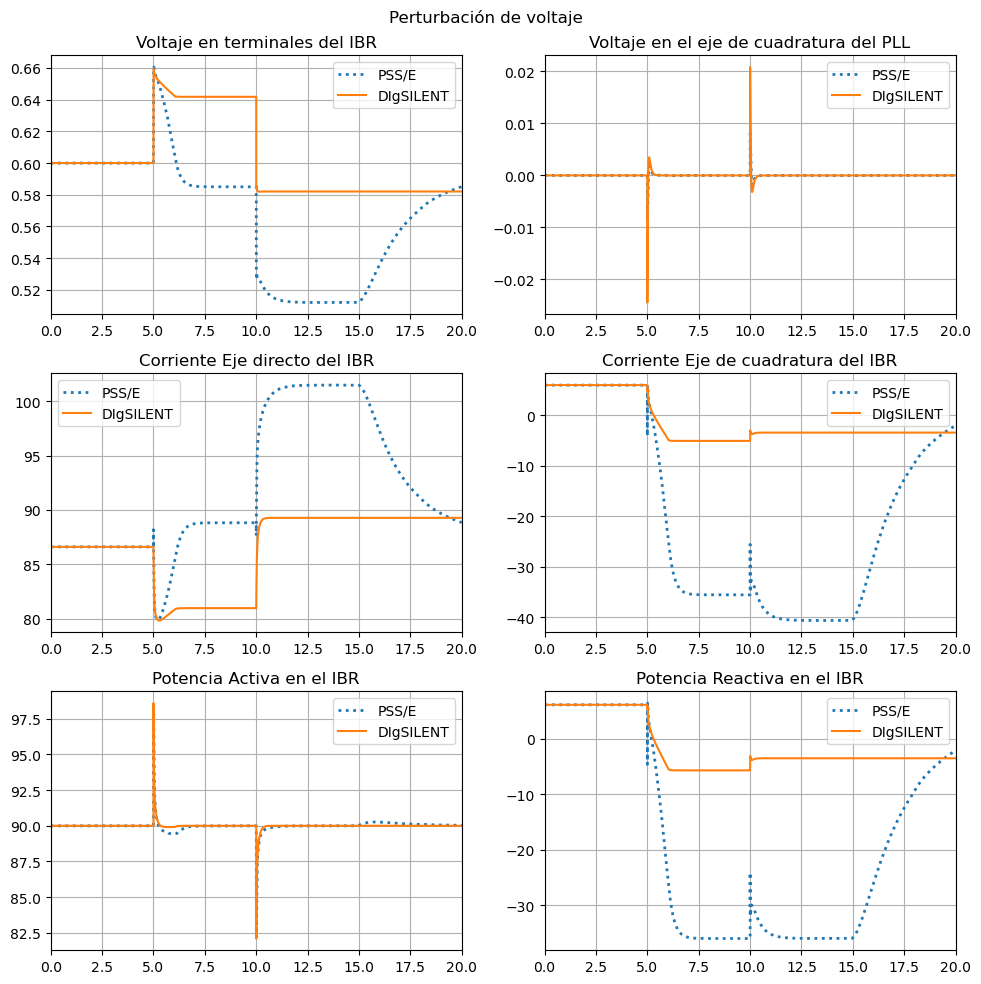

In [25]:
pss_data = pss_05
dsl_data = dsl_05
minx = 0
maxx = 20

if not isinstance(pss_data, pd.DataFrame) or not isinstance(dsl_data, pd.DataFrame):
    print("Advertencia: Uno de los DataFrames está vacío. Verifique los datos de entrada.")
else:
    fig, axs = plt.subplots(3, 2, figsize=(10,10))
    fig.suptitle('Perturbación de voltaje')

    # Voltaje en terminales del IBR
    axs[0,0].plot(pss_data['Time(s)'], pss_data[' IBRT_V']*Vterm, label='PSS/E', linestyle=':', linewidth=2)
    axs[0,0].plot(dsl_data['Time in S'], dsl_data['IBR n:Ul:bus1 in kV'], label='DIgSILENT')
    #axs[0,0].set_ylim(0.55, 0.61)
    axs[0,0].set_xlim(minx, maxx)
    axs[0,0].set_title('Voltaje en terminales del IBR')
    axs[0,0].grid(True)
    axs[0,0].legend()

    # Voltaje en el eje de cuadratura del PLL
    axs[0,1].plot(pss_data['Time(s)'], pss_data['VQ_PLL (kV)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[0,1].plot(dsl_data['Time in S'], dsl_data['REGC_C c:uq'], label='DIgSILENT')
    #axs[0,1].set_ylim(-1,1)
    axs[0,1].set_xlim(minx, maxx)
    axs[0,1].set_title('Voltaje en el eje de cuadratura del PLL')
    axs[0,1].grid(True)
    axs[0,1].legend()

    # Corriente Eje directo del IBR
    axs[1,0].plot(pss_data['Time(s)'], pss_data['IBR_ID (kA)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[1,0].plot(dsl_data['Time in S'], dsl_data['IBR m:I1P:bus1 in kA'], label='DIgSILENT')
    #axs[1,0].set_ylim(80,90)
    axs[1,0].set_xlim(minx, maxx)
    axs[1,0].set_title('Corriente Eje directo del IBR')
    axs[1,0].grid(True)
    axs[1,0].legend()

    # Corriente Eje de cuadratura del IBR
    axs[1,1].plot(pss_data['Time(s)'], pss_data['IBR_IQ (kA)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[1,1].plot(dsl_data['Time in S'], dsl_data['IBR m:I1Q:bus1 in kA'], label='DIgSILENT')
    # axs[1,1].set_ylim(0,20)
    axs[1,1].set_xlim(minx, maxx)
    axs[1,1].set_title('Corriente Eje de cuadratura del IBR')
    axs[1,1].grid(True)
    axs[1,1].legend()

    # Potencia Activa en el IBR
    axs[2,0].plot(pss_data['Time(s)'], pss_data['IBR_P (MW)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[2,0].plot(dsl_data['Time in S'], dsl_data['IBR m:Psum:bus1 in MW'], label='DIgSILENT')
    #axs[2,0].set_ylim(60,120)
    axs[2,0].ticklabel_format(style='plain', axis='y', useOffset=False)
    axs[2,0].set_xlim(minx, maxx)
    axs[2,0].set_title('Potencia Activa en el IBR')
    axs[2,0].grid(True)
    axs[2,0].legend()

    # Potencia Reactiva en el IBR
    axs[2,1].plot(pss_data['Time(s)'], pss_data['IBR_Q (MVAR)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[2,1].plot(dsl_data['Time in S'], dsl_data['IBR m:Qsum:bus1 in Mvar'], label='DIgSILENT')
    #axs[2,1].set_ylim(5.5,6.5)
    axs[2,1].ticklabel_format(style='plain', axis='y', useOffset=False)
    axs[2,1].set_xlim(minx, maxx)
    axs[2,1].set_title('Potencia Reactiva en el IBR')
    axs[2,1].grid(True)
    axs[2,1].legend()

    plt.tight_layout()
    plt.show()

## 06 - Escalon Paux

### POI

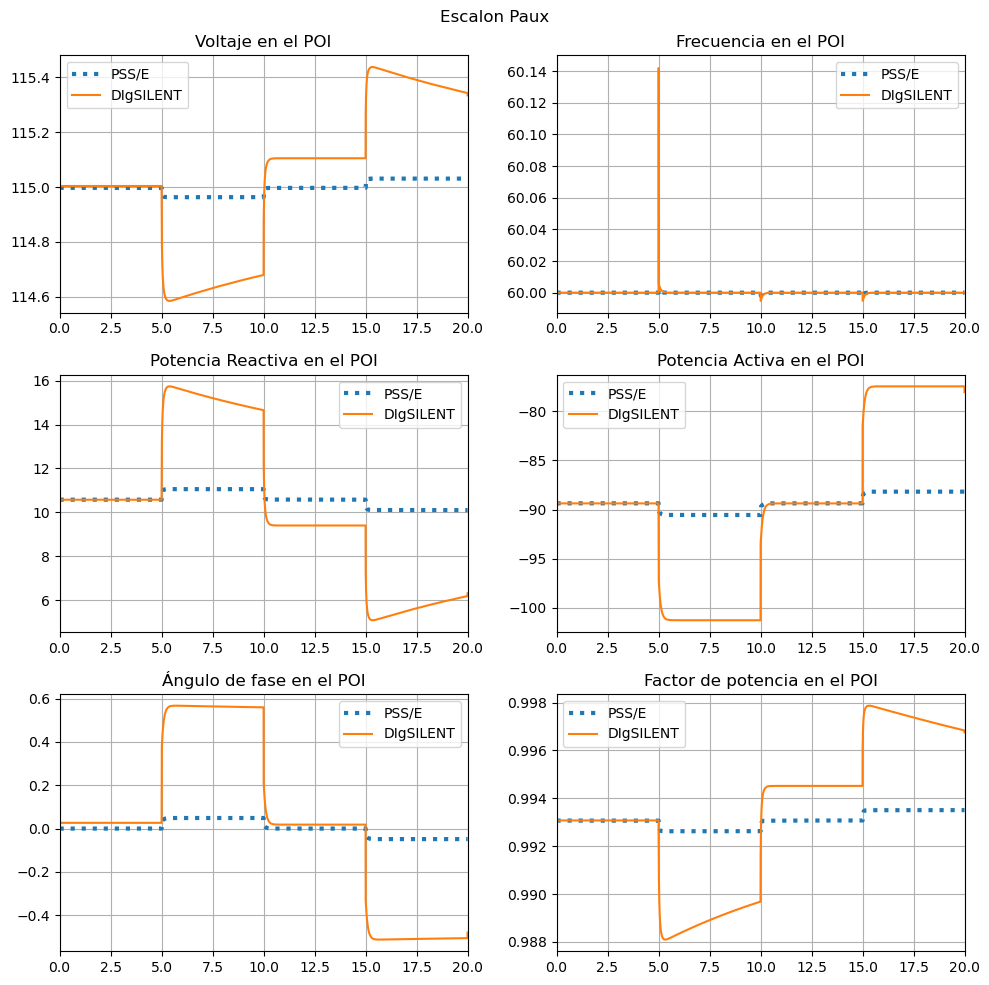

In [26]:
pss_data = pss_06
dsl_data = dsl_06
minx = 0
maxx = 20

if not isinstance(pss_data, pd.DataFrame) or not isinstance(dsl_data, pd.DataFrame):
    print("Advertencia: Uno de los DataFrames está vacío. Verifique los datos de entrada.")
else:
    fig, axs = plt.subplots(3, 2, figsize=(10,10))
    fig.suptitle('Escalon Paux')

    # Voltaje en el POI
    axs[0,0].plot(pss_data['Time(s)'], pss_data['POI_V (kV)'], label='PSS/E', linestyle=':', linewidth=3)
    axs[0,0].plot(dsl_data['Time in S'], dsl_data['POI Bus m:Ul in kV'], label='DIgSILENT')
    #axs[0,0].set_ylim(70,150)
    axs[0,0].set_xlim(minx, maxx)
    axs[0,0].set_title('Voltaje en el POI')
    axs[0,0].grid(True)
    axs[0,0].legend()

    # Frecuencia en el POI
    axs[0,1].plot(pss_data['Time(s)'], pss_data[' POI_FREQ']*60+60, label='PSS/E', linestyle=':', linewidth=3)
    axs[0,1].plot(dsl_data['Time in S'], dsl_data['POI n:fehz:bus1 in Hz'], label='DIgSILENT')
    #axs[0,1].set_ylim(59.995,60.005)
    axs[0,1].ticklabel_format(style='plain', axis='y', useOffset=False)
    axs[0,1].set_xlim(minx, maxx)
    axs[0,1].set_title('Frecuencia en el POI')
    axs[0,1].grid(True)
    axs[0,1].legend()

    # Potencia Reactiva en el POI
    axs[1,0].plot(pss_data['Time(s)'], pss_data[' POI_Q'], label='PSS/E', linestyle=':', linewidth=3)
    axs[1,0].plot(dsl_data['Time in S'], dsl_data['POI m:Qsum:bus1 in Mvar'], label='DIgSILENT')
    #axs[1,0].set_ylim(0,150)
    axs[1,0].set_xlim(minx, maxx)
    axs[1,0].set_title('Potencia Reactiva en el POI')
    axs[1,0].grid(True)
    axs[1,0].legend()

    # Potencia Activa en el POI
    axs[1,1].plot(pss_data['Time(s)'], pss_data[' POI_P'], label='PSS/E', linestyle=':', linewidth=3)
    axs[1,1].plot(dsl_data['Time in S'], dsl_data['POI m:Psum:bus1 in MW'], label='DIgSILENT')
    #axs[1,1].set_ylim(-100,-70)
    axs[1,1].set_xlim(minx, maxx)
    axs[1,1].set_title('Potencia Activa en el POI')
    axs[1,1].grid(True)
    axs[1,1].legend()

    # Ángulo de fase en el POI
    axs[2,0].plot(pss_data['Time(s)'], pss_data[' POI_ANGLE'], label='PSS/E', linestyle=':', linewidth=3)
    axs[2,0].plot(dsl_data['Time in S'], dsl_data['POI Bus m:phiu in deg'], label='DIgSILENT')
    #axs[2,0].set_ylim(-100,-70)
    axs[2,0].set_xlim(minx, maxx)
    axs[2,0].set_title('Ángulo de fase en el POI')
    axs[2,0].grid(True)
    axs[2,0].legend()

    # Factor de potencia en el POI
    axs[2,1].plot(pss_data['Time(s)'], pss_data['POI_pf (pu)'], label='PSS/E', linestyle=':', linewidth=3)
    axs[2,1].plot(dsl_data['Time in S'], abs(dsl_data['POI m:cosphi:bus1']), label='DIgSILENT')
    # axs[2,1].set_ylim(0.95,1.05)
    axs[2,1].set_xlim(minx, maxx)
    axs[2,1].set_title('Factor de potencia en el POI')
    axs[2,1].grid(True)
    axs[2,1].legend()

    plt.tight_layout()
    plt.show()

### IBR

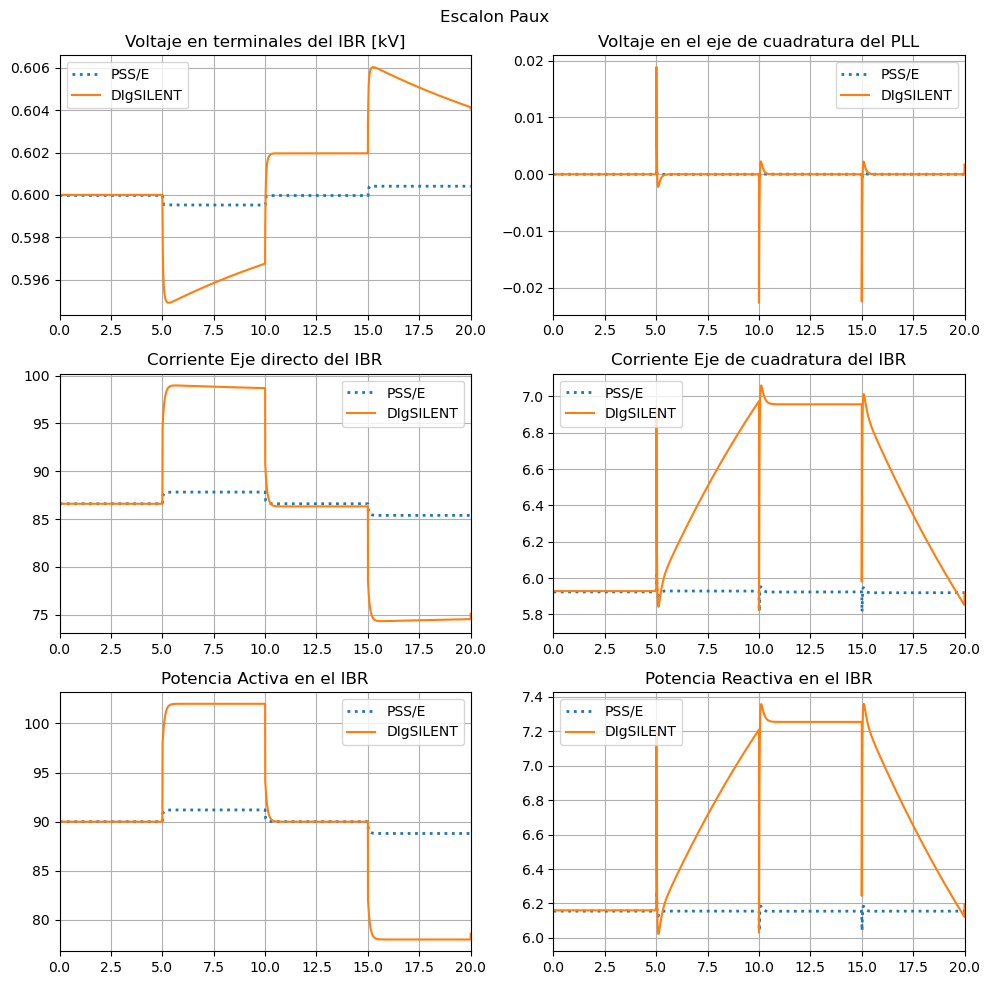

In [27]:
pss_data = pss_06
dsl_data = dsl_06
minx = 0
maxx = 20

if not isinstance(pss_data, pd.DataFrame) or not isinstance(dsl_data, pd.DataFrame):
    print("Advertencia: Uno de los DataFrames está vacío. Verifique los datos de entrada.")
else:
    fig, axs = plt.subplots(3, 2, figsize=(10,10))
    fig.suptitle('Escalon Paux')

    # Voltaje en terminales del IBR
    axs[0,0].plot(pss_data['Time(s)'], pss_data[' IBRT_V']*Vterm, label='PSS/E', linestyle=':', linewidth=2)
    axs[0,0].plot(dsl_data['Time in S'], dsl_data['IBR n:Ul:bus1 in kV'], label='DIgSILENT')
    #axs[0,0].set_ylim(0.55, 0.61)
    axs[0,0].set_xlim(minx, maxx)
    axs[0,0].set_title('Voltaje en terminales del IBR [kV]')
    axs[0,0].grid(True)
    axs[0,0].legend()

    # Voltaje en el eje de cuadratura del PLL
    axs[0,1].plot(pss_data['Time(s)'], pss_data['VQ_PLL (kV)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[0,1].plot(dsl_data['Time in S'], dsl_data['REGC_C c:uq'], label='DIgSILENT')
    #axs[0,1].set_ylim(-1,1)
    axs[0,1].set_xlim(minx, maxx)
    axs[0,1].set_title('Voltaje en el eje de cuadratura del PLL')
    axs[0,1].grid(True)
    axs[0,1].legend()

    # Corriente Eje directo del IBR
    axs[1,0].plot(pss_data['Time(s)'], pss_data['IBR_ID (kA)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[1,0].plot(dsl_data['Time in S'], dsl_data['IBR m:I1P:bus1 in kA'], label='DIgSILENT')
    #axs[1,0].set_ylim(80,90)
    axs[1,0].set_xlim(minx, maxx)
    axs[1,0].set_title('Corriente Eje directo del IBR')
    axs[1,0].grid(True)
    axs[1,0].legend()

    # Corriente Eje de cuadratura del IBR
    axs[1,1].plot(pss_data['Time(s)'], pss_data['IBR_IQ (kA)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[1,1].plot(dsl_data['Time in S'], dsl_data['IBR m:I1Q:bus1 in kA'], label='DIgSILENT')
    # axs[1,1].set_ylim(0,20)
    axs[1,1].set_xlim(minx, maxx)
    axs[1,1].set_title('Corriente Eje de cuadratura del IBR')
    axs[1,1].grid(True)
    axs[1,1].legend()

    # Potencia Activa en el IBR
    axs[2,0].plot(pss_data['Time(s)'], pss_data['IBR_P (MW)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[2,0].plot(dsl_data['Time in S'], dsl_data['IBR m:Psum:bus1 in MW'], label='DIgSILENT')
    #axs[2,0].set_ylim(60,120)
    axs[2,0].ticklabel_format(style='plain', axis='y', useOffset=False)
    axs[2,0].set_xlim(minx, maxx)
    axs[2,0].set_title('Potencia Activa en el IBR')
    axs[2,0].grid(True)
    axs[2,0].legend()

    # Potencia Reactiva en el IBR
    axs[2,1].plot(pss_data['Time(s)'], pss_data['IBR_Q (MVAR)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[2,1].plot(dsl_data['Time in S'], dsl_data['IBR m:Qsum:bus1 in Mvar'], label='DIgSILENT')
    #axs[2,1].set_ylim(5.5,6.5)
    axs[2,1].ticklabel_format(style='plain', axis='y', useOffset=False)
    axs[2,1].set_xlim(minx, maxx)
    axs[2,1].set_title('Potencia Reactiva en el IBR')
    axs[2,1].grid(True)
    axs[2,1].legend()

    plt.tight_layout()
    plt.show()

## 07 - Escalon Pref

### POI

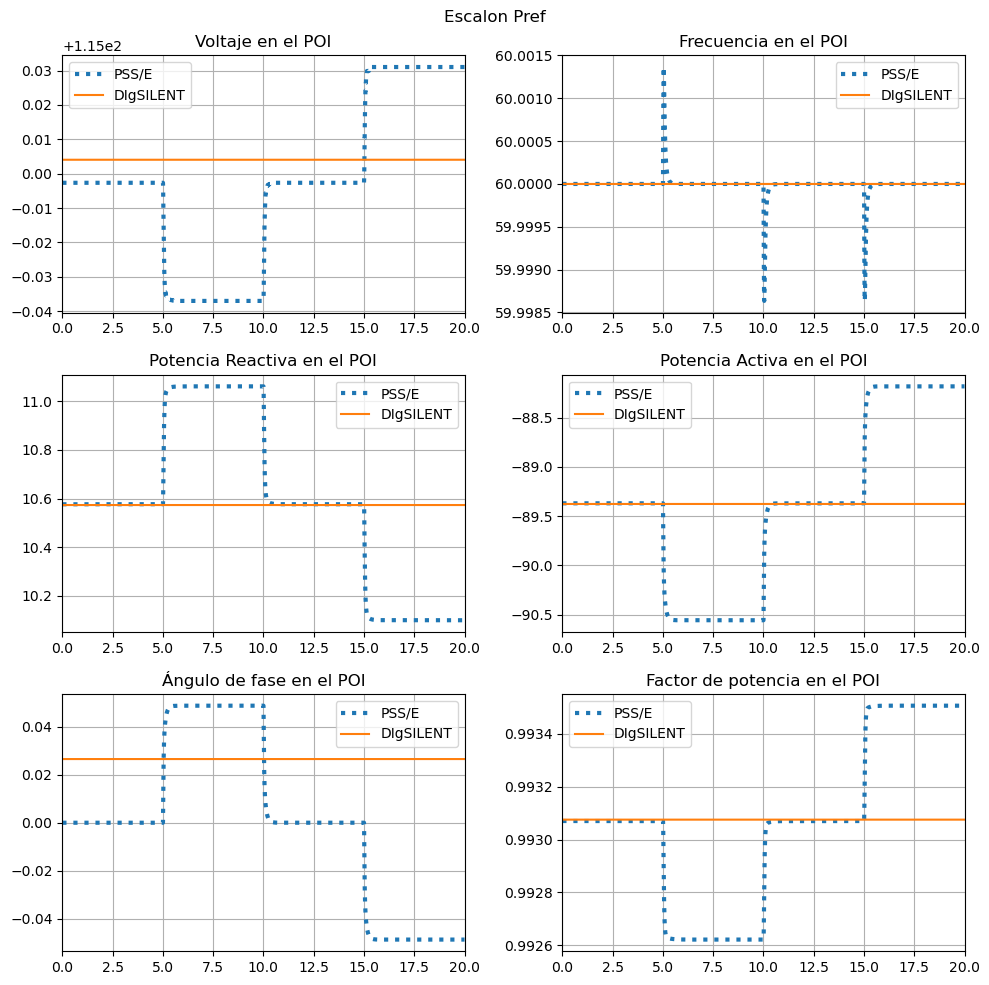

In [28]:
pss_data = pss_07
dsl_data = dsl_08
minx = 0
maxx = 20

if not isinstance(pss_data, pd.DataFrame) or not isinstance(dsl_data, pd.DataFrame):
    print("Advertencia: Uno de los DataFrames está vacío. Verifique los datos de entrada.")
else:
    fig, axs = plt.subplots(3, 2, figsize=(10,10))
    fig.suptitle('Escalon Pref')

    # Voltaje en el POI
    axs[0,0].plot(pss_data['Time(s)'], pss_data[' POI_V']*115, label='PSS/E', linestyle=':', linewidth=3)
    axs[0,0].plot(dsl_data['Time in S'], dsl_data['POI Bus m:Ul in kV'], label='DIgSILENT')
    #axs[0,0].set_ylim(70,150)
    axs[0,0].set_xlim(minx, maxx)
    axs[0,0].set_title('Voltaje en el POI')
    axs[0,0].grid(True)
    axs[0,0].legend()

    # Frecuencia en el POI
    axs[0,1].plot(pss_data['Time(s)'], pss_data[' POI_FREQ']*60+60, label='PSS/E', linestyle=':', linewidth=3)
    axs[0,1].plot(dsl_data['Time in S'], dsl_data['POI n:fehz:bus1 in Hz'], label='DIgSILENT')
    #axs[0,1].set_ylim(59.995,60.005)
    axs[0,1].ticklabel_format(style='plain', axis='y', useOffset=False)
    axs[0,1].set_xlim(minx, maxx)
    axs[0,1].set_title('Frecuencia en el POI')
    axs[0,1].grid(True)
    axs[0,1].legend()

    # Potencia Reactiva en el POI
    axs[1,0].plot(pss_data['Time(s)'], pss_data[' POI_Q'], label='PSS/E', linestyle=':', linewidth=3)
    axs[1,0].plot(dsl_data['Time in S'], dsl_data['POI m:Qsum:bus1 in Mvar'], label='DIgSILENT')
    #axs[1,0].set_ylim(0,150)
    axs[1,0].set_xlim(minx, maxx)
    axs[1,0].set_title('Potencia Reactiva en el POI')
    axs[1,0].grid(True)
    axs[1,0].legend()

    # Potencia Activa en el POI
    axs[1,1].plot(pss_data['Time(s)'], pss_data[' POI_P'], label='PSS/E', linestyle=':', linewidth=3)
    axs[1,1].plot(dsl_data['Time in S'], dsl_data['POI m:Psum:bus1 in MW'], label='DIgSILENT')
    #axs[1,1].set_ylim(-100,-70)
    axs[1,1].set_xlim(minx, maxx)
    axs[1,1].set_title('Potencia Activa en el POI')
    axs[1,1].grid(True)
    axs[1,1].legend()

    # Ángulo de fase en el POI
    axs[2,0].plot(pss_data['Time(s)'], pss_data[' POI_ANGLE'], label='PSS/E', linestyle=':', linewidth=3)
    axs[2,0].plot(dsl_data['Time in S'], dsl_data['POI Bus m:phiu in deg'], label='DIgSILENT')
    #axs[2,0].set_ylim(-100,-70)
    axs[2,0].set_xlim(minx, maxx)
    axs[2,0].set_title('Ángulo de fase en el POI')
    axs[2,0].grid(True)
    axs[2,0].legend()

    # Factor de potencia en el POI
    axs[2,1].plot(pss_data['Time(s)'], pss_data['POI_pf (pu)'], label='PSS/E', linestyle=':', linewidth=3)
    axs[2,1].plot(dsl_data['Time in S'], abs(dsl_data['POI m:cosphi:bus1']), label='DIgSILENT')
    # axs[2,1].set_ylim(0.95,1.05)
    axs[2,1].set_xlim(minx, maxx)
    axs[2,1].set_title('Factor de potencia en el POI')
    axs[2,1].grid(True)
    axs[2,1].legend()

    plt.tight_layout()
    plt.show()

### IBR

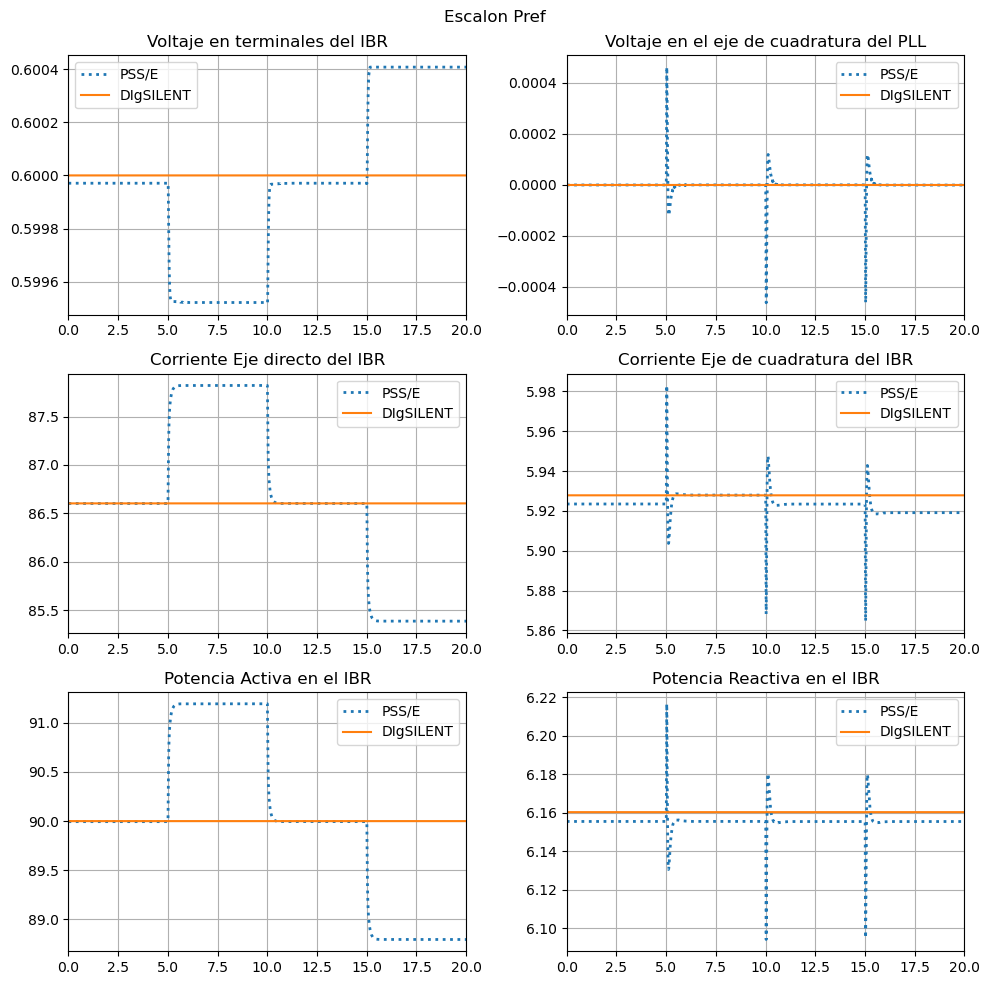

In [29]:
pss_data = pss_07
dsl_data = dsl_08
minx = 0
maxx = 20

if not isinstance(pss_data, pd.DataFrame) or not isinstance(dsl_data, pd.DataFrame):
    print("Advertencia: Uno de los DataFrames está vacío. Verifique los datos de entrada.")
else:
    fig, axs = plt.subplots(3, 2, figsize=(10,10))
    fig.suptitle('Escalon Pref')

    # Voltaje en terminales del IBR
    axs[0,0].plot(pss_data['Time(s)'], pss_data[' IBRT_V']*Vterm, label='PSS/E', linestyle=':', linewidth=2)
    axs[0,0].plot(dsl_data['Time in S'], dsl_data['IBR n:Ul:bus1 in kV'], label='DIgSILENT')
    #axs[0,0].set_ylim(0.55, 0.61)
    axs[0,0].set_xlim(minx, maxx)
    axs[0,0].set_title('Voltaje en terminales del IBR')
    axs[0,0].grid(True)
    axs[0,0].legend()

    # Voltaje en el eje de cuadratura del PLL
    axs[0,1].plot(pss_data['Time(s)'], pss_data['VQ_PLL (kV)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[0,1].plot(dsl_data['Time in S'], dsl_data['REGC_C c:uq'], label='DIgSILENT')
    #axs[0,1].set_ylim(-1,1)
    axs[0,1].set_xlim(minx, maxx)
    axs[0,1].set_title('Voltaje en el eje de cuadratura del PLL')
    axs[0,1].grid(True)
    axs[0,1].legend()

    # Corriente Eje directo del IBR
    axs[1,0].plot(pss_data['Time(s)'], pss_data['IBR_ID (kA)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[1,0].plot(dsl_data['Time in S'], dsl_data['IBR m:I1P:bus1 in kA'], label='DIgSILENT')
    #axs[1,0].set_ylim(80,90)
    axs[1,0].set_xlim(minx, maxx)
    axs[1,0].set_title('Corriente Eje directo del IBR')
    axs[1,0].grid(True)
    axs[1,0].legend()

    # Corriente Eje de cuadratura del IBR
    axs[1,1].plot(pss_data['Time(s)'], pss_data['IBR_IQ (kA)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[1,1].plot(dsl_data['Time in S'], dsl_data['IBR m:I1Q:bus1 in kA'], label='DIgSILENT')
    # axs[1,1].set_ylim(0,20)
    axs[1,1].set_xlim(minx, maxx)
    axs[1,1].set_title('Corriente Eje de cuadratura del IBR')
    axs[1,1].grid(True)
    axs[1,1].legend()

    # Potencia Activa en el IBR
    axs[2,0].plot(pss_data['Time(s)'], pss_data['IBR_P (MW)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[2,0].plot(dsl_data['Time in S'], dsl_data['IBR m:Psum:bus1 in MW'], label='DIgSILENT')
    #axs[2,0].set_ylim(60,120)
    axs[2,0].ticklabel_format(style='plain', axis='y', useOffset=False)
    axs[2,0].set_xlim(minx, maxx)
    axs[2,0].set_title('Potencia Activa en el IBR')
    axs[2,0].grid(True)
    axs[2,0].legend()

    # Potencia Reactiva en el IBR
    axs[2,1].plot(pss_data['Time(s)'], pss_data['IBR_Q (MVAR)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[2,1].plot(dsl_data['Time in S'], dsl_data['IBR m:Qsum:bus1 in Mvar'], label='DIgSILENT')
    #axs[2,1].set_ylim(5.5,6.5)
    axs[2,1].ticklabel_format(style='plain', axis='y', useOffset=False)
    axs[2,1].set_xlim(minx, maxx)
    axs[2,1].set_title('Potencia Reactiva en el IBR')
    axs[2,1].grid(True)
    axs[2,1].legend()

    plt.tight_layout()
    plt.show()

## 08 - Escalon Qref

### POI

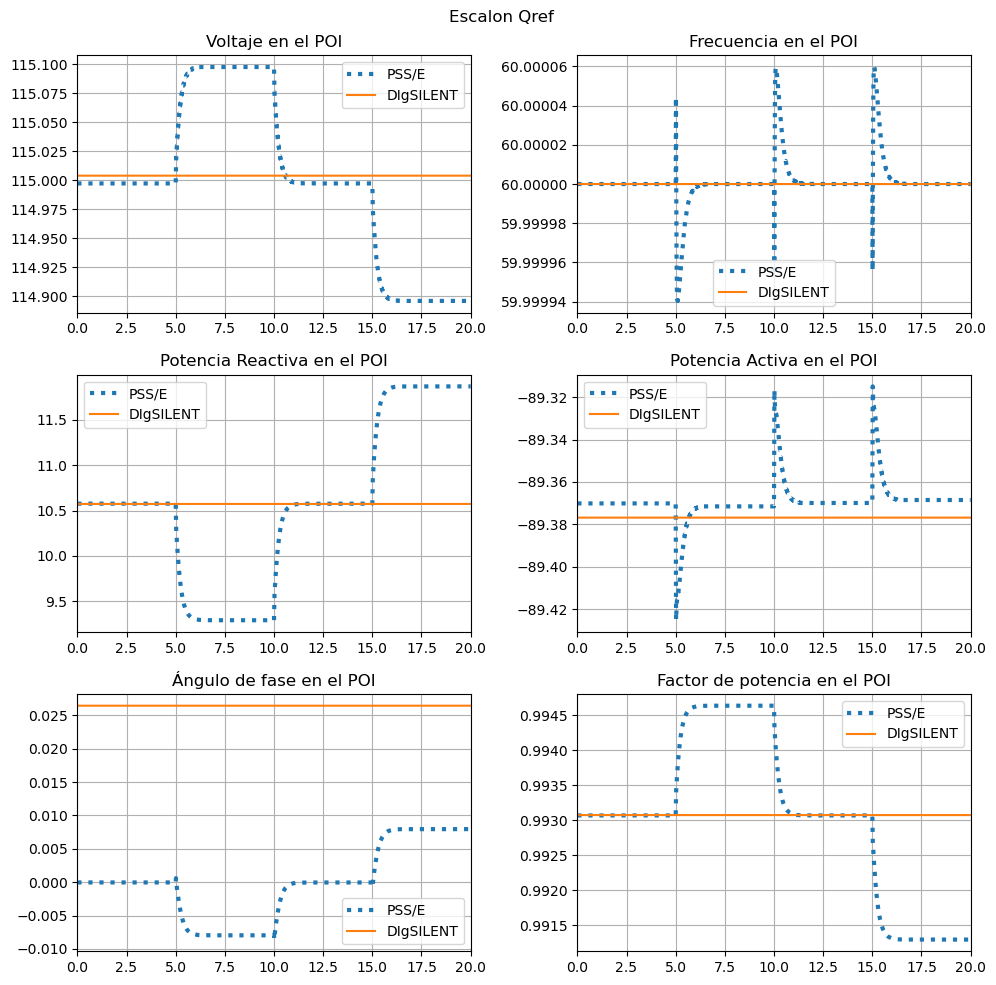

In [30]:
pss_data = pss_08
dsl_data = dsl_08
minx = 0
maxx = 20

if not isinstance(pss_data, pd.DataFrame) or not isinstance(dsl_data, pd.DataFrame):
    print("Advertencia: Uno de los DataFrames está vacío. Verifique los datos de entrada.")
else:
    fig, axs = plt.subplots(3, 2, figsize=(10,10))
    fig.suptitle('Escalon Qref')
    
    # Voltaje en el POI
    axs[0,0].plot(pss_data['Time(s)'], pss_data[' POI_V']*115, label='PSS/E', linestyle=':', linewidth=3)
    axs[0,0].plot(dsl_data['Time in S'], dsl_data['POI Bus m:Ul in kV'], label='DIgSILENT')
    #axs[0,0].set_ylim(70,150)
    axs[0,0].set_xlim(minx, maxx)
    axs[0,0].set_title('Voltaje en el POI')
    axs[0,0].grid(True)
    axs[0,0].legend()

    # Frecuencia en el POI
    axs[0,1].plot(pss_data['Time(s)'], pss_data[' POI_FREQ']*60+60, label='PSS/E', linestyle=':', linewidth=3)
    axs[0,1].plot(dsl_data['Time in S'], dsl_data['POI n:fehz:bus1 in Hz'], label='DIgSILENT')
    #axs[0,1].set_ylim(59.995,60.005)
    axs[0,1].ticklabel_format(style='plain', axis='y', useOffset=False)
    axs[0,1].set_xlim(minx, maxx)
    axs[0,1].set_title('Frecuencia en el POI')
    axs[0,1].grid(True)
    axs[0,1].legend()

    # Potencia Reactiva en el POI
    axs[1,0].plot(pss_data['Time(s)'], pss_data[' POI_Q'], label='PSS/E', linestyle=':', linewidth=3)
    axs[1,0].plot(dsl_data['Time in S'], dsl_data['POI m:Qsum:bus1 in Mvar'], label='DIgSILENT')
    #axs[1,0].set_ylim(0,150)
    axs[1,0].set_xlim(minx, maxx)
    axs[1,0].set_title('Potencia Reactiva en el POI')
    axs[1,0].grid(True)
    axs[1,0].legend()

    # Potencia Activa en el POI
    axs[1,1].plot(pss_data['Time(s)'], pss_data[' POI_P'], label='PSS/E', linestyle=':', linewidth=3)
    axs[1,1].plot(dsl_data['Time in S'], dsl_data['POI m:Psum:bus1 in MW'], label='DIgSILENT')
    #axs[1,1].set_ylim(-100,-70)
    axs[1,1].set_xlim(minx, maxx)
    axs[1,1].set_title('Potencia Activa en el POI')
    axs[1,1].grid(True)
    axs[1,1].legend()

    # Ángulo de fase en el POI
    axs[2,0].plot(pss_data['Time(s)'], pss_data[' POI_ANGLE'], label='PSS/E', linestyle=':', linewidth=3)
    axs[2,0].plot(dsl_data['Time in S'], dsl_data['POI Bus m:phiu in deg'], label='DIgSILENT')
    #axs[2,0].set_ylim(-100,-70)
    axs[2,0].set_xlim(minx, maxx)
    axs[2,0].set_title('Ángulo de fase en el POI')
    axs[2,0].grid(True)
    axs[2,0].legend()

    # Factor de potencia en el POI
    axs[2,1].plot(pss_data['Time(s)'], pss_data['POI_pf (pu)'], label='PSS/E', linestyle=':', linewidth=3)
    axs[2,1].plot(dsl_data['Time in S'], abs(dsl_data['POI m:cosphi:bus1']), label='DIgSILENT')
    # axs[2,1].set_ylim(0.95,1.05)
    axs[2,1].set_xlim(minx, maxx)
    axs[2,1].set_title('Factor de potencia en el POI')
    axs[2,1].grid(True)
    axs[2,1].legend()

    plt.tight_layout()
    plt.show()

### IBR

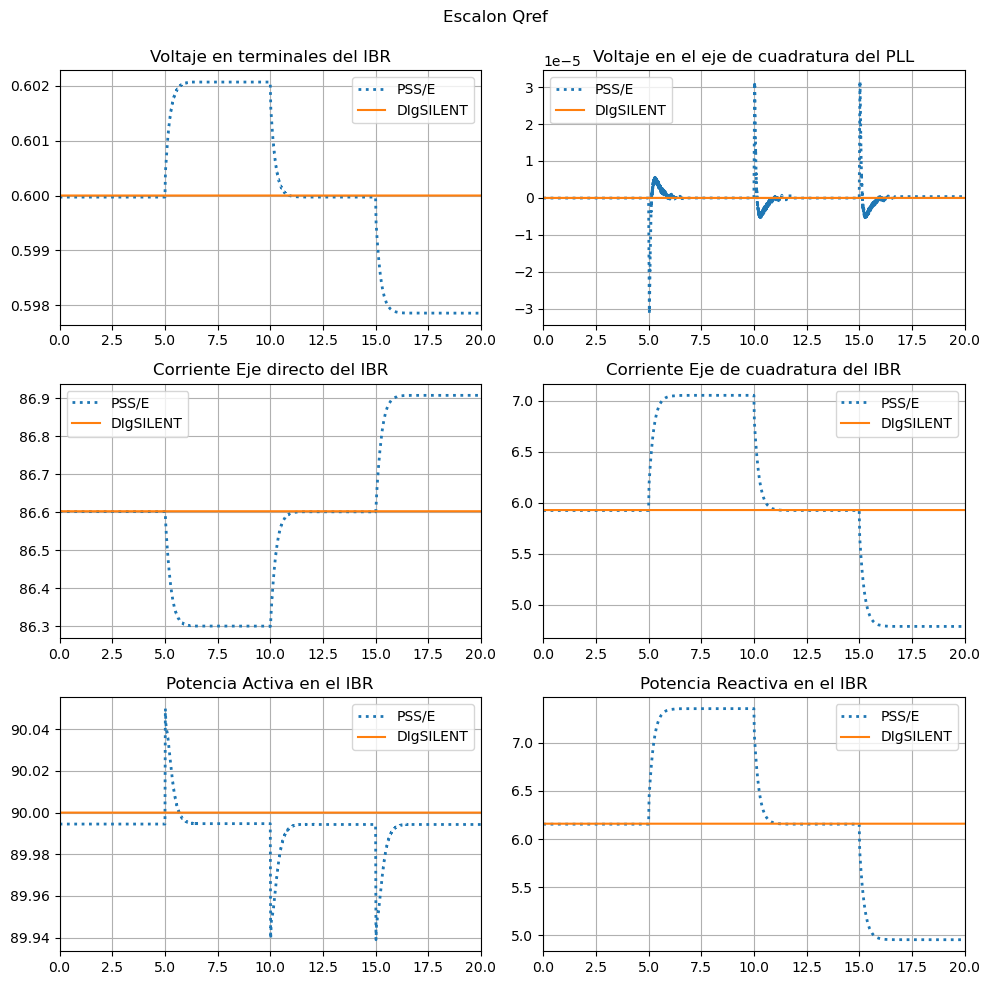

In [31]:
pss_data = pss_08
dsl_data = dsl_08
minx = 0
maxx = 20

if not isinstance(pss_data, pd.DataFrame) or not isinstance(dsl_data, pd.DataFrame):
    print("Advertencia: Uno de los DataFrames está vacío. Verifique los datos de entrada.")
else:
    fig, axs = plt.subplots(3, 2, figsize=(10,10))
    fig.suptitle('Escalon Qref')
    
    axs[0,0].plot(pss_data['Time(s)'], pss_data[' IBRT_V']*Vterm, label='PSS/E', linestyle=':', linewidth=2)
    axs[0,0].plot(dsl_data['Time in S'], dsl_data['IBR n:Ul:bus1 in kV'], label='DIgSILENT')
    #axs[0,0].set_ylim(0.55, 0.61)
    axs[0,0].set_xlim(minx, maxx)
    axs[0,0].set_title('Voltaje en terminales del IBR')
    axs[0,0].grid(True)
    axs[0,0].legend()

    # Voltaje en el eje de cuadratura del PLL
    axs[0,1].plot(pss_data['Time(s)'], pss_data['VQ_PLL (kV)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[0,1].plot(dsl_data['Time in S'], dsl_data['REGC_C c:uq'], label='DIgSILENT')
    #axs[0,1].set_ylim(-1,1)
    axs[0,1].set_xlim(minx, maxx)
    axs[0,1].set_title('Voltaje en el eje de cuadratura del PLL')
    axs[0,1].grid(True)
    axs[0,1].legend()

    # Corriente Eje directo del IBR
    axs[1,0].plot(pss_data['Time(s)'], pss_data['IBR_ID (kA)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[1,0].plot(dsl_data['Time in S'], dsl_data['IBR m:I1P:bus1 in kA'], label='DIgSILENT')
    #axs[1,0].set_ylim(80,90)
    axs[1,0].set_xlim(minx, maxx)
    axs[1,0].set_title('Corriente Eje directo del IBR')
    axs[1,0].grid(True)
    axs[1,0].legend()

    # Corriente Eje de cuadratura del IBR
    axs[1,1].plot(pss_data['Time(s)'], pss_data['IBR_IQ (kA)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[1,1].plot(dsl_data['Time in S'], dsl_data['IBR m:I1Q:bus1 in kA'], label='DIgSILENT')
    # axs[1,1].set_ylim(0,20)
    axs[1,1].set_xlim(minx, maxx)
    axs[1,1].set_title('Corriente Eje de cuadratura del IBR')
    axs[1,1].grid(True)
    axs[1,1].legend()

    # Potencia Activa en el IBR
    axs[2,0].plot(pss_data['Time(s)'], pss_data['IBR_P (MW)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[2,0].plot(dsl_data['Time in S'], dsl_data['IBR m:Psum:bus1 in MW'], label='DIgSILENT')
    #axs[2,0].set_ylim(60,120)
    axs[2,0].ticklabel_format(style='plain', axis='y', useOffset=False)
    axs[2,0].set_xlim(minx, maxx)
    axs[2,0].set_title('Potencia Activa en el IBR')
    axs[2,0].grid(True)
    axs[2,0].legend()

    # Potencia Reactiva en el IBR
    axs[2,1].plot(pss_data['Time(s)'], pss_data['IBR_Q (MVAR)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[2,1].plot(dsl_data['Time in S'], dsl_data['IBR m:Qsum:bus1 in Mvar'], label='DIgSILENT')
    #axs[2,1].set_ylim(5.5,6.5)
    axs[2,1].ticklabel_format(style='plain', axis='y', useOffset=False)
    axs[2,1].set_xlim(minx, maxx)
    axs[2,1].set_title('Potencia Reactiva en el IBR')
    axs[2,1].grid(True)
    axs[2,1].legend()

    plt.tight_layout()
    plt.show()

## 09 - REPCD Escalón Qref

### POI

In [32]:
pss_data = pss_09
dsl_data = dsl_09
minx = 0
maxx = 20

if not isinstance(pss_data, pd.DataFrame) or not isinstance(dsl_data, pd.DataFrame):
    print("Advertencia: Uno de los DataFrames está vacío. Verifique los datos de entrada.")
else:
    fig, axs = plt.subplots(3, 2, figsize=(10,10))
    fig.suptitle('REPCD Escalón Qref')
    
    # Voltaje en el POI
    axs[0,0].plot(pss_data['Time(s)'], pss_data[' POI_V']*115, label='PSS/E', linestyle=':', linewidth=3)
    axs[0,0].plot(dsl_data['Time in S'], dsl_data['POI Bus m:Ul in kV'], label='DIgSILENT')
    #axs[0,0].set_ylim(70,150)
    axs[0,0].set_xlim(minx, maxx)
    axs[0,0].set_title('Voltaje en el POI')
    axs[0,0].grid(True)
    axs[0,0].legend()

    # Frecuencia en el POI
    axs[0,1].plot(pss_data['Time(s)'], pss_data[' POI_FREQ']*60+60, label='PSS/E', linestyle=':', linewidth=3)
    axs[0,1].plot(dsl_data['Time in S'], dsl_data['POI n:fehz:bus1 in Hz'], label='DIgSILENT')
    #axs[0,1].set_ylim(59.995,60.005)
    axs[0,1].ticklabel_format(style='plain', axis='y', useOffset=False)
    axs[0,1].set_xlim(minx, maxx)
    axs[0,1].set_title('Frecuencia en el POI')
    axs[0,1].grid(True)
    axs[0,1].legend()

    # Potencia Reactiva en el POI
    axs[1,0].plot(pss_data['Time(s)'], pss_data[' POI_Q'], label='PSS/E', linestyle=':', linewidth=3)
    axs[1,0].plot(dsl_data['Time in S'], dsl_data['POI m:Qsum:bus1 in Mvar'], label='DIgSILENT')
    #axs[1,0].set_ylim(0,150)
    axs[1,0].set_xlim(minx, maxx)
    axs[1,0].set_title('Potencia Reactiva en el POI')
    axs[1,0].grid(True)
    axs[1,0].legend()

    # Potencia Activa en el POI
    axs[1,1].plot(pss_data['Time(s)'], pss_data[' POI_P'], label='PSS/E', linestyle=':', linewidth=3)
    axs[1,1].plot(dsl_data['Time in S'], dsl_data['POI m:Psum:bus1 in MW'], label='DIgSILENT')
    #axs[1,1].set_ylim(-100,-70)
    axs[1,1].set_xlim(minx, maxx)
    axs[1,1].set_title('Potencia Activa en el POI')
    axs[1,1].grid(True)
    axs[1,1].legend()

    # Ángulo de fase en el POI
    axs[2,0].plot(pss_data['Time(s)'], pss_data[' POI_ANGLE'], label='PSS/E', linestyle=':', linewidth=3)
    axs[2,0].plot(dsl_data['Time in S'], dsl_data['POI Bus m:phiu in deg'], label='DIgSILENT')
    #axs[2,0].set_ylim(-100,-70)
    axs[2,0].set_xlim(minx, maxx)
    axs[2,0].set_title('Ángulo de fase en el POI')
    axs[2,0].grid(True)
    axs[2,0].legend()

    # Factor de potencia en el POI
    axs[2,1].plot(pss_data['Time(s)'], pss_data['POI_pf (pu)'], label='PSS/E', linestyle=':', linewidth=3)
    axs[2,1].plot(dsl_data['Time in S'], abs(dsl_data['POI m:cosphi:bus1']), label='DIgSILENT')
    # axs[2,1].set_ylim(0.95,1.05)
    axs[2,1].set_xlim(minx, maxx)
    axs[2,1].set_title('Factor de potencia en el POI')
    axs[2,1].grid(True)
    axs[2,1].legend()

    plt.tight_layout()
    plt.show()

Advertencia: Uno de los DataFrames está vacío. Verifique los datos de entrada.


### IBR

In [33]:
pss_data = pss_09
dsl_data = dsl_09
minx = 0
maxx = 20

if not isinstance(pss_data, pd.DataFrame) or not isinstance(dsl_data, pd.DataFrame):
    print("Advertencia: Uno de los DataFrames está vacío. Verifique los datos de entrada.")
else:
    fig, axs = plt.subplots(4, 2, figsize=(10,10))
    fig.suptitle('REPCD Escalón Qref')
    
    # Voltaje en terminales del IBR
    axs[0,0].plot(pss_data['Time(s)'], pss_data[' IBRT_V']*Vterm, label='PSS/E', linestyle=':', linewidth=2)
    axs[0,0].plot(dsl_data['Time in S'], dsl_data['IBR n:Ul:bus1 in kV'], label='DIgSILENT')
    #axs[0,0].set_ylim(0.55, 0.61)
    axs[0,0].set_xlim(minx, maxx)
    axs[0,0].set_title('Voltaje en terminales del IBR')
    axs[0,0].grid(True)
    axs[0,0].legend()

    # Voltaje en el eje de cuadratura del PLL
    axs[0,1].plot(pss_data['Time(s)'], pss_data['VQ_PLL (kV)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[0,1].plot(dsl_data['Time in S'], dsl_data['REGC_C c:uq'], label='DIgSILENT')
    #axs[0,1].set_ylim(-1,1)
    axs[0,1].set_xlim(minx, maxx)
    axs[0,1].set_title('Voltaje en el eje de cuadratura del PLL')
    axs[0,1].grid(True)
    axs[0,1].legend()

    # Corriente Eje directo del IBR
    axs[1,0].plot(pss_data['Time(s)'], pss_data['IBR_ID (kA)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[1,0].plot(dsl_data['Time in S'], dsl_data['IBR m:I1P:bus1 in kA'], label='DIgSILENT')
    #axs[1,0].set_ylim(80,90)
    axs[1,0].set_xlim(minx, maxx)
    axs[1,0].set_title('Corriente Eje directo del IBR')
    axs[1,0].grid(True)
    axs[1,0].legend()

    # Corriente Eje de cuadratura del IBR
    axs[1,1].plot(pss_data['Time(s)'], pss_data['IBR_IQ (kA)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[1,1].plot(dsl_data['Time in S'], dsl_data['IBR m:I1Q:bus1 in kA'], label='DIgSILENT')
    # axs[1,1].set_ylim(0,20)
    axs[1,1].set_xlim(minx, maxx)
    axs[1,1].set_title('Corriente Eje de cuadratura del IBR')
    axs[1,1].grid(True)
    axs[1,1].legend()

    # Potencia Activa en el IBR
    axs[2,0].plot(pss_data['Time(s)'], pss_data['IBR_P (MW)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[2,0].plot(dsl_data['Time in S'], dsl_data['IBR m:Psum:bus1 in MW'], label='DIgSILENT')
    #axs[2,0].set_ylim(60,120)
    axs[2,0].ticklabel_format(style='plain', axis='y', useOffset=False)
    axs[2,0].set_xlim(minx, maxx)
    axs[2,0].set_title('Potencia Activa en el IBR')
    axs[2,0].grid(True)
    axs[2,0].legend()

    # Potencia Reactiva en el IBR
    axs[2,1].plot(pss_data['Time(s)'], pss_data['IBR_Q (MVAR)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[2,1].plot(dsl_data['Time in S'], dsl_data['IBR m:Qsum:bus1 in Mvar'], label='DIgSILENT')
    #axs[2,1].set_ylim(5.5,6.5)
    axs[2,1].ticklabel_format(style='plain', axis='y', useOffset=False)
    axs[2,1].set_xlim(minx, maxx)
    axs[2,1].set_title('Potencia Reactiva en el IBR')
    axs[2,1].grid(True)
    axs[2,1].legend()


    # Ángulo en el IBR
    #axs[2,1].plot(pss_data['Time(s)'], pss_data['IBR_Q (MVAR)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[3,0].plot(dsl_data['Time in S'], dsl_data['Terminal 5 m:phiurel in deg'], label='DIgSILENT')
    #axs[3,1].set_ylim(5.5,6.5)
    axs[3,0].ticklabel_format(style='plain', axis='y', useOffset=False)
    axs[3,0].set_xlim(minx, maxx)
    axs[3,0].set_title('Ángulo en el IBR')
    axs[3,0].grid(True)
    axs[3,0].legend()


    # Factor de potencia calculado en el IBR
    #axs[2,1].plot(pss_data['Time(s)'], pss_data['IBR_Q (MVAR)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[3,1].plot(dsl_data['Time in S'], dsl_data['IBR m:cosphi:bus1'], label='DIgSILENT (Medido)')
    axs[3,1].plot(dsl_data['Time in S'], np.cos(dsl_data['REEC_E s:PFAref']), label='DIgSILENT (Referencia)')
    #axs[3,1].set_ylim(5.5,6.5)
    axs[3,1].ticklabel_format(style='plain', axis='y', useOffset=False)
    axs[3,1].set_xlim(minx, maxx)
    axs[3,1].set_title('Factor de potencia en el IBR')
    axs[3,1].grid(True)
    axs[3,1].legend()

    plt.tight_layout()
    plt.show()

Advertencia: Uno de los DataFrames está vacío. Verifique los datos de entrada.


In [34]:
#### Código para asignar las mismas variables a tooodos los casos de estudio. Se encuentra sin completar ##################
# oFoldStudy = app.GetProjectFolder('study')  # Obtenemos la carpeta de estudio del proyecto
# sStudyCase = oFoldStudy.GetContents('*.IntCase', 1)  # Obtenemos todos los casos de estudio del proyecto
# sStudyCase.sort(key=lambda x: x.loc_name)  # Ordenamos los casos de estudio por nombre para que se guarden en el mismo orden que los archivos de resultados

# oFoldLib = app.GetProjectFolder('lib')
# oGenResults = oFoldLib.GetContents('General calculations.ElmRes')[0]  # Obtenemos el elemento de resultados genéricos
# sVarResults = oGenResults.GetContents('*.IntMon')

# app.PrintPlain(oGenResults)

# for oStudyCase in sStudyCase:
#     oLocResults = oStudyCase.GetContents('*.ElmRes')[0]  # Obtenemos los resultados específicos del caso de estudio
#     oComInc = oStudyCase.GetContents('*.ComInc')[0]  # Obtenemos los incrementos de carga específicos del caso de estudio
#     oComInc.p_resvar = oGenResults # Asignamos el archivo de resultados general a cada caso de estudios
#     app.PrintPlain(f"   Resultados locales de {oStudyCase}: {oComInc.p_resvar}...")
#     oLocResults.D

## 10 - REPCD Escalón Vref

### POI

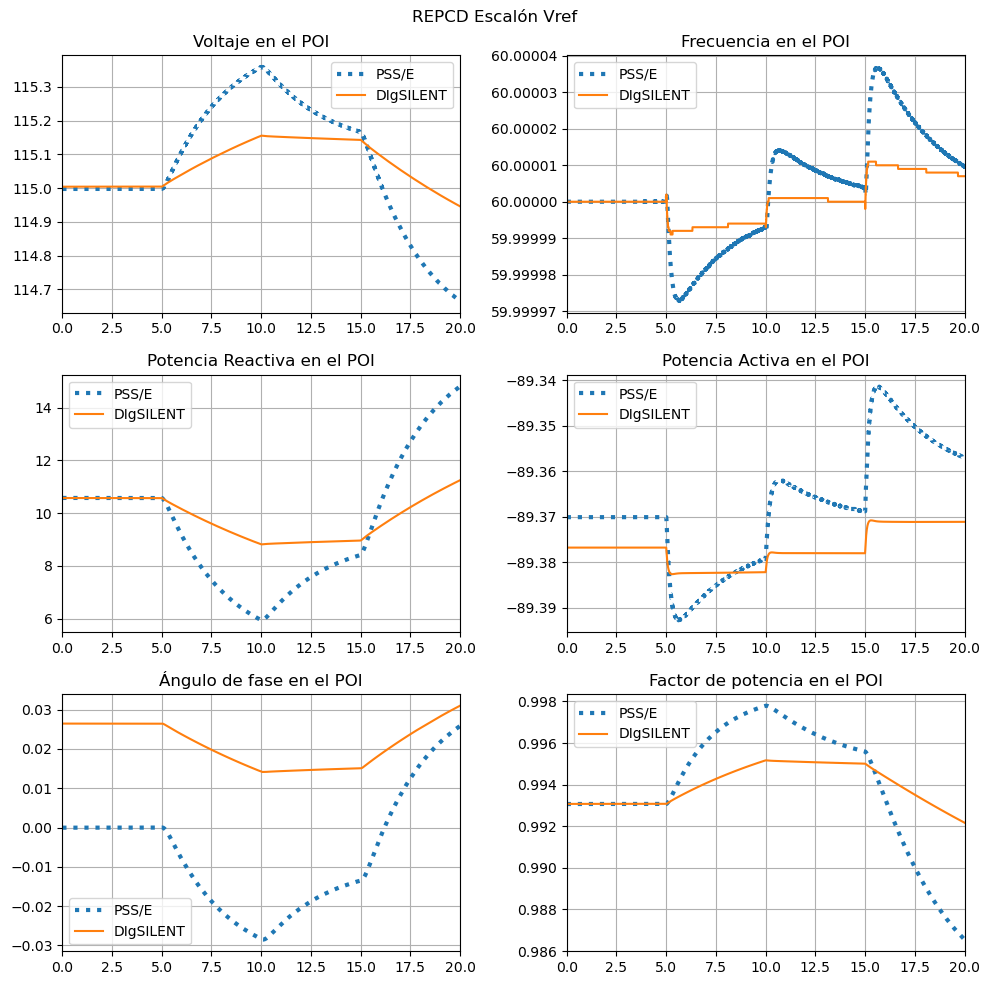

In [35]:
pss_data = pss_10
dsl_data = dsl_10
minx = 0
maxx = 20

if not isinstance(pss_data, pd.DataFrame) or not isinstance(dsl_data, pd.DataFrame):
    print("Advertencia: Uno de los DataFrames está vacío. Verifique los datos de entrada.")
else:
    fig, axs = plt.subplots(3, 2, figsize=(10,10))
    fig.suptitle('REPCD Escalón Vref')
    
    # Voltaje en el POI
    axs[0,0].plot(pss_data['Time(s)'], pss_data[' POI_V']*115, label='PSS/E', linestyle=':', linewidth=3)
    axs[0,0].plot(dsl_data['Time in S'], dsl_data['POI Bus m:Ul in kV'], label='DIgSILENT')
    #axs[0,0].set_ylim(70,150)
    axs[0,0].set_xlim(minx, maxx)
    axs[0,0].set_title('Voltaje en el POI')
    axs[0,0].grid(True)
    axs[0,0].legend()

    # Frecuencia en el POI
    axs[0,1].plot(pss_data['Time(s)'], pss_data[' POI_FREQ']*60+60, label='PSS/E', linestyle=':', linewidth=3)
    axs[0,1].plot(dsl_data['Time in S'], dsl_data['POI n:fehz:bus1 in Hz'], label='DIgSILENT')
    #axs[0,1].set_ylim(59.995,60.005)
    axs[0,1].ticklabel_format(style='plain', axis='y', useOffset=False)
    axs[0,1].set_xlim(minx, maxx)
    axs[0,1].set_title('Frecuencia en el POI')
    axs[0,1].grid(True)
    axs[0,1].legend()

    # Potencia Reactiva en el POI
    axs[1,0].plot(pss_data['Time(s)'], pss_data[' POI_Q'], label='PSS/E', linestyle=':', linewidth=3)
    axs[1,0].plot(dsl_data['Time in S'], dsl_data['POI m:Qsum:bus1 in Mvar'], label='DIgSILENT')
    #axs[1,0].set_ylim(0,150)
    axs[1,0].set_xlim(minx, maxx)
    axs[1,0].set_title('Potencia Reactiva en el POI')
    axs[1,0].grid(True)
    axs[1,0].legend()

    # Potencia Activa en el POI
    axs[1,1].plot(pss_data['Time(s)'], pss_data[' POI_P'], label='PSS/E', linestyle=':', linewidth=3)
    axs[1,1].plot(dsl_data['Time in S'], dsl_data['POI m:Psum:bus1 in MW'], label='DIgSILENT')
    #axs[1,1].set_ylim(-100,-70)
    axs[1,1].set_xlim(minx, maxx)
    axs[1,1].set_title('Potencia Activa en el POI')
    axs[1,1].grid(True)
    axs[1,1].legend()

    # Ángulo de fase en el POI
    axs[2,0].plot(pss_data['Time(s)'], pss_data[' POI_ANGLE'], label='PSS/E', linestyle=':', linewidth=3)
    axs[2,0].plot(dsl_data['Time in S'], dsl_data['POI Bus m:phiu in deg'], label='DIgSILENT')
    #axs[2,0].set_ylim(-100,-70)
    axs[2,0].set_xlim(minx, maxx)
    axs[2,0].set_title('Ángulo de fase en el POI')
    axs[2,0].grid(True)
    axs[2,0].legend()

    # Factor de potencia en el POI
    axs[2,1].plot(pss_data['Time(s)'], pss_data['POI_pf (pu)'], label='PSS/E', linestyle=':', linewidth=3)
    axs[2,1].plot(dsl_data['Time in S'], abs(dsl_data['POI m:cosphi:bus1']), label='DIgSILENT')
    # axs[2,1].set_ylim(0.95,1.05)
    axs[2,1].set_xlim(minx, maxx)
    axs[2,1].set_title('Factor de potencia en el POI')
    axs[2,1].grid(True)
    axs[2,1].legend()

    plt.tight_layout()
    plt.show()

### IBR

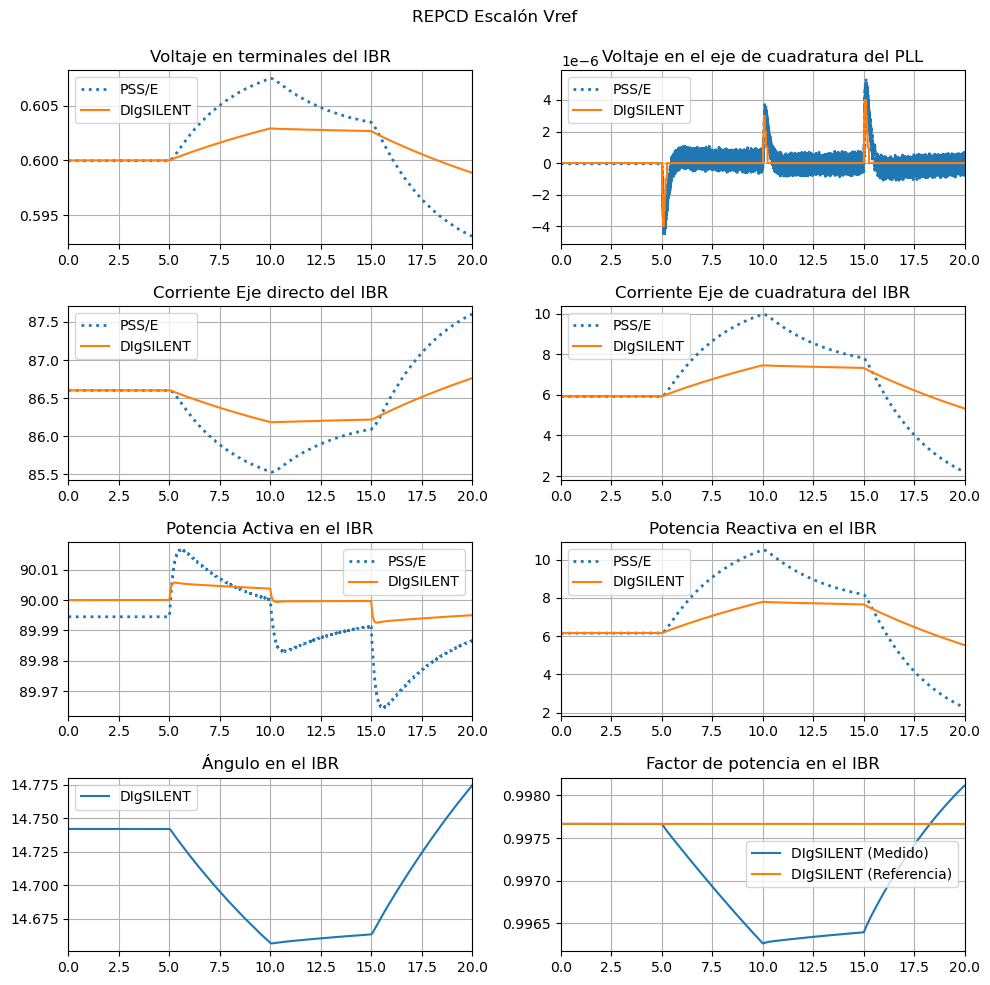

In [36]:
pss_data = pss_10
dsl_data = dsl_10
minx = 0
maxx = 20

if not isinstance(pss_data, pd.DataFrame) or not isinstance(dsl_data, pd.DataFrame):
    print("Advertencia: Uno de los DataFrames está vacío. Verifique los datos de entrada.")
else:
    fig, axs = plt.subplots(4, 2, figsize=(10,10))
    fig.suptitle('REPCD Escalón Vref')
    
    # Voltaje en terminales del IBR
    axs[0,0].plot(pss_data['Time(s)'], pss_data[' IBRT_V']*Vterm, label='PSS/E', linestyle=':', linewidth=2)
    axs[0,0].plot(dsl_data['Time in S'], dsl_data['IBR n:Ul:bus1 in kV'], label='DIgSILENT')
    #axs[0,0].set_ylim(0.55, 0.61)
    axs[0,0].set_xlim(minx, maxx)
    axs[0,0].set_title('Voltaje en terminales del IBR')
    axs[0,0].grid(True)
    axs[0,0].legend()

    # Voltaje en el eje de cuadratura del PLL
    axs[0,1].plot(pss_data['Time(s)'], pss_data['VQ_PLL (kV)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[0,1].plot(dsl_data['Time in S'], dsl_data['REGC_C c:uq'], label='DIgSILENT')
    #axs[0,1].set_ylim(-1,1)
    axs[0,1].set_xlim(minx, maxx)
    axs[0,1].set_title('Voltaje en el eje de cuadratura del PLL')
    axs[0,1].grid(True)
    axs[0,1].legend()

    # Corriente Eje directo del IBR
    axs[1,0].plot(pss_data['Time(s)'], pss_data['IBR_ID (kA)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[1,0].plot(dsl_data['Time in S'], dsl_data['IBR m:I1P:bus1 in kA'], label='DIgSILENT')
    #axs[1,0].set_ylim(80,90)
    axs[1,0].set_xlim(minx, maxx)
    axs[1,0].set_title('Corriente Eje directo del IBR')
    axs[1,0].grid(True)
    axs[1,0].legend()

    # Corriente Eje de cuadratura del IBR
    axs[1,1].plot(pss_data['Time(s)'], pss_data['IBR_IQ (kA)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[1,1].plot(dsl_data['Time in S'], dsl_data['IBR m:I1Q:bus1 in kA'], label='DIgSILENT')
    # axs[1,1].set_ylim(0,20)
    axs[1,1].set_xlim(minx, maxx)
    axs[1,1].set_title('Corriente Eje de cuadratura del IBR')
    axs[1,1].grid(True)
    axs[1,1].legend()

    # Potencia Activa en el IBR
    axs[2,0].plot(pss_data['Time(s)'], pss_data['IBR_P (MW)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[2,0].plot(dsl_data['Time in S'], dsl_data['IBR m:Psum:bus1 in MW'], label='DIgSILENT')
    #axs[2,0].set_ylim(60,120)
    axs[2,0].ticklabel_format(style='plain', axis='y', useOffset=False)
    axs[2,0].set_xlim(minx, maxx)
    axs[2,0].set_title('Potencia Activa en el IBR')
    axs[2,0].grid(True)
    axs[2,0].legend()

    # Potencia Reactiva en el IBR
    axs[2,1].plot(pss_data['Time(s)'], pss_data['IBR_Q (MVAR)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[2,1].plot(dsl_data['Time in S'], dsl_data['IBR m:Qsum:bus1 in Mvar'], label='DIgSILENT')
    #axs[2,1].set_ylim(5.5,6.5)
    axs[2,1].ticklabel_format(style='plain', axis='y', useOffset=False)
    axs[2,1].set_xlim(minx, maxx)
    axs[2,1].set_title('Potencia Reactiva en el IBR')
    axs[2,1].grid(True)
    axs[2,1].legend()


    # Ángulo en el IBR
    #axs[2,1].plot(pss_data['Time(s)'], pss_data['IBR_Q (MVAR)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[3,0].plot(dsl_data['Time in S'], dsl_data['Terminal 5 m:phiurel in deg'], label='DIgSILENT')
    #axs[3,1].set_ylim(5.5,6.5)
    axs[3,0].ticklabel_format(style='plain', axis='y', useOffset=False)
    axs[3,0].set_xlim(minx, maxx)
    axs[3,0].set_title('Ángulo en el IBR')
    axs[3,0].grid(True)
    axs[3,0].legend()


    # Factor de potencia calculado en el IBR
    #axs[2,1].plot(pss_data['Time(s)'], pss_data['IBR_Q (MVAR)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[3,1].plot(dsl_data['Time in S'], dsl_data['IBR m:cosphi:bus1'], label='DIgSILENT (Medido)')
    axs[3,1].plot(dsl_data['Time in S'], np.cos(dsl_data['REEC_E s:PFAref']), label='DIgSILENT (Referencia)')
    #axs[3,1].set_ylim(5.5,6.5)
    axs[3,1].ticklabel_format(style='plain', axis='y', useOffset=False)
    axs[3,1].set_xlim(minx, maxx)
    axs[3,1].set_title('Factor de potencia en el IBR')
    axs[3,1].grid(True)
    axs[3,1].legend()

    plt.tight_layout()
    plt.show()

In [37]:
#### Código para asignar las mismas variables a tooodos los casos de estudio. Se encuentra sin completar ##################
# oFoldStudy = app.GetProjectFolder('study')  # Obtenemos la carpeta de estudio del proyecto
# sStudyCase = oFoldStudy.GetContents('*.IntCase', 1)  # Obtenemos todos los casos de estudio del proyecto
# sStudyCase.sort(key=lambda x: x.loc_name)  # Ordenamos los casos de estudio por nombre para que se guarden en el mismo orden que los archivos de resultados

# oFoldLib = app.GetProjectFolder('lib')
# oGenResults = oFoldLib.GetContents('General calculations.ElmRes')[0]  # Obtenemos el elemento de resultados genéricos
# sVarResults = oGenResults.GetContents('*.IntMon')

# app.PrintPlain(oGenResults)

# for oStudyCase in sStudyCase:
#     oLocResults = oStudyCase.GetContents('*.ElmRes')[0]  # Obtenemos los resultados específicos del caso de estudio
#     oComInc = oStudyCase.GetContents('*.ComInc')[0]  # Obtenemos los incrementos de carga específicos del caso de estudio
#     oComInc.p_resvar = oGenResults # Asignamos el archivo de resultados general a cada caso de estudios
#     app.PrintPlain(f"   Resultados locales de {oStudyCase}: {oComInc.p_resvar}...")
#     oLocResults.D

## 11 - REPCD Escalón PFref

### POI

In [38]:
pss_data = pss_11
dsl_data = dsl_11
minx = 0
maxx = 20

if not isinstance(pss_data, pd.DataFrame) or not isinstance(dsl_data, pd.DataFrame):
    print("Advertencia: Uno de los DataFrames está vacío. Verifique los datos de entrada.")
else:
    fig, axs = plt.subplots(3, 2, figsize=(10,10))
    fig.suptitle('REPCD Escalón PFref')
    
    # Voltaje en el POI
    axs[0,0].plot(pss_data['Time(s)'], pss_data[' POI_V']*115, label='PSS/E', linestyle=':', linewidth=3)
    axs[0,0].plot(dsl_data['Time in S'], dsl_data['POI Bus m:Ul in kV'], label='DIgSILENT')
    #axs[0,0].set_ylim(70,150)
    axs[0,0].set_xlim(minx, maxx)
    axs[0,0].set_title('Voltaje en el POI')
    axs[0,0].grid(True)
    axs[0,0].legend()

    # Frecuencia en el POI
    axs[0,1].plot(pss_data['Time(s)'], pss_data[' POI_FREQ']*60+60, label='PSS/E', linestyle=':', linewidth=3)
    axs[0,1].plot(dsl_data['Time in S'], dsl_data['POI n:fehz:bus1 in Hz'], label='DIgSILENT')
    #axs[0,1].set_ylim(59.995,60.005)
    axs[0,1].ticklabel_format(style='plain', axis='y', useOffset=False)
    axs[0,1].set_xlim(minx, maxx)
    axs[0,1].set_title('Frecuencia en el POI')
    axs[0,1].grid(True)
    axs[0,1].legend()

    # Potencia Reactiva en el POI
    axs[1,0].plot(pss_data['Time(s)'], pss_data[' POI_Q'], label='PSS/E', linestyle=':', linewidth=3)
    axs[1,0].plot(dsl_data['Time in S'], dsl_data['POI m:Qsum:bus1 in Mvar'], label='DIgSILENT')
    #axs[1,0].set_ylim(0,150)
    axs[1,0].set_xlim(minx, maxx)
    axs[1,0].set_title('Potencia Reactiva en el POI')
    axs[1,0].grid(True)
    axs[1,0].legend()

    # Potencia Activa en el POI
    axs[1,1].plot(pss_data['Time(s)'], pss_data[' POI_P'], label='PSS/E', linestyle=':', linewidth=3)
    axs[1,1].plot(dsl_data['Time in S'], dsl_data['POI m:Psum:bus1 in MW'], label='DIgSILENT')
    #axs[1,1].set_ylim(-100,-70)
    axs[1,1].set_xlim(minx, maxx)
    axs[1,1].set_title('Potencia Activa en el POI')
    axs[1,1].grid(True)
    axs[1,1].legend()

    # Ángulo de fase en el POI
    axs[2,0].plot(pss_data['Time(s)'], pss_data[' POI_ANGLE'], label='PSS/E', linestyle=':', linewidth=3)
    axs[2,0].plot(dsl_data['Time in S'], dsl_data['POI Bus m:phiu in deg'], label='DIgSILENT')
    #axs[2,0].set_ylim(-100,-70)
    axs[2,0].set_xlim(minx, maxx)
    axs[2,0].set_title('Ángulo de fase en el POI')
    axs[2,0].grid(True)
    axs[2,0].legend()

    # Factor de potencia en el POI
    axs[2,1].plot(pss_data['Time(s)'], pss_data['POI_pf (pu)'], label='PSS/E', linestyle=':', linewidth=3)
    axs[2,1].plot(dsl_data['Time in S'], abs(dsl_data['POI m:cosphi:bus1']), label='DIgSILENT')
    # axs[2,1].set_ylim(0.95,1.05)
    axs[2,1].set_xlim(minx, maxx)
    axs[2,1].set_title('Factor de potencia en el POI')
    axs[2,1].grid(True)
    axs[2,1].legend()

    plt.tight_layout()
    plt.show()

Advertencia: Uno de los DataFrames está vacío. Verifique los datos de entrada.


### IBR

In [39]:
pss_data = pss_11
dsl_data = dsl_11
minx = 0
maxx = 20

if not isinstance(pss_data, pd.DataFrame) or not isinstance(dsl_data, pd.DataFrame):
    print("Advertencia: Uno de los DataFrames está vacío. Verifique los datos de entrada.")
else:
    fig, axs = plt.subplots(4, 2, figsize=(10,10))
    fig.suptitle('REPCD Escalón PFref')
    
    # Voltaje en terminales del IBR
    axs[0,0].plot(pss_data['Time(s)'], pss_data[' IBRT_V']*Vterm, label='PSS/E', linestyle=':', linewidth=2)
    axs[0,0].plot(dsl_data['Time in S'], dsl_data['IBR n:Ul:bus1 in kV'], label='DIgSILENT')
    #axs[0,0].set_ylim(0.55, 0.61)
    axs[0,0].set_xlim(minx, maxx)
    axs[0,0].set_title('Voltaje en terminales del IBR')
    axs[0,0].grid(True)
    axs[0,0].legend()

    # Voltaje en el eje de cuadratura del PLL
    axs[0,1].plot(pss_data['Time(s)'], pss_data['VQ_PLL (kV)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[0,1].plot(dsl_data['Time in S'], dsl_data['REGC_C c:uq'], label='DIgSILENT')
    #axs[0,1].set_ylim(-1,1)
    axs[0,1].set_xlim(minx, maxx)
    axs[0,1].set_title('Voltaje en el eje de cuadratura del PLL')
    axs[0,1].grid(True)
    axs[0,1].legend()

    # Corriente Eje directo del IBR
    axs[1,0].plot(pss_data['Time(s)'], pss_data['IBR_ID (kA)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[1,0].plot(dsl_data['Time in S'], dsl_data['IBR m:I1P:bus1 in kA'], label='DIgSILENT')
    #axs[1,0].set_ylim(80,90)
    axs[1,0].set_xlim(minx, maxx)
    axs[1,0].set_title('Corriente Eje directo del IBR')
    axs[1,0].grid(True)
    axs[1,0].legend()

    # Corriente Eje de cuadratura del IBR
    axs[1,1].plot(pss_data['Time(s)'], pss_data['IBR_IQ (kA)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[1,1].plot(dsl_data['Time in S'], dsl_data['IBR m:I1Q:bus1 in kA'], label='DIgSILENT')
    # axs[1,1].set_ylim(0,20)
    axs[1,1].set_xlim(minx, maxx)
    axs[1,1].set_title('Corriente Eje de cuadratura del IBR')
    axs[1,1].grid(True)
    axs[1,1].legend()

    # Potencia Activa en el IBR
    axs[2,0].plot(pss_data['Time(s)'], pss_data['IBR_P (MW)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[2,0].plot(dsl_data['Time in S'], dsl_data['IBR m:Psum:bus1 in MW'], label='DIgSILENT')
    #axs[2,0].set_ylim(60,120)
    axs[2,0].ticklabel_format(style='plain', axis='y', useOffset=False)
    axs[2,0].set_xlim(minx, maxx)
    axs[2,0].set_title('Potencia Activa en el IBR')
    axs[2,0].grid(True)
    axs[2,0].legend()

    # Potencia Reactiva en el IBR
    axs[2,1].plot(pss_data['Time(s)'], pss_data['IBR_Q (MVAR)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[2,1].plot(dsl_data['Time in S'], dsl_data['IBR m:Qsum:bus1 in Mvar'], label='DIgSILENT')
    #axs[2,1].set_ylim(5.5,6.5)
    axs[2,1].ticklabel_format(style='plain', axis='y', useOffset=False)
    axs[2,1].set_xlim(minx, maxx)
    axs[2,1].set_title('Potencia Reactiva en el IBR')
    axs[2,1].grid(True)
    axs[2,1].legend()


    # Ángulo en el IBR
    #axs[2,1].plot(pss_data['Time(s)'], pss_data['IBR_Q (MVAR)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[3,0].plot(dsl_data['Time in S'], dsl_data['Terminal 5 m:phiurel in deg'], label='DIgSILENT')
    #axs[3,1].set_ylim(5.5,6.5)
    axs[3,0].ticklabel_format(style='plain', axis='y', useOffset=False)
    axs[3,0].set_xlim(minx, maxx)
    axs[3,0].set_title('Ángulo en el IBR')
    axs[3,0].grid(True)
    axs[3,0].legend()


    # Factor de potencia calculado en el IBR
    #axs[2,1].plot(pss_data['Time(s)'], pss_data['IBR_Q (MVAR)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[3,1].plot(dsl_data['Time in S'], dsl_data['IBR m:cosphi:bus1'], label='DIgSILENT (Medido)')
    axs[3,1].plot(dsl_data['Time in S'], np.cos(dsl_data['REEC_E s:PFAref']), label='DIgSILENT (Referencia)')
    #axs[3,1].set_ylim(5.5,6.5)
    axs[3,1].ticklabel_format(style='plain', axis='y', useOffset=False)
    axs[3,1].set_xlim(minx, maxx)
    axs[3,1].set_title('Factor de potencia en el IBR')
    axs[3,1].grid(True)
    axs[3,1].legend()

    plt.tight_layout()
    plt.show()

Advertencia: Uno de los DataFrames está vacío. Verifique los datos de entrada.


## 12 - REPCD Escalón Pref

### POI

In [40]:
pss_data = pss_12
dsl_data = dsl_12
minx = 0
maxx = 20

if not isinstance(pss_data, pd.DataFrame) or not isinstance(dsl_data, pd.DataFrame):
    print("Advertencia: Uno de los DataFrames está vacío. Verifique los datos de entrada.")
else:
    fig, axs = plt.subplots(3, 2, figsize=(10,10))
    fig.suptitle('REPCD Escalón Pref')
    
    # Voltaje en el POI
    axs[0,0].plot(pss_data['Time(s)'], pss_data[' POI_V']*115, label='PSS/E', linestyle=':', linewidth=3)
    axs[0,0].plot(dsl_data['Time in S'], dsl_data['POI Bus m:Ul in kV'], label='DIgSILENT')
    # axs[0,0].set_ylim(114,116)
    axs[0,0].ticklabel_format(style='plain', axis='y', useOffset=False)
    axs[0,0].set_xlim(minx, maxx)
    axs[0,0].set_title('Voltaje en el POI')
    axs[0,0].grid(True)
    axs[0,0].legend()

    # Frecuencia en el POI
    axs[0,1].plot(pss_data['Time(s)'], pss_data[' POI_FREQ']*60+60, label='PSS/E', linestyle=':', linewidth=3)
    axs[0,1].plot(dsl_data['Time in S'], dsl_data['POI n:fehz:bus1 in Hz'], label='DIgSILENT')
    #axs[0,1].set_ylim(59.995,60.005)
    axs[0,1].ticklabel_format(style='plain', axis='y', useOffset=False)
    axs[0,1].set_xlim(minx, maxx)
    axs[0,1].set_title('Frecuencia en el POI')
    axs[0,1].grid(True)
    axs[0,1].legend()

    # Potencia Reactiva en el POI
    axs[1,0].plot(pss_data['Time(s)'], pss_data[' POI_Q'], label='PSS/E', linestyle=':', linewidth=3)
    axs[1,0].plot(dsl_data['Time in S'], dsl_data['POI m:Qsum:bus1 in Mvar'], label='DIgSILENT')
    #axs[1,0].set_ylim(0,150)
    axs[1,0].set_xlim(minx, maxx)
    axs[1,0].set_title('Potencia Reactiva en el POI')
    axs[1,0].grid(True)
    axs[1,0].legend()

    # Potencia Activa en el POI
    axs[1,1].plot(pss_data['Time(s)'], pss_data[' POI_P'], label='PSS/E', linestyle=':', linewidth=3)
    axs[1,1].plot(dsl_data['Time in S'], dsl_data['POI m:Psum:bus1 in MW'], label='DIgSILENT')
    #axs[1,1].set_ylim(-100,-70)
    axs[1,1].set_xlim(minx, maxx)
    axs[1,1].set_title('Potencia Activa en el POI')
    axs[1,1].grid(True)
    axs[1,1].legend()

    # Ángulo de fase en el POI
    axs[2,0].plot(pss_data['Time(s)'], pss_data[' POI_ANGLE'], label='PSS/E', linestyle=':', linewidth=3)
    axs[2,0].plot(dsl_data['Time in S'], dsl_data['POI Bus m:phiu in deg'], label='DIgSILENT')
    #axs[2,0].set_ylim(-100,-70)
    axs[2,0].set_xlim(minx, maxx)
    axs[2,0].set_title('Ángulo de fase en el POI')
    axs[2,0].grid(True)
    axs[2,0].legend()

    # Factor de potencia en el POI
    axs[2,1].plot(pss_data['Time(s)'], pss_data['POI_pf (pu)'], label='PSS/E', linestyle=':', linewidth=3)
    axs[2,1].plot(dsl_data['Time in S'], abs(dsl_data['POI m:cosphi:bus1']), label='DIgSILENT')
    # axs[2,1].set_ylim(0.95,1.05)
    axs[2,1].set_xlim(minx, maxx)
    axs[2,1].set_title('Factor de potencia en el POI')
    axs[2,1].grid(True)
    axs[2,1].legend()

    plt.tight_layout()
    plt.show()

Advertencia: Uno de los DataFrames está vacío. Verifique los datos de entrada.


### IBR

In [41]:
pss_data = pss_12
dsl_data = dsl_12
minx = 0
maxx = 20

if not isinstance(pss_data, pd.DataFrame) or not isinstance(dsl_data, pd.DataFrame):
    print("Advertencia: Uno de los DataFrames está vacío. Verifique los datos de entrada.")
else:
    fig, axs = plt.subplots(4, 2, figsize=(10,10))
    fig.suptitle('REPCD Escalón Pref')
    
    # Voltaje en terminales del IBR
    axs[0,0].plot(pss_data['Time(s)'], pss_data[' IBRT_V']*Vterm, label='PSS/E', linestyle=':', linewidth=2)
    axs[0,0].plot(dsl_data['Time in S'], dsl_data['IBR n:Ul:bus1 in kV'], label='DIgSILENT')
    #axs[0,0].set_ylim(0.55, 0.61)
    axs[0,0].set_xlim(minx, maxx)
    axs[0,0].set_title('Voltaje en terminales del IBR')
    axs[0,0].grid(True)
    axs[0,0].legend()

    # Voltaje en el eje de cuadratura del PLL
    axs[0,1].plot(pss_data['Time(s)'], pss_data['VQ_PLL (kV)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[0,1].plot(dsl_data['Time in S'], dsl_data['REGC_C c:uq'], label='DIgSILENT')
    #axs[0,1].set_ylim(-1,1)
    axs[0,1].set_xlim(minx, maxx)
    axs[0,1].set_title('Voltaje en el eje de cuadratura del PLL')
    axs[0,1].grid(True)
    axs[0,1].legend()

    # Corriente Eje directo del IBR
    axs[1,0].plot(pss_data['Time(s)'], pss_data['IBR_ID (kA)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[1,0].plot(dsl_data['Time in S'], dsl_data['IBR m:I1P:bus1 in kA'], label='DIgSILENT')
    #axs[1,0].set_ylim(80,90)
    axs[1,0].set_xlim(minx, maxx)
    axs[1,0].set_title('Corriente Eje directo del IBR')
    axs[1,0].grid(True)
    axs[1,0].legend()

    # Corriente Eje de cuadratura del IBR
    axs[1,1].plot(pss_data['Time(s)'], pss_data['IBR_IQ (kA)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[1,1].plot(dsl_data['Time in S'], dsl_data['IBR m:I1Q:bus1 in kA'], label='DIgSILENT')
    # axs[1,1].set_ylim(0,20)
    axs[1,1].set_xlim(minx, maxx)
    axs[1,1].set_title('Corriente Eje de cuadratura del IBR')
    axs[1,1].grid(True)
    axs[1,1].legend()

    # Potencia Activa en el IBR
    axs[2,0].plot(pss_data['Time(s)'], pss_data['IBR_P (MW)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[2,0].plot(dsl_data['Time in S'], dsl_data['IBR m:Psum:bus1 in MW'], label='DIgSILENT')
    #axs[2,0].set_ylim(60,120)
    axs[2,0].ticklabel_format(style='plain', axis='y', useOffset=False)
    axs[2,0].set_xlim(minx, maxx)
    axs[2,0].set_title('Potencia Activa en el IBR')
    axs[2,0].grid(True)
    axs[2,0].legend()

    # Potencia Reactiva en el IBR
    axs[2,1].plot(pss_data['Time(s)'], pss_data['IBR_Q (MVAR)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[2,1].plot(dsl_data['Time in S'], dsl_data['IBR m:Qsum:bus1 in Mvar'], label='DIgSILENT')
    #axs[2,1].set_ylim(5.5,6.5)
    axs[2,1].ticklabel_format(style='plain', axis='y', useOffset=False)
    axs[2,1].set_xlim(minx, maxx)
    axs[2,1].set_title('Potencia Reactiva en el IBR')
    axs[2,1].grid(True)
    axs[2,1].legend()


    # Ángulo en el IBR
    #axs[2,1].plot(pss_data['Time(s)'], pss_data['IBR_Q (MVAR)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[3,0].plot(dsl_data['Time in S'], dsl_data['Terminal 5 m:phiurel in deg'], label='DIgSILENT')
    #axs[3,1].set_ylim(5.5,6.5)
    axs[3,0].ticklabel_format(style='plain', axis='y', useOffset=False)
    axs[3,0].set_xlim(minx, maxx)
    axs[3,0].set_title('Ángulo en el IBR')
    axs[3,0].grid(True)
    axs[3,0].legend()


    # Factor de potencia calculado en el IBR
    #axs[2,1].plot(pss_data['Time(s)'], pss_data['IBR_Q (MVAR)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[3,1].plot(dsl_data['Time in S'], dsl_data['IBR m:cosphi:bus1'], label='DIgSILENT (Medido)')
    axs[3,1].plot(dsl_data['Time in S'], np.cos(dsl_data['REEC_E s:PFAref']), label='DIgSILENT (Referencia)')
    #axs[3,1].set_ylim(5.5,6.5)
    axs[3,1].ticklabel_format(style='plain', axis='y', useOffset=False)
    axs[3,1].set_xlim(minx, maxx)
    axs[3,1].set_title('Factor de potencia en el IBR')
    axs[3,1].grid(True)
    axs[3,1].legend()

    plt.tight_layout()
    plt.show()

Advertencia: Uno de los DataFrames está vacío. Verifique los datos de entrada.


## 13 - REPCD Escalón Fref

### POI

In [42]:
pss_data = pss_13
dsl_data = dsl_13
minx = 0
maxx = 20

if not isinstance(pss_data, pd.DataFrame) or not isinstance(dsl_data, pd.DataFrame):
    print("Advertencia: Uno de los DataFrames está vacío. Verifique los datos de entrada.")
else:
    fig, axs = plt.subplots(3, 2, figsize=(10,10))
    fig.suptitle('REPCD Escalón Fref')
    
    # Voltaje en el POI
    axs[0,0].plot(pss_data['Time(s)'], pss_data[' POI_V']*115, label='PSS/E', linestyle=':', linewidth=3)
    axs[0,0].plot(dsl_data['Time in S'], dsl_data['POI Bus m:Ul in kV'], label='DIgSILENT')
    #axs[0,0].set_ylim(70,150)
    axs[0,0].set_xlim(minx, maxx)
    axs[0,0].set_title('Voltaje en el POI')
    axs[0,0].grid(True)
    axs[0,0].legend()

    # Frecuencia en el POI
    axs[0,1].plot(pss_data['Time(s)'], pss_data[' POI_FREQ']*60+60, label='PSS/E', linestyle=':', linewidth=3)
    axs[0,1].plot(dsl_data['Time in S'], dsl_data['POI n:fehz:bus1 in Hz'], label='DIgSILENT')
    #axs[0,1].set_ylim(59.995,60.005)
    axs[0,1].ticklabel_format(style='plain', axis='y', useOffset=False)
    axs[0,1].set_xlim(minx, maxx)
    axs[0,1].set_title('Frecuencia en el POI')
    axs[0,1].grid(True)
    axs[0,1].legend()

    # Potencia Reactiva en el POI
    axs[1,0].plot(pss_data['Time(s)'], pss_data[' POI_Q'], label='PSS/E', linestyle=':', linewidth=3)
    axs[1,0].plot(dsl_data['Time in S'], dsl_data['POI m:Qsum:bus1 in Mvar'], label='DIgSILENT')
    #axs[1,0].set_ylim(0,150)
    axs[1,0].set_xlim(minx, maxx)
    axs[1,0].set_title('Potencia Reactiva en el POI')
    axs[1,0].grid(True)
    axs[1,0].legend()

    # Potencia Activa en el POI
    axs[1,1].plot(pss_data['Time(s)'], pss_data[' POI_P'], label='PSS/E', linestyle=':', linewidth=3)
    axs[1,1].plot(dsl_data['Time in S'], dsl_data['POI m:Psum:bus1 in MW'], label='DIgSILENT')
    #axs[1,1].set_ylim(-100,-70)
    axs[1,1].set_xlim(minx, maxx)
    axs[1,1].set_title('Potencia Activa en el POI')
    axs[1,1].grid(True)
    axs[1,1].legend()

    # Ángulo de fase en el POI
    axs[2,0].plot(pss_data['Time(s)'], pss_data[' POI_ANGLE'], label='PSS/E', linestyle=':', linewidth=3)
    axs[2,0].plot(dsl_data['Time in S'], dsl_data['POI Bus m:phiu in deg'], label='DIgSILENT')
    #axs[2,0].set_ylim(-100,-70)
    axs[2,0].set_xlim(minx, maxx)
    axs[2,0].set_title('Ángulo de fase en el POI')
    axs[2,0].grid(True)
    axs[2,0].legend()

    # Factor de potencia en el POI
    axs[2,1].plot(pss_data['Time(s)'], pss_data['POI_pf (pu)'], label='PSS/E', linestyle=':', linewidth=3)
    axs[2,1].plot(dsl_data['Time in S'], abs(dsl_data['POI m:cosphi:bus1']), label='DIgSILENT')
    # axs[2,1].set_ylim(0.95,1.05)
    axs[2,1].set_xlim(minx, maxx)
    axs[2,1].set_title('Factor de potencia en el POI')
    axs[2,1].grid(True)
    axs[2,1].legend()

    plt.tight_layout()
    plt.show()

Advertencia: Uno de los DataFrames está vacío. Verifique los datos de entrada.


### IBR

In [43]:
pss_data = pss_13
dsl_data = dsl_13
minx = 0
maxx = 20

if not isinstance(pss_data, pd.DataFrame) or not isinstance(dsl_data, pd.DataFrame):
    print("Advertencia: Uno de los DataFrames está vacío. Verifique los datos de entrada.")
else:
    fig, axs = plt.subplots(4, 2, figsize=(10,10))
    fig.suptitle('REPCD Escalón Fref')
    
    # Voltaje en terminales del IBR
    axs[0,0].plot(pss_data['Time(s)'], pss_data[' IBRT_V']*Vterm, label='PSS/E', linestyle=':', linewidth=2)
    axs[0,0].plot(dsl_data['Time in S'], dsl_data['IBR n:Ul:bus1 in kV'], label='DIgSILENT')
    #axs[0,0].set_ylim(0.55, 0.61)
    axs[0,0].set_xlim(minx, maxx)
    axs[0,0].set_title('Voltaje en terminales del IBR')
    axs[0,0].grid(True)
    axs[0,0].legend()

    # Voltaje en el eje de cuadratura del PLL
    axs[0,1].plot(pss_data['Time(s)'], pss_data['VQ_PLL (kV)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[0,1].plot(dsl_data['Time in S'], dsl_data['REGC_C c:uq'], label='DIgSILENT')
    #axs[0,1].set_ylim(-1,1)
    axs[0,1].set_xlim(minx, maxx)
    axs[0,1].set_title('Voltaje en el eje de cuadratura del PLL')
    axs[0,1].grid(True)
    axs[0,1].legend()

    # Corriente Eje directo del IBR
    axs[1,0].plot(pss_data['Time(s)'], pss_data['IBR_ID (kA)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[1,0].plot(dsl_data['Time in S'], dsl_data['IBR m:I1P:bus1 in kA'], label='DIgSILENT')
    #axs[1,0].set_ylim(80,90)
    axs[1,0].set_xlim(minx, maxx)
    axs[1,0].set_title('Corriente Eje directo del IBR')
    axs[1,0].grid(True)
    axs[1,0].legend()

    # Corriente Eje de cuadratura del IBR
    axs[1,1].plot(pss_data['Time(s)'], pss_data['IBR_IQ (kA)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[1,1].plot(dsl_data['Time in S'], dsl_data['IBR m:I1Q:bus1 in kA'], label='DIgSILENT')
    # axs[1,1].set_ylim(0,20)
    axs[1,1].set_xlim(minx, maxx)
    axs[1,1].set_title('Corriente Eje de cuadratura del IBR')
    axs[1,1].grid(True)
    axs[1,1].legend()

    # Potencia Activa en el IBR
    axs[2,0].plot(pss_data['Time(s)'], pss_data['IBR_P (MW)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[2,0].plot(dsl_data['Time in S'], dsl_data['IBR m:Psum:bus1 in MW'], label='DIgSILENT')
    #axs[2,0].set_ylim(60,120)
    axs[2,0].ticklabel_format(style='plain', axis='y', useOffset=False)
    axs[2,0].set_xlim(minx, maxx)
    axs[2,0].set_title('Potencia Activa en el IBR')
    axs[2,0].grid(True)
    axs[2,0].legend()

    # Potencia Reactiva en el IBR
    axs[2,1].plot(pss_data['Time(s)'], pss_data['IBR_Q (MVAR)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[2,1].plot(dsl_data['Time in S'], dsl_data['IBR m:Qsum:bus1 in Mvar'], label='DIgSILENT')
    #axs[2,1].set_ylim(5.5,6.5)
    axs[2,1].ticklabel_format(style='plain', axis='y', useOffset=False)
    axs[2,1].set_xlim(minx, maxx)
    axs[2,1].set_title('Potencia Reactiva en el IBR')
    axs[2,1].grid(True)
    axs[2,1].legend()


    # Ángulo en el IBR
    #axs[2,1].plot(pss_data['Time(s)'], pss_data['IBR_Q (MVAR)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[3,0].plot(dsl_data['Time in S'], dsl_data['Terminal 5 m:phiurel in deg'], label='DIgSILENT')
    #axs[3,1].set_ylim(5.5,6.5)
    axs[3,0].ticklabel_format(style='plain', axis='y', useOffset=False)
    axs[3,0].set_xlim(minx, maxx)
    axs[3,0].set_title('Ángulo en el IBR')
    axs[3,0].grid(True)
    axs[3,0].legend()


    # Factor de potencia calculado en el IBR
    #axs[2,1].plot(pss_data['Time(s)'], pss_data['IBR_Q (MVAR)'], label='PSS/E', linestyle=':', linewidth=2)
    axs[3,1].plot(dsl_data['Time in S'], dsl_data['IBR m:cosphi:bus1'], label='DIgSILENT (Medido)')
    axs[3,1].plot(dsl_data['Time in S'], np.cos(dsl_data['REEC_E s:PFAref']), label='DIgSILENT (Referencia)')
    #axs[3,1].set_ylim(5.5,6.5)
    axs[3,1].ticklabel_format(style='plain', axis='y', useOffset=False)
    axs[3,1].set_xlim(minx, maxx)
    axs[3,1].set_title('Factor de potencia en el IBR')
    axs[3,1].grid(True)
    axs[3,1].legend()

    plt.tight_layout()
    plt.show()

Advertencia: Uno de los DataFrames está vacío. Verifique los datos de entrada.


# Evaluación de RMSE entre respuestas

In [3]:
df_rmse = pd.read_csv(r"X:\2026 Modelos IBR PSSE - DIgSILENT\Reporte_RMSE.csv")
df_rmse.head()

,REPC_D mode,REEC_D mode,Prueba,POI V,POI FRQ,POI Q,POI P,POI PF,POI Angle,IBT Vt,IBR Vq,IBR ID,IBR IQ,IBR P,IBR Q,IBR PF,IBR Angle
0,REPC_D Modo 01,REEC_E Modo 01,0,0.000058,1.359536e-10,0.000025,0.000056,0.000005,0.000074,0.000049,7.615333e-08,0.000009,0.000038,0.000046,0.000040,0.000003,0.010630
1,REPC_D Modo 01,REEC_E Modo 01,1,0.001756,1.927618e-05,0.001697,0.001261,0.000266,0.000080,0.001780,1.040347e-03,0.000987,0.001841,0.001267,0.001733,0.000237,0.010642
2,REPC_D Modo 01,REEC_E Modo 01,2,0.014737,1.831708e-04,0.023018,0.020943,0.063597,0.016525,0.016472,3.077416e-02,0.020851,0.037100,0.020968,0.023815,NaN,0.023728
3,REPC_D Modo 01,REEC_E Modo 01,3,0.001401,5.296186e-05,0.002733,0.003680,0.000575,0.000697,0.001472,6.994322e-03,0.003881,0.002450,0.003714,0.002451,0.000365,0.010424
4,REPC_D Modo 01,REEC_E Modo 01,4,0.000152,1.061700e-03,0.002168,0.000876,0.000214,17.998574,0.000650,7.679071e-03,0.001085,0.001903,0.000883,0.002038,0.000504,17.990658


In [6]:
df_rmse.describe().T

,count,mean,std,min,25%,50%,75%,max
Prueba,258.0,5.255814,3.720339,0.000000e+00,2.000000e+00,5.000000,8.000000,13.000000
POI V,258.0,0.002112,0.004440,5.515183e-05,7.882927e-05,0.000286,0.001525,0.019053
POI FRQ,258.0,0.000130,0.000304,7.316803e-11,5.150022e-07,0.000009,0.000055,0.001065
POI Q,258.0,0.007901,0.021678,2.532564e-05,6.187079e-04,0.002529,0.007539,0.230163
POI P,258.0,0.010284,0.019132,5.532941e-05,1.460848e-04,0.001130,0.007729,0.081865
POI PF,258.0,0.007387,0.019409,5.119407e-06,7.492462e-05,0.000336,0.001176,0.100629
POI Angle,258.0,1.676002,5.237518,7.260808e-05,7.413905e-05,0.000117,0.000705,17.998575
IBT Vt,258.0,0.003361,0.008071,4.868272e-05,1.695084e-04,0.000779,0.002071,0.075627
IBR Vq,258.0,0.004379,0.008155,7.615333e-08,1.767143e-05,0.000874,0.007011,0.031322
IBR ID,258.0,0.011144,0.019646,8.985238e-06,4.501524e-04,0.001550,0.008514,0.074589


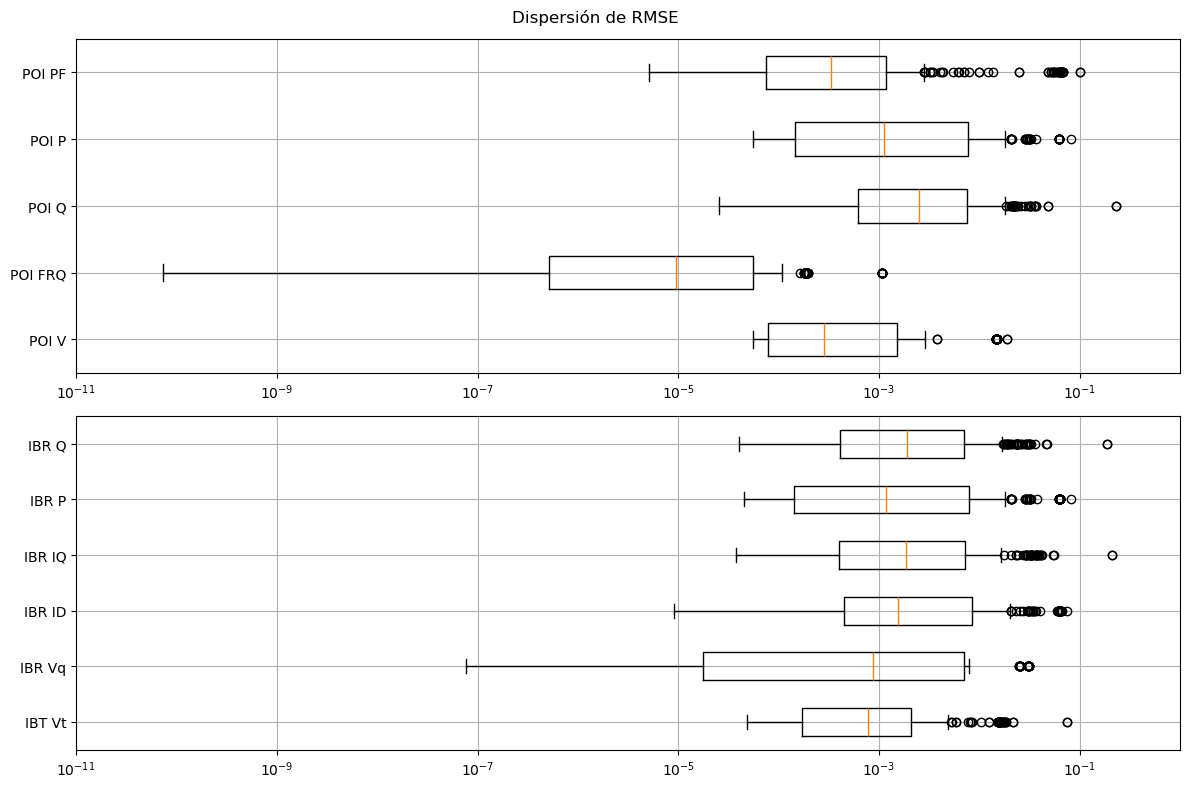

In [58]:
POI_columns = ['POI V', 'POI FRQ', 'POI Q', 'POI P', 'POI PF']
IBR_columns = ['IBT Vt', 'IBR Vq', 'IBR ID', 'IBR IQ', 'IBR P', 'IBR Q']

fig, axs = plt.subplots(2, 1, figsize=(12, 8))
axs[0].boxplot(df_rmse[POI_columns], vert=False)
axs[0].set_yticklabels(POI_columns)
axs[0].set_xscale('log')
axs[0].set_xlim(1e-11, 1)
axs[0].grid(True)

axs[1].boxplot(df_rmse[IBR_columns], vert=False)
axs[1].set_yticklabels(IBR_columns)
axs[1].set_xscale('log')
axs[1].set_xlim(1e-11, 1)
axs[1].grid(True)

fig.suptitle('Dispersión de RMSE')
fig.tight_layout()
plt.show()


In [163]:
'PC' + df_rmse['REPC_D mode'].str[-2:] + ' - EC' + df_rmse['REEC_D mode'].str[-2:]

0      PC01 - EC01
1      PC01 - EC01
2      PC01 - EC01
3      PC01 - EC01
4      PC01 - EC01
          ...     
253    PC06 - EC06
254    PC06 - EC06
255    PC06 - EC06
256    PC06 - EC06
257    PC06 - EC06
Length: 258, dtype: object

In [164]:
df_rmse['Mode'] = 'PC' + df_rmse['REPC_D mode'].str[-2:] + ' - EC' + df_rmse['REEC_D mode'].str[-2:]
df_rmse

,REPC_D mode,REEC_D mode,Prueba,POI V,POI FRQ,POI Q,POI P,POI PF,POI Angle,IBT Vt,IBR Vq,IBR ID,IBR IQ,IBR P,IBR Q,IBR PF,IBR Angle,Mode
0,REPC_D Modo 01,REEC_E Modo 01,0,0.000058,1.359536e-10,0.000025,0.000056,0.000005,0.000074,0.000049,7.615333e-08,0.000009,0.000038,0.000046,0.000040,0.000003,0.010630,PC01 - EC01
1,REPC_D Modo 01,REEC_E Modo 01,1,0.001756,1.927618e-05,0.001697,0.001261,0.000266,0.000080,0.001780,1.040347e-03,0.000987,0.001841,0.001267,0.001733,0.000237,0.010642,PC01 - EC01
2,REPC_D Modo 01,REEC_E Modo 01,2,0.014737,1.831708e-04,0.023018,0.020943,0.063597,0.016525,0.016472,3.077416e-02,0.020851,0.037100,0.020968,0.023815,NaN,0.023728,PC01 - EC01
3,REPC_D Modo 01,REEC_E Modo 01,3,0.001401,5.296186e-05,0.002733,0.003680,0.000575,0.000697,0.001472,6.994322e-03,0.003881,0.002450,0.003714,0.002451,0.000365,0.010424,PC01 - EC01
4,REPC_D Modo 01,REEC_E Modo 01,4,0.000152,1.061700e-03,0.002168,0.000876,0.000214,17.998574,0.000650,7.679071e-03,0.001085,0.001903,0.000883,0.002038,0.000504,17.990658,PC01 - EC01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253,REPC_D Modo 06,REEC_E Modo 06,7,0.000063,2.498400e-06,0.000313,0.000867,0.000034,0.000075,0.000076,7.734009e-05,0.000908,0.000111,0.000875,0.000112,0.000009,0.010632,PC06 - EC06
254,REPC_D Modo 06,REEC_E Modo 06,8,0.000166,3.699751e-07,0.001761,0.000108,0.000277,0.000073,0.000585,1.106921e-05,0.000450,0.001608,0.000104,0.001637,0.000146,0.010624,PC06 - EC06
255,REPC_D Modo 06,REEC_E Modo 06,11,0.000190,2.048407e-07,0.001370,0.000062,0.000310,0.000080,0.000256,1.011584e-05,0.000170,0.001358,0.000051,0.001343,0.000049,0.010637,PC06 - EC06
256,REPC_D Modo 06,REEC_E Modo 06,12,0.000056,1.564536e-06,0.000182,0.000181,0.000027,0.000074,0.000059,5.163990e-05,0.000189,0.000159,0.000180,0.000162,0.000015,0.010630,PC06 - EC06


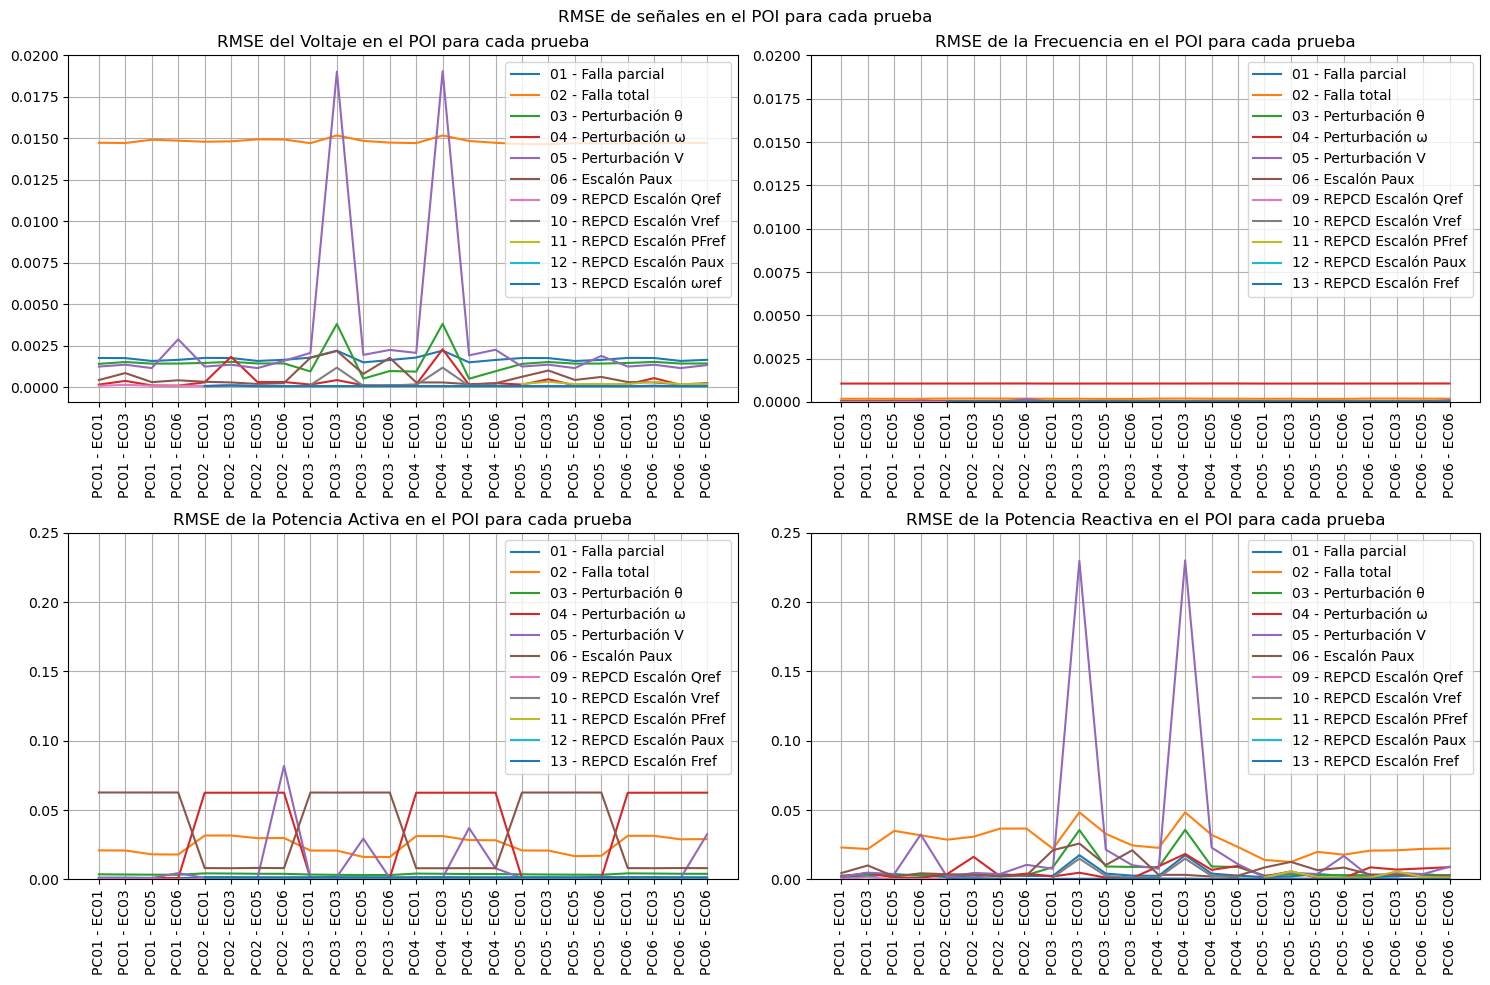

In [173]:
variable = 'POI V'
df_prueba_01 = df_rmse[df_rmse['Prueba'] == 1].sort_values('Mode')
df_prueba_02 = df_rmse[df_rmse['Prueba'] == 2].sort_values('Mode')
df_prueba_03 = df_rmse[df_rmse['Prueba'] == 3].sort_values('Mode')
df_prueba_04 = df_rmse[df_rmse['Prueba'] == 4].sort_values('Mode')
df_prueba_05 = df_rmse[df_rmse['Prueba'] == 5].sort_values('Mode')
df_prueba_06 = df_rmse[df_rmse['Prueba'] == 6].sort_values('Mode')
df_prueba_09 = df_rmse[df_rmse['Prueba'] == 9].sort_values('Mode')
df_prueba_10 = df_rmse[df_rmse['Prueba'] == 10].sort_values('Mode')
df_prueba_11 = df_rmse[df_rmse['Prueba'] == 11].sort_values('Mode')
df_prueba_12 = df_rmse[df_rmse['Prueba'] == 12].sort_values('Mode')
df_prueba_13 = df_rmse[df_rmse['Prueba'] == 13].sort_values('Mode')

fig, ax = plt.subplots(2,2, figsize=(15,10))
ax[0,0].plot(df_prueba_01['Mode'], df_prueba_01['POI V'], label='01 - Falla parcial')
ax[0,0].plot(df_prueba_02['Mode'], df_prueba_02['POI V'], label='02 - Falla total')
ax[0,0].plot(df_prueba_03['Mode'], df_prueba_03['POI V'], label='03 - Perturbación θ')
ax[0,0].plot(df_prueba_04['Mode'], df_prueba_04['POI V'], label='04 - Perturbación ω')
ax[0,0].plot(df_prueba_05['Mode'], df_prueba_05['POI V'], label='05 - Perturbación V')
ax[0,0].plot(df_prueba_06['Mode'], df_prueba_06['POI V'], label='06 - Escalón Paux')
ax[0,0].plot(df_prueba_09['Mode'], df_prueba_09['POI V'], label='09 - REPCD Escalón Qref')
ax[0,0].plot(df_prueba_10['Mode'], df_prueba_10['POI V'], label='10 - REPCD Escalón Vref')
ax[0,0].plot(df_prueba_11['Mode'], df_prueba_11['POI V'], label='11 - REPCD Escalón PFref')
ax[0,0].plot(df_prueba_12['Mode'], df_prueba_12['POI V'], label='12 - REPCD Escalón Paux')
ax[0,0].plot(df_prueba_13['Mode'], df_prueba_13['POI V'], label='13 - REPCD Escalón ωref')
ax[0,0].tick_params(axis='x', rotation=90)
ax[0,0].set_title('RMSE del Voltaje en el POI para cada prueba')
ax[0,0].legend()
ax[0,0].grid()

ax[0,1].plot(df_prueba_01['Mode'], df_prueba_01['POI FRQ'], label='01 - Falla parcial')
ax[0,1].plot(df_prueba_02['Mode'], df_prueba_02['POI FRQ'], label='02 - Falla total')
ax[0,1].plot(df_prueba_03['Mode'], df_prueba_03['POI FRQ'], label='03 - Perturbación θ')
ax[0,1].plot(df_prueba_04['Mode'], df_prueba_04['POI FRQ'], label='04 - Perturbación ω')
ax[0,1].plot(df_prueba_05['Mode'], df_prueba_05['POI FRQ'], label='05 - Perturbación V')
ax[0,1].plot(df_prueba_06['Mode'], df_prueba_06['POI FRQ'], label='06 - Escalón Paux')
ax[0,1].plot(df_prueba_09['Mode'], df_prueba_09['POI FRQ'], label='09 - REPCD Escalón Qref')
ax[0,1].plot(df_prueba_10['Mode'], df_prueba_10['POI FRQ'], label='10 - REPCD Escalón Vref')
ax[0,1].plot(df_prueba_11['Mode'], df_prueba_11['POI FRQ'], label='11 - REPCD Escalón PFref')
ax[0,1].plot(df_prueba_12['Mode'], df_prueba_12['POI FRQ'], label='12 - REPCD Escalón Paux')
ax[0,1].plot(df_prueba_13['Mode'], df_prueba_13['POI FRQ'], label='13 - REPCD Escalón Fref')
ax[0,1].set_ylim(0, 0.02)
ax[0,1].tick_params(axis='x', rotation=90)
ax[0,1].set_title('RMSE de la Frecuencia en el POI para cada prueba')
ax[0,1].legend()
ax[0,1].grid()

ax[1,0].plot(df_prueba_01['Mode'], df_prueba_01['POI P'], label='01 - Falla parcial')
ax[1,0].plot(df_prueba_02['Mode'], df_prueba_02['POI P'], label='02 - Falla total')
ax[1,0].plot(df_prueba_03['Mode'], df_prueba_03['POI P'], label='03 - Perturbación θ')
ax[1,0].plot(df_prueba_04['Mode'], df_prueba_04['POI P'], label='04 - Perturbación ω')
ax[1,0].plot(df_prueba_05['Mode'], df_prueba_05['POI P'], label='05 - Perturbación V')
ax[1,0].plot(df_prueba_06['Mode'], df_prueba_06['POI P'], label='06 - Escalón Paux')
ax[1,0].plot(df_prueba_09['Mode'], df_prueba_09['POI P'], label='09 - REPCD Escalón Qref')
ax[1,0].plot(df_prueba_10['Mode'], df_prueba_10['POI P'], label='10 - REPCD Escalón Vref')
ax[1,0].plot(df_prueba_11['Mode'], df_prueba_11['POI P'], label='11 - REPCD Escalón PFref')
ax[1,0].plot(df_prueba_12['Mode'], df_prueba_12['POI P'], label='12 - REPCD Escalón Paux')
ax[1,0].plot(df_prueba_13['Mode'], df_prueba_13['POI P'], label='13 - REPCD Escalón Fref')
ax[1,0].set_ylim(0, 0.25)
ax[1,0].tick_params(axis='x', rotation=90)
ax[1,0].set_title('RMSE de la Potencia Activa en el POI para cada prueba')
ax[1,0].legend()
ax[1,0].grid()

ax[1,1].plot(df_prueba_01['Mode'], df_prueba_01['POI Q'], label='01 - Falla parcial')
ax[1,1].plot(df_prueba_02['Mode'], df_prueba_02['POI Q'], label='02 - Falla total')
ax[1,1].plot(df_prueba_03['Mode'], df_prueba_03['POI Q'], label='03 - Perturbación θ')
ax[1,1].plot(df_prueba_04['Mode'], df_prueba_04['POI Q'], label='04 - Perturbación ω')
ax[1,1].plot(df_prueba_05['Mode'], df_prueba_05['POI Q'], label='05 - Perturbación V')
ax[1,1].plot(df_prueba_06['Mode'], df_prueba_06['POI Q'], label='06 - Escalón Paux')
ax[1,1].plot(df_prueba_09['Mode'], df_prueba_09['POI Q'], label='09 - REPCD Escalón Qref')
ax[1,1].plot(df_prueba_10['Mode'], df_prueba_10['POI Q'], label='10 - REPCD Escalón Vref')
ax[1,1].plot(df_prueba_11['Mode'], df_prueba_11['POI Q'], label='11 - REPCD Escalón PFref')
ax[1,1].plot(df_prueba_12['Mode'], df_prueba_12['POI Q'], label='12 - REPCD Escalón Paux')
ax[1,1].plot(df_prueba_13['Mode'], df_prueba_13['POI Q'], label='13 - REPCD Escalón Fref')
ax[1,1].set_ylim(0, 0.25)
ax[1,1].tick_params(axis='x', rotation=90)
ax[1,1].set_title('RMSE de la Potencia Reactiva en el POI para cada prueba')
ax[1,1].legend()
ax[1,1].grid()

fig.suptitle('RMSE de señales en el POI para cada prueba')
fig.tight_layout()
plt.show()